# Các thành viên trong nhóm:
+ Viên Huy Lương - CH11023004
+ Nguyễn Phước Lợi - CH11023003

## 0. Môi trường Google Colab



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Cài thư viện cần cho toàn notebook
%pip install -q \
    pandas numpy scipy scikit-learn scikit-image \
    matplotlib seaborn pillow tqdm \
    torchsummary


In [4]:
from pathlib import Path

import torch

try:
    from google.colab import drive
except ImportError:
    drive = None

# === Chỉnh đúng folder bạn đã upload trên Drive ===
DRIVE_PROJECT = Path("/content/drive/MyDrive/TL_OvarianTumor_Ultrasound")

if drive is not None:
    drive.mount("/content/drive", force_remount=False)
else:
    print("Không phải runtime Colab — coi DRIVE_PROJECT là thư mục hiện tại.")
    DRIVE_PROJECT = Path(".").resolve()

DATA_ROOT = DRIVE_PROJECT / "dataset" / "MMOTU"
OUTPUT_DIR = DRIVE_PROJECT / "outputs"
CACHE_DIR = DRIVE_PROJECT / "cache"
RUNS_DIR = DRIVE_PROJECT / "runs"

for _d in (OUTPUT_DIR, CACHE_DIR, RUNS_DIR):
    _d.mkdir(parents=True, exist_ok=True)

_otu = DATA_ROOT / "OTU_2d" / "images"
if not _otu.exists():
    raise FileNotFoundError(
        f"Không thấy {_otu}.\n"
        f"Hãy upload MMOTU lên Drive: {DRIVE_PROJECT}/dataset/MMOTU/OTU_2d/ ..."
    )

print("PyTorch:", torch.__version__)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: chưa bật — Runtime → Change runtime type → T4")

print("DRIVE_PROJECT:", DRIVE_PROJECT)
print("DATA_ROOT:", DATA_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("OTU_2d:", sorted(p.name for p in (DATA_ROOT / "OTU_2d").iterdir()))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch: 2.11.0+cu128
GPU: Tesla T4
DRIVE_PROJECT: /content/drive/MyDrive/TL_OvarianTumor_Ultrasound
DATA_ROOT: /content/drive/MyDrive/TL_OvarianTumor_Ultrasound/dataset/MMOTU
OUTPUT_DIR: /content/drive/MyDrive/TL_OvarianTumor_Ultrasound/outputs
OTU_2d: ['annotations', 'images', 'train.txt', 'train_cls.txt', 'val.txt', 'val_cls.txt']


# 1. Giới thiệu

## Bài toán

U buồng trứng là bệnh lý phụ khoa thường gặp. Siêu âm là phương tiện sàng lọc đầu tay, nhưng việc phân loại loại u (nang sô-cô-la, teratoma, cystadenoma, u ác tính, …) phụ thuộc nhiều vào kinh nghiệm người đọc và dễ nhầm giữa các lớp có hình thái gần nhau.

Bài toán đặt ra trên tập **MMOTU** (Multi-Modality Ovarian Tumor Ultrasound): hỗ trợ nhận diện loại u trên ảnh siêu âm 2D, cụ thể là phân loại 8 loại bệnh lý u buồng trứng.

## Phạm vi

Đồ án **chỉ phân tích và huấn luyện trên tập OTU_2d** (siêu âm 2D, 1469 ảnh, 8 lớp). Tập OTU_3d (CEUS) **không** đưa vào EDA, tiền xử lý, huấn luyện và đánh giá

## Mục tiêu

- Hiểu cấu trúc, chất lượng và mất cân bằng của dữ liệu **OTU_2d** trước khi huấn luyện.
- Xây dựng pipeline học máy/học sâu cho phân loại 8 loại bệnh lý u buồng trứng trên ảnh siêu âm 2D.
- Đánh giá bằng các độ đo phù hợp (accuracy, precision/recall/F1, confusion matrix; đồ thị hàm loss).
- Chỉ ra lớp nào dễ nhầm, hạn chế của mô hình và hướng cải thiện.

## Bộ dữ liệu đã chọn

**MMOTU** — Zhao et al., gồm hai subset:

| Subset | Mô tả | Số ảnh | Số lớp |
| --- | --- | --- | --- |
| OTU_2d | Siêu âm 2D | 1469 | 8 |
| OTU_3d | Contrast-enhanced ultrasound | 170 | 7 (không có Normal ovary) |

Tuy nhiên trong đồ án này thì nhóm em chỉ chọn subset OTU_2d để huấn luyện mô hình

Tám lớp trên OTU_2d:

| ID | Tên lớp | Tên bệnh lý |
| --- | --- | --- |
| 0 | Chocolate cyst | U nang lạc nội mạc tử cung |
| 1 | Serous cystadenoma | U nang tuyến thanh dịch |
| 2 | Teratoma | U quái (U bì) trưởng thành |
| 3 | Theca cell tumor | U tế bào vỏ buồng trứng |
| 4 | Simple cyst | Nang đơn giản (Nang cơ năng) |
| 5 | Normal ovary | Buồng trứng bình thường |
| 6 | Mucinous cystadenoma | U nang tuyến nhầy |
| 7 | High grade serous | Ung thư biểu mô thanh dịch độ cao |

Mỗi mẫu có ảnh `*.JPG`, nhãn lớp trong `train_cls.txt` / `val_cls.txt`, và mask pixel-wise (`*.PNG`, `*_binary.PNG`). Split train/val có sẵn.


# 2. Phân tích dữ liệu (EDA) tập OTU_2d (MMOTU)

+ Việc phân tích dữ liệu để phát hiện và xử lý dữ liệu bị thiếu, phát hiện dữ liệu outlier, định dạng dữ liệu, rút trích và lựa chọn đặc trưng tốt để huấn luyện mô hình, ngoài ra việc phân tích dữ liệu giúp hiểu được phân phối dữ liệu, phát hiện việc mất cân bằng các lớp, chuẩn hóa dữ liệu. Toàn bộ EDA dưới đây chỉ thực hiện trên **OTU_2d**.

**2. Phân tích dữ liệu**
- 2.1 Kiểm tra folder và định dạng dữ liệu
- 2.2 Đọc nhãn và thống kê class
- 2.3 Kiểm tra kích thước ảnh và xem mẫu
- 2.4 Metadata: tên lớp và đường dẫn mask
- 2.5 Phân tích chất lượng ảnh
- 2.6 Phân tích annotation
- 2.7 Phân tích intensity distribution
- 2.8 Phân tích texture features
- 2.9 Phân tích tương quan giữa các lớp
- 2.10 Phân tích outlier
- 2.11 Phân tích missing data
- 2.12 Lưu CSV


## 2.1 Kiểm tra folder và định dạng dữ liệu


In [5]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

if "DATA_ROOT" not in globals():
    raise RuntimeError("Chạy mục 0 (mount Drive) trước khi vào mục 2.")
SUBSET_NAME = "OTU_2d"
subset = DATA_ROOT / SUBSET_NAME
print("DATA_ROOT:", DATA_ROOT)
print("Subset dùng để phân tích và huấn luyện:", SUBSET_NAME)

print(f"\n=== {subset.name} ===")
for fname in ["train.txt", "val.txt", "train_cls.txt", "val_cls.txt", "trainval.txt"]:
    f = subset / fname
    if f.exists():
        with open(f, "r", encoding="utf-8") as fh:
            lines = [line.strip() for line in fh if line.strip()]
        print(f"{fname}: {len(lines)} dòng")
        print("Ví dụ:", lines[:3])
img_dir = subset / "images"
if img_dir.exists():
    imgs = sorted(img_dir.iterdir())
    print(f"images folder: {len(imgs)} file")
    print("Mẫu ảnh:", [img.name for img in imgs[:5]])


DATA_ROOT: /content/drive/MyDrive/TL_OvarianTumor_Ultrasound/dataset/MMOTU
Subset dùng để phân tích và huấn luyện: OTU_2d

=== OTU_2d ===
train.txt: 1000 dòng
Ví dụ: ['658', '384', '367']
val.txt: 469 dòng
Ví dụ: ['1269', '1458', '700']
train_cls.txt: 1000 dòng
Ví dụ: ['658.JPG  5', '384.JPG  3', '367.JPG  3']
val_cls.txt: 469 dòng
Ví dụ: ['1269.JPG  5', '1458.JPG  7', '700.JPG  6']
images folder: 1469 file
Mẫu ảnh: ['1.JPG', '10.JPG', '100.JPG', '1000.JPG', '1001.JPG']


## 2.2 Đọc file nhãn và xây dựng DataFrame

Cấu trúc nhãn có dạng:
`<tên_ảnh.jpg> <class_id>`

Ví dụ:
`658.JPG  5`


In [6]:
def read_label_file(label_path: Path):
    rows = []
    if not label_path.exists():
        return pd.DataFrame(rows)

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) >= 2:
                img_name = parts[0]
                label = int(parts[1])
                rows.append({
                    "image_name": img_name,
                    "label": label
                })
    return pd.DataFrame(rows)

sample_df = read_label_file(DATA_ROOT / SUBSET_NAME / "train_cls.txt")
print(f"{SUBSET_NAME} - train_cls.txt:", len(sample_df), "dòng")
print(sample_df.head())


OTU_2d - train_cls.txt: 1000 dòng
  image_name  label
0    658.JPG      5
1    384.JPG      3
2    367.JPG      3
3    730.JPG      1
4   1426.JPG      7


In [7]:
all_rows = []
subset = DATA_ROOT / SUBSET_NAME
img_dir = subset / "images"

for split in ["train", "val"]:
    label_file = subset / f"{split}_cls.txt"
    if not label_file.exists():
        continue

    df_split = read_label_file(label_file).copy()
    df_split["subset"] = SUBSET_NAME
    df_split["split"] = split
    df_split["image_path"] = df_split["image_name"].apply(lambda x: str(img_dir / x))
    all_rows.append(df_split)

df = pd.concat(all_rows, ignore_index=True)
print("Tổng số sample (OTU_2d):", len(df))
print(df.head())


Tổng số sample (OTU_2d): 1469
  image_name  label  subset  split  \
0    658.JPG      5  OTU_2d  train   
1    384.JPG      3  OTU_2d  train   
2    367.JPG      3  OTU_2d  train   
3    730.JPG      1  OTU_2d  train   
4   1426.JPG      7  OTU_2d  train   

                                          image_path  
0  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...  
1  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...  
2  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...  
3  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...  
4  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...  


    split  label  count
0   train      0    226
1   train      1    153
2   train      2    228
3   train      3     57
4   train      4     47
5   train      5    180
6   train      6     71
7   train      7     38
8     val      0    110
9     val      1     66
10    val      2    108
11    val      3     31
12    val      4     19
13    val      5     87
14    val      6     33
15    val      7     15

Tổng số sample theo split:
split
train    1000
val       469
dtype: int64


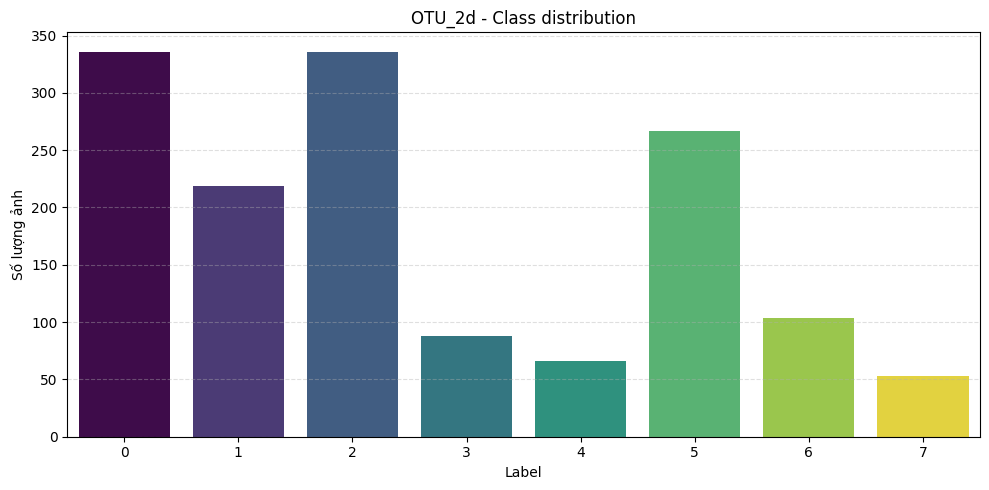

In [8]:
df["label_name"] = df["label"].map(lambda x: f"Class {x}")

summary = (
    df.groupby(["split", "label"])
      .size()
      .reset_index(name="count")
      .sort_values(["split", "label"])
)

print(summary)
print("\nTổng số sample theo split:")
print(df.groupby("split").size())

plt.figure(figsize=(10, 5))
counts = df.groupby("label").size().sort_index()
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="viridis", legend=False)
plt.title("OTU_2d - Class distribution")
plt.xlabel("Label")
plt.ylabel("Số lượng ảnh")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


### Nhận xét:
+ Phân bổ nhãn trên tập OTU_2d không đều: các lớp 3, 4, 6, 7 ít hơn rõ so với các lớp 0, 1, 2, 5 → cần class weight / augment khi huấn luyện.


In [9]:
print("=== OTU_2d ===")
print(df["label"].value_counts().sort_index())
print("Total:", len(df))


=== OTU_2d ===
label
0    336
1    219
2    336
3     88
4     66
5    267
6    104
7     53
Name: count, dtype: int64
Total: 1469


## 2.3 Kiểm tra kích thước ảnh và xem mẫu

Bước này giúp biết ảnh có đồng nhất kích thước hay không, và quan sát trực quan dữ liệu trước khi train.


In [10]:
def get_image_size(path: str):
    try:
        with Image.open(path) as img:
            return img.size[0], img.size[1]
    except Exception:
        return None, None

size_rows = []
for _, row in df.iterrows():
    w, h = get_image_size(row["image_path"])
    if w is not None and h is not None:
        size_rows.append({
            "subset": row["subset"],
            "split": row["split"],
            "label": row["label"],
            "image_name": row["image_name"],
            "width": w,
            "height": h
        })

size_df = pd.DataFrame(size_rows)
print(size_df.head())
print("\nThông tin kích thước ảnh:")
print(size_df.groupby("split").agg({
    "width": ["min", "max", "mean"],
    "height": ["min", "max", "mean"]
}))


   subset  split  label image_name  width  height
0  OTU_2d  train      5    658.JPG    480     559
1  OTU_2d  train      3    384.JPG    554     589
2  OTU_2d  train      3    367.JPG    958     534
3  OTU_2d  train      1    730.JPG    973     547
4  OTU_2d  train      7   1426.JPG    958     535

Thông tin kích thước ảnh:
      width                   height                 
        min   max        mean    min  max        mean
split                                                
train   302  1135  760.574000    270  794  551.899000
val     407  1135  765.179104    266  794  548.586354


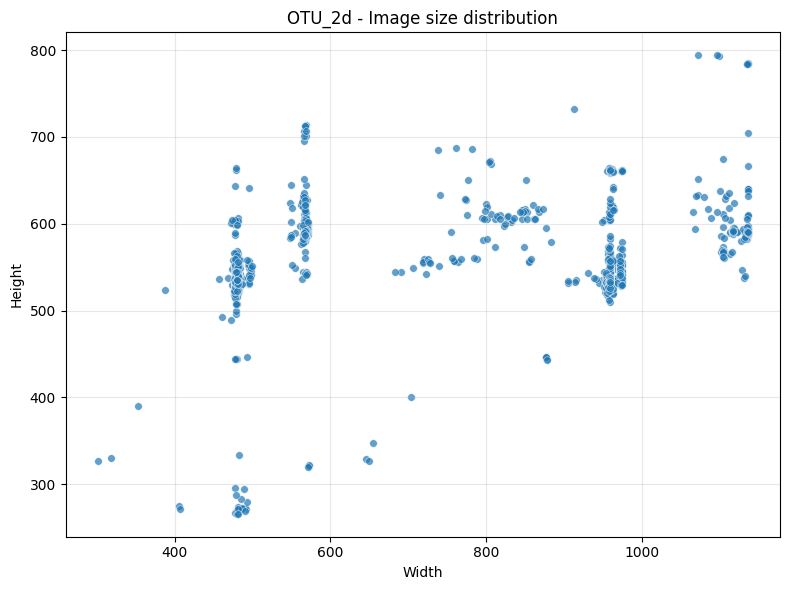

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=size_df, x="width", y="height", s=30, alpha=0.7)
plt.title("OTU_2d - Image size distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Nhận xét:
+ Kích thước ảnh OTU_2d không đồng nhất: tập trung chủ yếu ở hai cụm khoảng 400–600 × 500–700 và 900–1000 × 500–700 → cần resize/pad về cùng kích thước trước khi train.


Index(['image_name', 'label', 'subset', 'split', 'image_path', 'label_name'], dtype='object')
  image_name  label  subset  split  \
0    454.JPG      0  OTU_2d  train   
1   1178.JPG      5  OTU_2d  train   
2    272.JPG      2  OTU_2d  train   
3    131.JPG      1  OTU_2d  train   
4      6.JPG      0  OTU_2d  train   

                                          image_path label_name  
0  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...    Class 0  
1  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...    Class 5  
2  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...    Class 2  
3  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...    Class 1  
4  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...    Class 0  


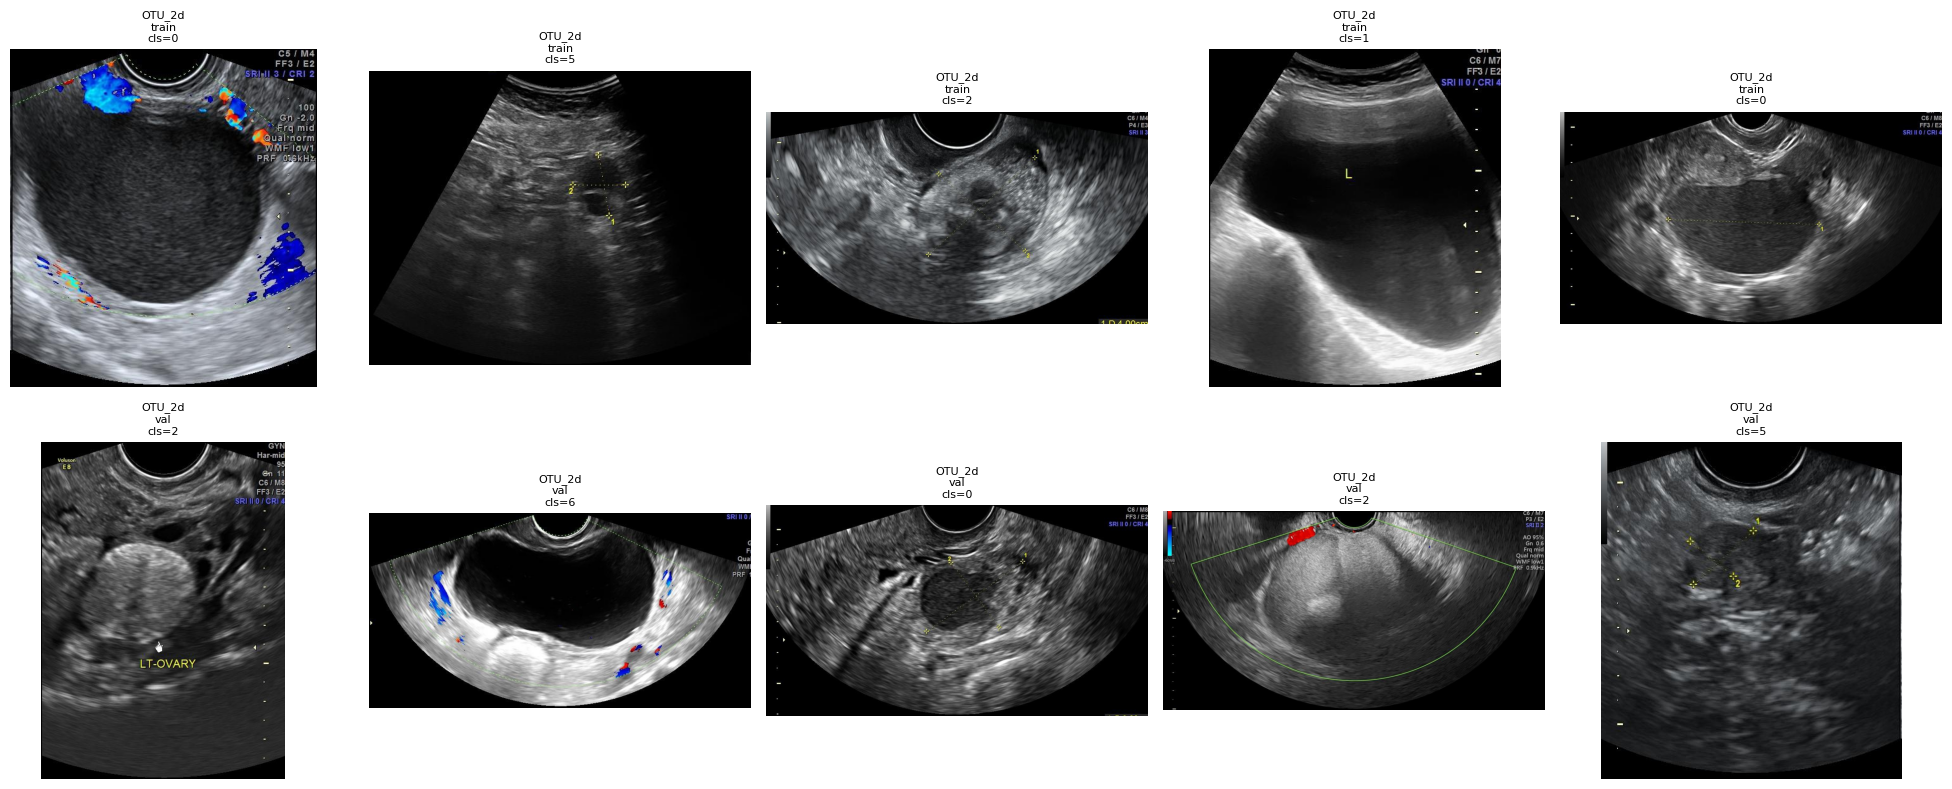

In [12]:
sample_frames = []
for subset_name, subset_df in df.groupby("subset"):
    for split_name, split_df in subset_df.groupby("split"):
        sample = split_df.sample(n=min(5, len(split_df)), random_state=42)
        sample_frames.append(sample)

sample_images_df = pd.concat(sample_frames, ignore_index=True)
print(sample_images_df.columns)
print(sample_images_df.head())

grouped = list(sample_images_df.groupby(["subset", "split"]))
row_count = len(grouped)
fig, axes = plt.subplots(row_count, 5, figsize=(20, 4 * max(1, row_count)))
if row_count == 1:
    axes = axes.reshape(1, -1)

for row_idx, ((subset_name, split_name), subset_group) in enumerate(grouped):
    subset_group = subset_group.reset_index(drop=True)
    for col_idx, (_, row) in enumerate(subset_group.iterrows()):
        ax = axes[row_idx, col_idx]
        try:
            img = Image.open(row["image_path"])
            if img.mode in ["L", "1"]:
                ax.imshow(img, cmap="gray")
            else:
                ax.imshow(img)
        except Exception:
            ax.imshow(
                __import__("numpy").zeros((64, 64), dtype=__import__("numpy").uint8),
                cmap="gray",
            )
        ax.set_title(f"{subset_name}\n{split_name}\ncls={row['label']}", fontsize=8)
        ax.axis("off")

# Xóa các ô còn trống nếu có
if row_count > 0:
    for ax in axes.flat[row_count * 5:]:
        ax.axis("off")

plt.tight_layout()
plt.show()

## 2.4 Metadata: tên lớp và đường dẫn mask

MMOTU gồm 8 lớp u buồng trứng. Ảnh `*.JPG` tương ứng mask `*.PNG` (màu) và `*_binary.PNG` (nhị phân 0/1).
Phần phân tích hình học dùng mask nhị phân.


In [13]:
CLASS_NAMES = {
    0: "Chocolate cyst",
    1: "Serous cystadenoma",
    2: "Teratoma",
    3: "Theca cell tumor",
    4: "Simple cyst",
    5: "Normal ovary",
    6: "Mucinous cystadenoma",
    7: "High grade serous",
}

def resolve_mask_path(image_path: str):
    img_path = Path(image_path)
    ann_dir = img_path.parent.parent / "annotations"
    stem = img_path.stem
    binary_mask = ann_dir / f"{stem}_binary.PNG"
    color_mask = ann_dir / f"{stem}.PNG"
    if binary_mask.exists():
        return str(binary_mask), str(color_mask) if color_mask.exists() else None, True
    if color_mask.exists():
        return str(color_mask), str(color_mask), True
    return None, str(color_mask) if color_mask.exists() else None, False

mask_info = df["image_path"].apply(resolve_mask_path)
df["mask_path"] = [x[0] for x in mask_info]
df["color_mask_path"] = [x[1] for x in mask_info]
df["has_mask"] = [x[2] for x in mask_info]
df["class_name"] = df["label"].map(CLASS_NAMES)
df["label_name"] = df["label"].map(lambda x: f"{x}: {CLASS_NAMES.get(x, 'Unknown')}")

print("Số ảnh có mask:", int(df["has_mask"].sum()), "/", len(df))
print("Số ảnh thiếu mask:", int((~df["has_mask"]).sum()))
print("\nMapping lớp:")
for k, v in CLASS_NAMES.items():
    n = int((df["label"] == k).sum())
    print(f"  {k}: {v:24s}  n={n}")


Số ảnh có mask: 1469 / 1469
Số ảnh thiếu mask: 0

Mapping lớp:
  0: Chocolate cyst            n=336
  1: Serous cystadenoma        n=219
  2: Teratoma                  n=336
  3: Theca cell tumor          n=88
  4: Simple cyst               n=66
  5: Normal ovary              n=267
  6: Mucinous cystadenoma      n=104
  7: High grade serous         n=53


### Nhận xét:
+ Ảnh không thiếu mask

## 2.5 Phân tích chất lượng ảnh

- **Độ tương phản (Contrast)**: Đo chênh lệch sáng/tối (RMS, Michelson). Việc so sánh trước/sau *histogram equalization* giúp kiểm tra xem thuật toán có thực sự làm nổi bật đặc trưng quan trọng (viền cạnh, khối u...) để mô hình AI dễ học hơn hay không.

- **Độ sáng (Brightness)**: `mean` (độ sáng trung bình) và `std` (độ lệch chuẩn phân bố ánh sáng). Dùng để phát hiện ảnh quá tối/sáng bị mất thông tin, từ đó chuẩn hóa (normalize) giúp mô hình nhận diện ổn định trong mọi điều kiện chiếu sáng.

- **Mức nhiễu (Noise level)**: `SNR = mean / std` (và dB). SNR thấp nghĩa là nhiễu nhiều, dễ che lấp chi tiết nhỏ. Chỉ số này dùng để đánh giá chất lượng ảnh và quyết định có cần áp dụng bộ lọc khử nhiễu (denoising) trước khi huấn luyện hay không.

- **Độ sắc nét (Sharpness)**: Trung bình gradient magnitude (`np.gradient`). Gradient thấp đồng nghĩa với ảnh bị mờ (blur). Chỉ số này dùng để tự động lọc bỏ các ảnh không đạt chuẩn ra khỏi tập dữ liệu.



In [14]:
import numpy as np
from tqdm.auto import tqdm
from scipy.stats import skew, kurtosis
from skimage.exposure import equalize_hist
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.filters import gabor
from skimage.measure import label, regionprops
from skimage.transform import resize
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

EPS = 1e-8
MIN_LESION_AREA = 30
TEXTURE_SIZE = 128
GLCM_LEVELS = 32


def load_gray(path: str) -> np.ndarray:
    with Image.open(path) as im:
        return np.array(im.convert("L"), dtype=np.float32)


def load_mask(path: str | None, shape=None) -> np.ndarray | None:
    if path is None or not Path(str(path)).exists():
        return None
    with Image.open(path) as im:
        mask = np.array(im)
    if mask.ndim == 3:
        mask = mask.max(axis=2)
    return (mask > 0).astype(np.uint8)


def michelson_contrast(img: np.ndarray) -> float:
    imax, imin = float(img.max()), float(img.min())
    denom = imax + imin
    return float((imax - imin) / denom) if denom > 0 else 0.0


def histogram_entropy(img: np.ndarray) -> float:
    hist, _ = np.histogram(img, bins=256, range=(0, 255), density=True)
    hist = hist[hist > 0]
    return float(-(hist * np.log2(hist)).sum())


def gradient_sharpness(img: np.ndarray) -> float:
    gy, gx = np.gradient(img)
    return float(np.mean(np.hypot(gx, gy)))


def extract_quality(img: np.ndarray) -> dict:
    mean_v = float(img.mean())
    std_v = float(img.std())
    he = equalize_hist(img) * 255.0
    return {
        "brightness_mean": mean_v,
        "brightness_std": std_v,
        "rms_contrast": std_v / (mean_v + EPS),
        "michelson_contrast": michelson_contrast(img),
        "hist_entropy": histogram_entropy(img),
        "snr": mean_v / (std_v + EPS),
        "snr_db": float(10.0 * np.log10((mean_v ** 2) / (std_v ** 2 + EPS))),
        "sharpness": gradient_sharpness(img),
        "he_rms_contrast": float(he.std() / (he.mean() + EPS)),
        "he_michelson_contrast": michelson_contrast(he),
        "he_hist_entropy": histogram_entropy(he),
        "contrast_gain": float(he.std() / (std_v + EPS)),
        "dynamic_range": float(img.max() - img.min()),
        "intensity_min": float(img.min()),
        "intensity_max": float(img.max()),
        "skewness": float(skew(img.ravel(), bias=False)) if img.size > 2 else np.nan,
        "kurtosis": float(kurtosis(img.ravel(), bias=False, fisher=True)) if img.size > 3 else np.nan,
    }


def extract_annotation(mask: np.ndarray | None, img_shape) -> dict:
    out = {
        "mask_h": np.nan, "mask_w": np.nan, "size_mismatch": False,
        "tumor_area_px": 0.0, "tumor_area_ratio": 0.0,
        "bbox_h": np.nan, "bbox_w": np.nan, "aspect_ratio": np.nan,
        "circularity": np.nan, "solidity": np.nan, "eccentricity": np.nan,
        "n_lesions": 0, "empty_mask": True,
    }
    if mask is None:
        return out
    out["mask_h"], out["mask_w"] = mask.shape[:2]
    out["size_mismatch"] = tuple(mask.shape[:2]) != tuple(img_shape[:2])
    binary = (mask > 0).astype(np.uint8)
    img_area = float(np.prod(img_shape[:2]))
    labeled = label(binary, connectivity=2)
    props = [p for p in regionprops(labeled) if p.area >= MIN_LESION_AREA]
    out["n_lesions"] = int(len(props))
    out["tumor_area_px"] = float(binary.sum())
    out["tumor_area_ratio"] = out["tumor_area_px"] / (img_area + EPS)
    out["empty_mask"] = out["tumor_area_px"] <= 0
    if not props:
        return out
    main = max(props, key=lambda p: p.area)
    minr, minc, maxr, maxc = main.bbox
    bh, bw = maxr - minr, maxc - minc
    out["bbox_h"] = float(bh)
    out["bbox_w"] = float(bw)
    out["aspect_ratio"] = float(bh / (bw + EPS))
    perim = float(main.perimeter) if main.perimeter else np.nan
    out["circularity"] = float(4.0 * np.pi * main.area / (perim ** 2 + EPS)) if perim == perim else np.nan
    out["solidity"] = float(main.solidity) if main.solidity is not None else np.nan
    out["eccentricity"] = float(main.eccentricity)
    return out


def roi_from_mask(img: np.ndarray, mask: np.ndarray | None) -> np.ndarray:
    if mask is None or mask.shape != img.shape or mask.sum() == 0:
        return img
    ys, xs = np.where(mask > 0)
    pad = 4
    y0, y1 = max(0, ys.min() - pad), min(img.shape[0], ys.max() + pad + 1)
    x0, x1 = max(0, xs.min() - pad), min(img.shape[1], xs.max() + pad + 1)
    return img[y0:y1, x0:x1]


def extract_texture(roi: np.ndarray) -> dict:
    roi_r = resize(roi, (TEXTURE_SIZE, TEXTURE_SIZE), anti_aliasing=True, preserve_range=True)
    roi_u8 = np.clip(roi_r, 0, 255).astype(np.uint8)
    quantized = (roi_u8.astype(np.float32) * (GLCM_LEVELS - 1) / 255.0).astype(np.uint8)
    glcm = graycomatrix(
        quantized,
        distances=[1],
        angles=[0.0, np.pi / 4, np.pi / 2, 3 * np.pi / 4],
        levels=GLCM_LEVELS,
        symmetric=True,
        normed=True,
    )
    feats = {}
    for prop in ["contrast", "correlation", "energy", "homogeneity"]:
        feats[f"glcm_{prop}"] = float(graycoprops(glcm, prop).mean())

    lbp = local_binary_pattern(roi_u8, P=8, R=1, method="uniform")
    n_bins = 11
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_bins + 1), density=True)
    lbp_hist = lbp_hist.astype(np.float64)
    lbp_hist = lbp_hist / (lbp_hist.sum() + EPS)
    feats["lbp_entropy"] = float(-(lbp_hist[lbp_hist > 0] * np.log2(lbp_hist[lbp_hist > 0])).sum())
    feats["lbp_energy"] = float((lbp_hist ** 2).sum())
    for i, v in enumerate(lbp_hist):
        feats[f"lbp_bin_{i}"] = float(v)

    gabor_energy = []
    for theta in [0.0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]:
        for freq in [0.10, 0.25]:
            real, imag = gabor(roi_u8, frequency=freq, theta=theta)
            gabor_energy.append(float(np.mean(real ** 2 + imag ** 2)))
    feats["gabor_energy_mean"] = float(np.mean(gabor_energy))
    feats["gabor_energy_std"] = float(np.std(gabor_energy))
    for i, v in enumerate(gabor_energy):
        feats[f"gabor_e_{i}"] = float(v)
    return feats


def intensity_on_region(img: np.ndarray, mask: np.ndarray | None) -> dict:
    pixels = img[mask > 0] if (mask is not None and mask.shape == img.shape and mask.sum() > 0) else img.ravel()
    if pixels.size == 0:
        pixels = img.ravel()
    return {
        "roi_mean": float(pixels.mean()),
        "roi_std": float(pixels.std()),
        "roi_skewness": float(skew(pixels, bias=False)) if pixels.size > 2 else np.nan,
        "roi_kurtosis": float(kurtosis(pixels, bias=False, fisher=True)) if pixels.size > 3 else np.nan,
        "roi_min": float(pixels.min()),
        "roi_max": float(pixels.max()),
        "roi_dynamic_range": float(pixels.max() - pixels.min()),
    }


records = []
class_hists = {int(c): np.zeros(256, dtype=np.float64) for c in sorted(df["label"].unique())}

for _, row in tqdm(df.iterrows(), total=len(df), desc="Tính chỉ số từ ảnh/mask"):
    rec = {
        "image_name": row["image_name"],
        "label": int(row["label"]),
        "class_name": row["class_name"],
        "subset": row["subset"],
        "split": row["split"],
        "image_path": row["image_path"],
        "mask_path": row["mask_path"],
        "has_mask": bool(row["has_mask"]),
    }
    try:
        img = load_gray(row["image_path"])
        rec["img_h"], rec["img_w"] = img.shape
        rec["n_pixels"] = int(img.size)
        mask = load_mask(row["mask_path"], shape=img.shape) if row["has_mask"] else None
        rec["mask_resized"] = bool(mask is not None and mask.shape != img.shape)
        rec.update(extract_quality(img))
        rec.update(extract_annotation(mask, img.shape))
        rec.update(intensity_on_region(img, mask if (mask is not None and mask.shape == img.shape) else None))
        roi = roi_from_mask(img, mask if (mask is not None and mask.shape == img.shape) else None)
        rec.update(extract_texture(roi))
        pixels = img[mask > 0] if (mask is not None and mask.shape == img.shape and mask.sum() > 0) else img.ravel()
        hist, _ = np.histogram(pixels, bins=256, range=(0, 255))
        class_hists[int(row["label"])] += hist
    except Exception as exc:
        rec["error"] = str(exc)
    records.append(rec)

feat_df = pd.DataFrame(records)
print("Số mẫu:", len(feat_df))
print("Số mẫu lỗi:", int(feat_df["error"].notna().sum()) if "error" in feat_df.columns else 0)
print(feat_df[["image_name", "class_name", "brightness_mean", "rms_contrast", "snr_db", "sharpness", "tumor_area_ratio"]].head())


Tính chỉ số từ ảnh/mask:   0%|          | 0/1469 [00:00<?, ?it/s]

Số mẫu: 1469
Số mẫu lỗi: 0
  image_name          class_name  brightness_mean  rms_contrast    snr_db  \
0    658.JPG        Normal ovary        80.088867      0.805158  1.882378   
1    384.JPG    Theca cell tumor       103.916885      0.866073  1.248910   
2    367.JPG    Theca cell tumor        36.168800      1.051725 -0.438046   
3    730.JPG  Serous cystadenoma        44.618946      1.314081 -2.372441   
4   1426.JPG   High grade serous        42.531605      1.040942 -0.348529   

   sharpness  tumor_area_ratio  
0   9.167854          0.063652  
1   5.896430          0.294644  
2   6.225797          0.009764  
3   4.413413          0.216387  
4   5.555080          0.133054  


Nhận xét về kết quả output:
+ Số mẫu lỗi là 0
+ Độ sáng dao động lớn từ rất tối (36.1) đến khá sáng (103.9)
+ Tỷ lệ nhiễu SNR(db) xuất hiện giá trị âm, cho thấy độ lệch chuẩn lớn hơn giá trị trung bình. Như vậy các ảnh rất tối, có nhiễu nền
+ Độ sắc nét: dao động từ 4.41 đến 9.16, ảnh số 3 có độ sắc nét khá thấp 4.41 cho thấy ảnh có thể bị mờ hoặc mất nét

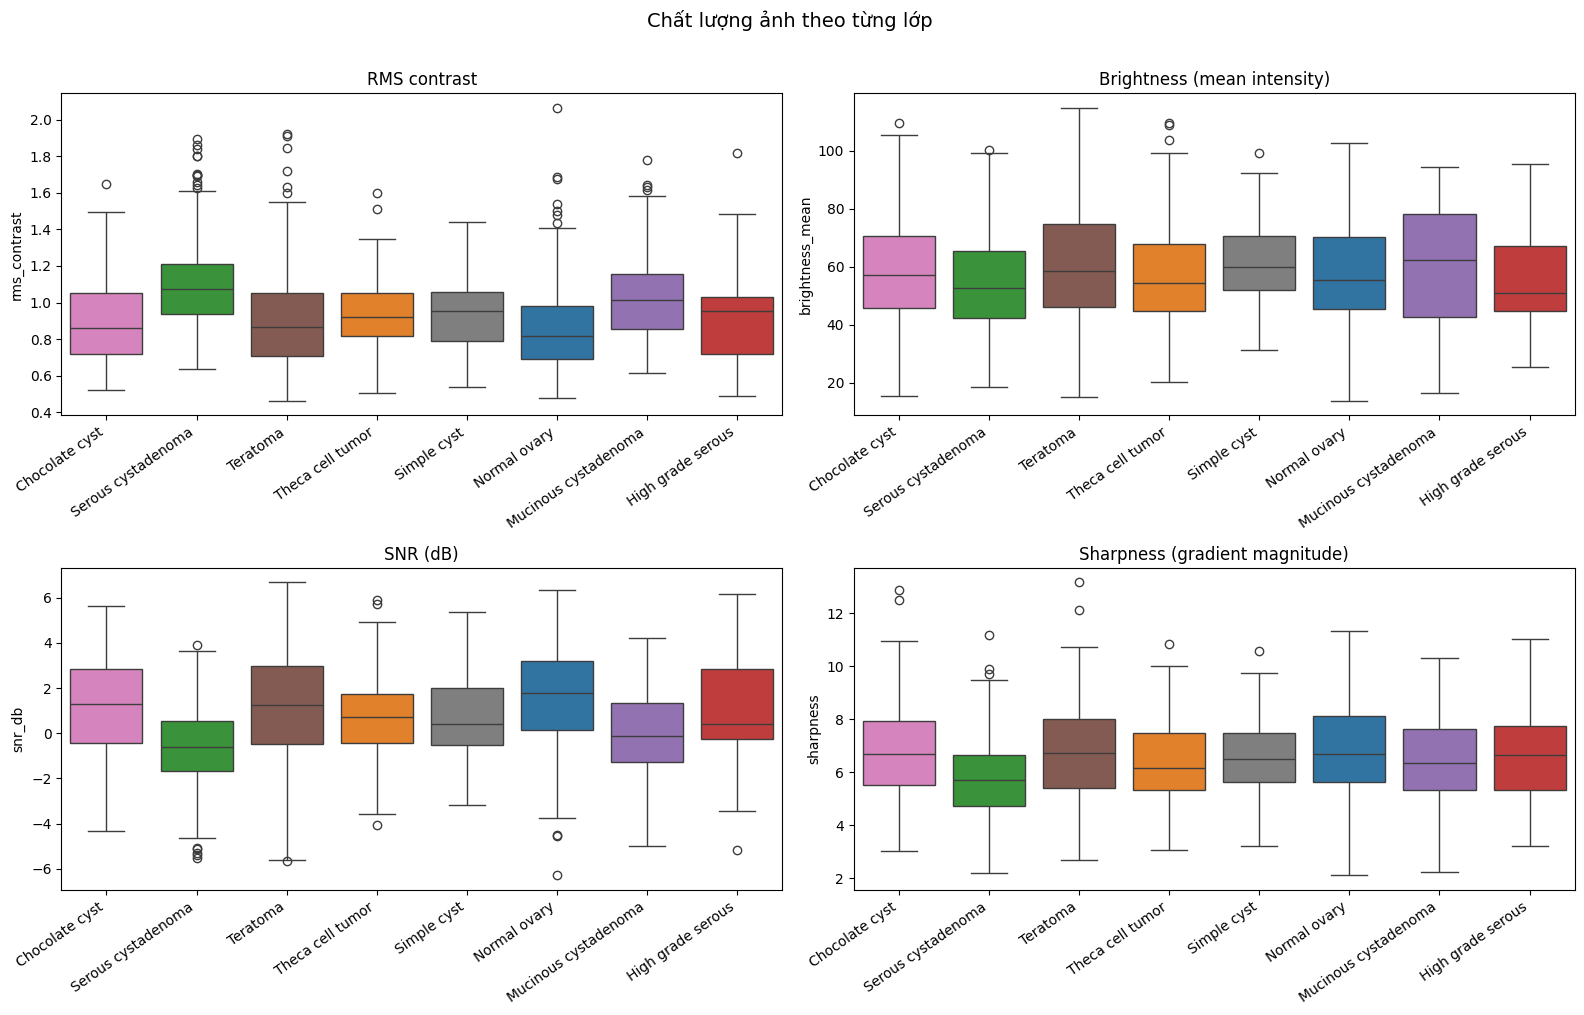

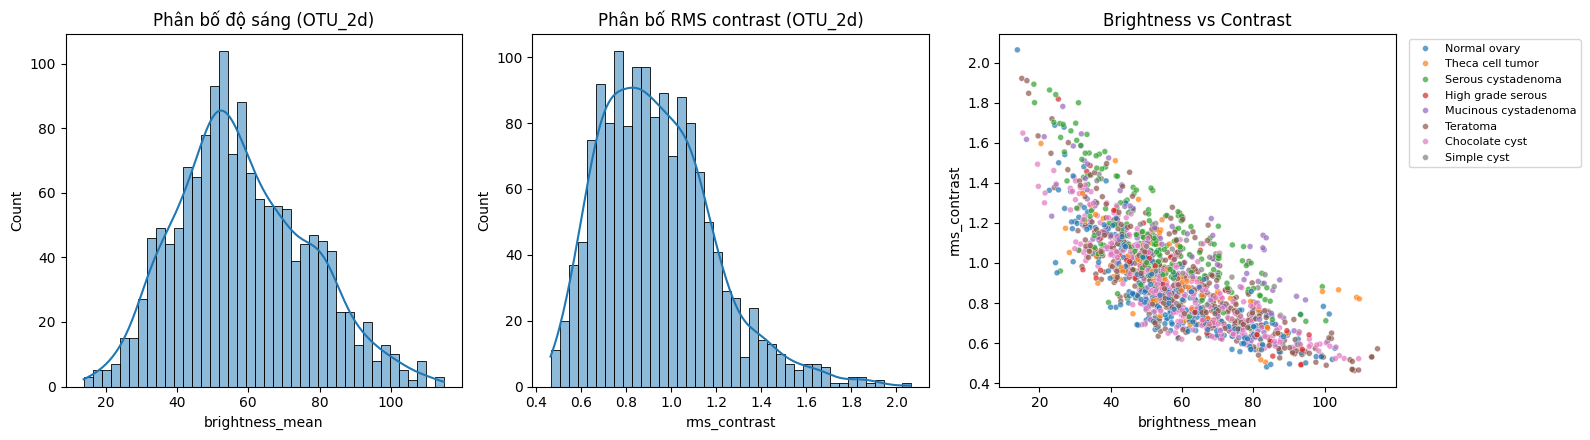

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
quality_cols = [
    ("rms_contrast", "RMS contrast"),
    ("brightness_mean", "Brightness (mean intensity)"),
    ("snr_db", "SNR (dB)"),
    ("sharpness", "Sharpness (gradient magnitude)"),
]
order = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES) if i in set(feat_df["label"])]
for ax, (col, title) in zip(axes.ravel(), quality_cols):
    sns.boxplot(data=feat_df, x="class_name", y=col, hue="class_name", order=order, ax=ax, legend=False)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
    for label in ax.get_xticklabels():
        label.set_ha("right")
plt.suptitle("Chất lượng ảnh theo từng lớp", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(feat_df, x="brightness_mean", bins=40, ax=axes[0], kde=True)
axes[0].set_title("Phân bố độ sáng (OTU_2d)")
sns.histplot(feat_df, x="rms_contrast", bins=40, ax=axes[1], kde=True)
axes[1].set_title("Phân bố RMS contrast (OTU_2d)")
sns.scatterplot(data=feat_df, x="brightness_mean", y="rms_contrast", hue="class_name", ax=axes[2], s=18, alpha=0.7)
axes[2].set_title("Brightness vs Contrast")
axes[2].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


### Nhận xét:
+ Hình 1 (Box plots theo lớp):
    + Độ sáng & độ tương phản: Phân phối khá đồng đều giữa 8 lớp, không có lớp nào bị lệch quá mức --> dữ liệu cân bằng về chất lượng ảnh
    + SNR: Nhiều ảnh có SNR âm (đặc biệt Serous cystadenoma), cho thấy nhiễu cao ở một số mẫu
    + Sharpness: Tương đối ổn định giữa các lớp, median ~6-8
+ Hình 2 (Phân bố & tương quan):
    + Phân bố độ sáng/tương phản trên OTU_2d khá tập trung
    + Brightness vs Contrast: Có tương quan nghịch rõ rệt - ảnh càng sáng thì độ tương phản càng thấp → cần cân bằng histogram để cải thiện
    + Độ sáng tập trung: Hầu hết ảnh có brightness ~40-60, phân phối chuẩn


## Xử lý tăng cường tương phản (Contrast Enhancement) bằng kỹ thuật Cân bằng biểu đồ (Histogram Equalization - HE)

Histogram equalization: contrast trước vs sau HE
       rms_contrast  he_rms_contrast  hist_entropy  he_hist_entropy  \
count      1469.000         1469.000      1469.000         1469.000   
mean          0.935            0.510         6.561            6.313   
std           0.253            0.056         0.606            0.621   
min           0.463            0.312         3.943            3.685   
25%           0.747            0.463         6.166            5.911   
50%           0.904            0.519         6.568            6.306   
75%           1.083            0.562         7.071            6.836   
max           2.063            0.580         7.714            7.507   

       contrast_gain  
count       1469.000  
mean           1.371  
std            0.289  
min            0.654  
25%            1.171  
50%            1.348  
75%            1.537  
max            2.912  


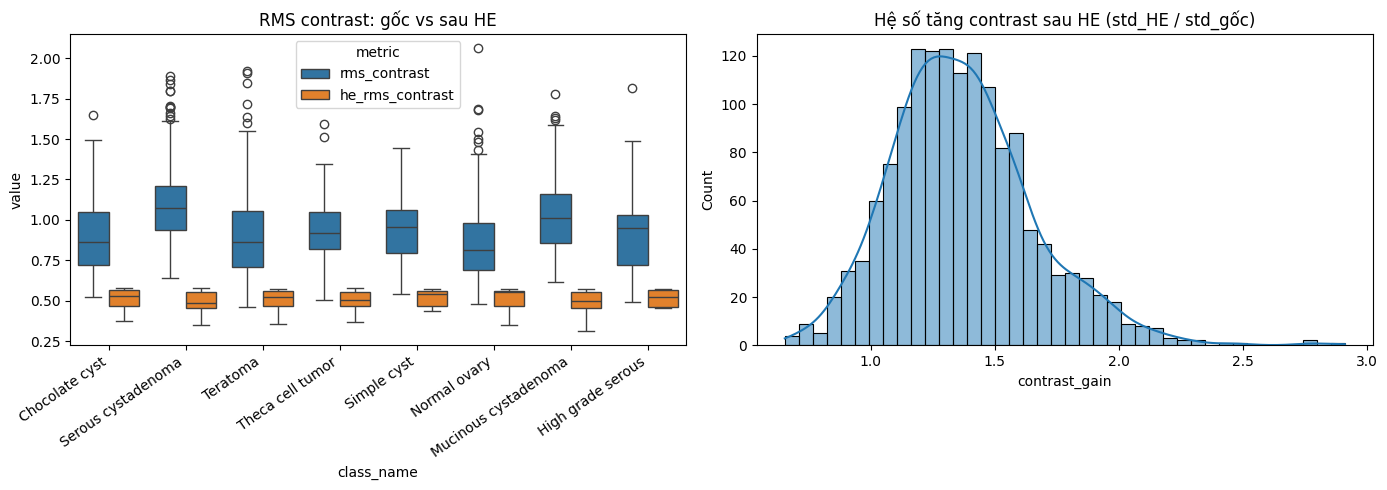

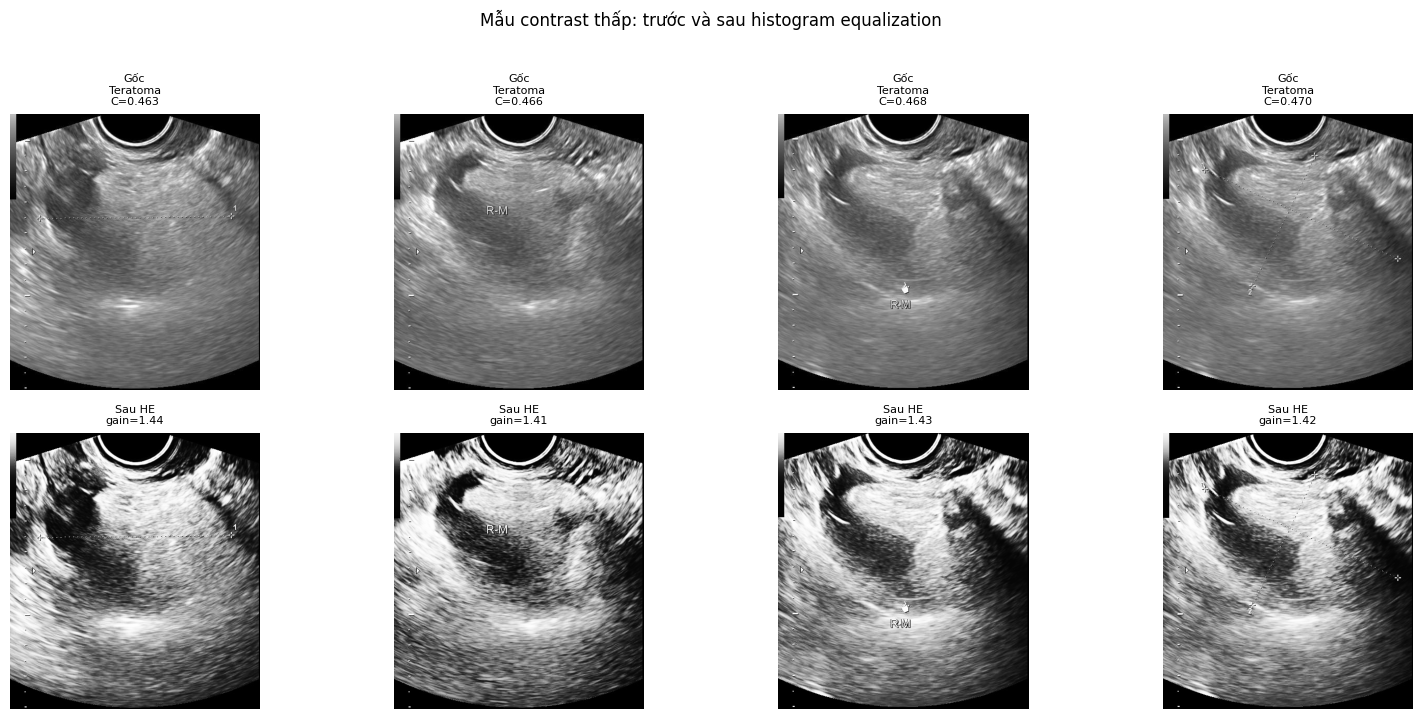

In [16]:
print("Histogram equalization: contrast trước vs sau HE")
print(feat_df[["rms_contrast", "he_rms_contrast", "hist_entropy", "he_hist_entropy", "contrast_gain"]].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
melt = feat_df.melt(
    id_vars=["class_name"],
    value_vars=["rms_contrast", "he_rms_contrast"],
    var_name="metric",
    value_name="value",
)
sns.boxplot(data=melt, x="class_name", y="value", hue="metric", order=order, ax=axes[0])
axes[0].set_title("RMS contrast: gốc vs sau HE")
axes[0].tick_params(axis="x", rotation=35)
for label in axes[0].get_xticklabels():
    label.set_ha("right")
sns.histplot(feat_df, x="contrast_gain", bins=40, kde=True, ax=axes[1])
axes[1].set_title("Hệ số tăng contrast sau HE (std_HE / std_gốc)")
plt.tight_layout()
plt.show()

low_contrast = feat_df.nsmallest(4, "rms_contrast")
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, (_, row) in enumerate(low_contrast.iterrows()):
    img = load_gray(row["image_path"])
    he = equalize_hist(img)
    axes[0, i].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0, i].set_title(f"Gốc\n{row['class_name']}\nC={row['rms_contrast']:.3f}", fontsize=8)
    axes[0, i].axis("off")
    axes[1, i].imshow(he, cmap="gray")
    axes[1, i].set_title(f"Sau HE\ngain={row['contrast_gain']:.2f}", fontsize=8)
    axes[1, i].axis("off")
plt.suptitle("Mẫu contrast thấp: trước và sau histogram equalization", y=1.02)
plt.tight_layout()
plt.show()


In [17]:
print("Nhận xét chất lượng ảnh (tự động):")
print(f"- Độ sáng trung bình toàn tập: {feat_df['brightness_mean'].mean():.1f} ± {feat_df['brightness_mean'].std():.1f}")
print(f"- RMS contrast trung bình: {feat_df['rms_contrast'].mean():.3f}")
print(f"- SNR trung bình: {feat_df['snr_db'].mean():.2f} dB")
print(f"- Sharpness trung bình: {feat_df['sharpness'].mean():.2f}")
print(f"- HE làm tăng contrast trung bình {feat_df['contrast_gain'].mean():.2f} lần (entropy {feat_df['hist_entropy'].mean():.2f} -> {feat_df['he_hist_entropy'].mean():.2f})")
print("\nLớp tối nhất / sáng nhất (mean intensity):")
print(feat_df.groupby("class_name")["brightness_mean"].mean().sort_values().round(2))
print("\nLớp contrast thấp nhất / cao nhất:")
print(feat_df.groupby("class_name")["rms_contrast"].mean().sort_values().round(3))


Nhận xét chất lượng ảnh (tự động):
- Độ sáng trung bình toàn tập: 58.4 ± 18.4
- RMS contrast trung bình: 0.935
- SNR trung bình: 0.89 dB
- Sharpness trung bình: 6.59
- HE làm tăng contrast trung bình 1.37 lần (entropy 6.56 -> 6.31)

Lớp tối nhất / sáng nhất (mean intensity):
class_name
Serous cystadenoma      54.21
High grade serous       56.95
Normal ovary            57.95
Theca cell tumor        58.11
Chocolate cyst          58.31
Mucinous cystadenoma    59.88
Teratoma                60.82
Simple cyst             62.03
Name: brightness_mean, dtype: float64

Lớp contrast thấp nhất / cao nhất:
class_name
Normal ovary            0.861
Chocolate cyst          0.894
Teratoma                0.898
High grade serous       0.932
Theca cell tumor        0.935
Simple cyst             0.936
Mucinous cystadenoma    1.028
Serous cystadenoma      1.102
Name: rms_contrast, dtype: float64


### Nhận xét:
+ Kỹ thuật HE đã kéo giãn độ tương phản hiệu quả (contrast_gain trung bình 1.4 lần), giúp dải dữ liệu ảnh trải rộng và chi tiết rõ nét hơn.
+ Nhìn vào biểu đồ boxplot: Chỉ số he_rms_contrast (màu cam) thấp hơn hẳn so với gốc do ảnh sau khi cân bằng histogram có độ sáng trung bình (mean) cao hơn hẳn so với ảnh gốc khiến mẫu số tăng lên và kéo tỷ lệ này giảm xuống.

Như vậy nhóm sẽ dùng các ảnh đã cân bằng để tăng cường dữ liệu cho mô hình

## 2.6 Phân tích Annotation (Đặc trưng hình thái)

- **Tumor size distribution** (diện tích tuyệt đối và tỷ lệ so với toàn ảnh): Dùng để đánh giá mức độ phát triển của khối u, phát hiện dữ liệu nhiễu (outlier) nếu tỷ lệ quá nhỏ hoặc quá lớn, đồng thời giúp mô hình AI học được đặc trưng bất biến theo tỷ lệ (scale-invariance).

- **Aspect ratio** (tỷ lệ chiều cao/chiều rộng của bounding box): Dùng để mô tả hình dáng tổng thể của tổn thương (tròn đều hay bị kéo dài), hỗ trợ phân biệt các loại u có hình thái đặc thù.

- **Shape complexity** (độ phức tạp hình dạng qua `circularity` và `solidity`): Dùng để đánh giá ranh giới và mức độ xâm lấn của khối u. Khối u lành tính thường có viền trơn tru (chỉ số cao), trong khi khối u ác tính thường phát triển xâm lấn, viền răng cưa hoặc lõm sâu (chỉ số thấp).

- **Number of lesions** (số vùng tổn thương riêng biệt có diện tích ≥ 30 pixel): Dùng để phân biệt cấu trúc đơn ổ (như *Simple cyst*) và đa ổ (như *Serous cystadenoma*). Ngưỡng 30 pixel được sử dụng để tự động lọc bỏ các nhiễu hạt nhỏ, giúp mô hình nhận diện chính xác cấu trúc thực sự của bệnh lý.

Số ảnh dùng cho phân tích annotation: 1469
       tumor_area_px  tumor_area_ratio  aspect_ratio  circularity  solidity  \
count       1469.000          1469.000      1469.000     1469.000  1469.000   
mean       59095.736             0.146         0.862        0.777     0.964   
std        46684.658             0.113         0.211        0.086     0.031   
min         1523.000             0.003         0.384        0.379     0.705   
25%        20746.000             0.055         0.718        0.732     0.954   
50%        48042.000             0.119         0.841        0.797     0.975   
75%        87524.000             0.213         0.970        0.842     0.985   
max       324351.000             0.618         2.295        0.907     0.995   

       n_lesions  
count   1469.000  
mean       1.014  
std        0.122  
min        1.000  
25%        1.000  
50%        1.000  
75%        1.000  
max        3.000  


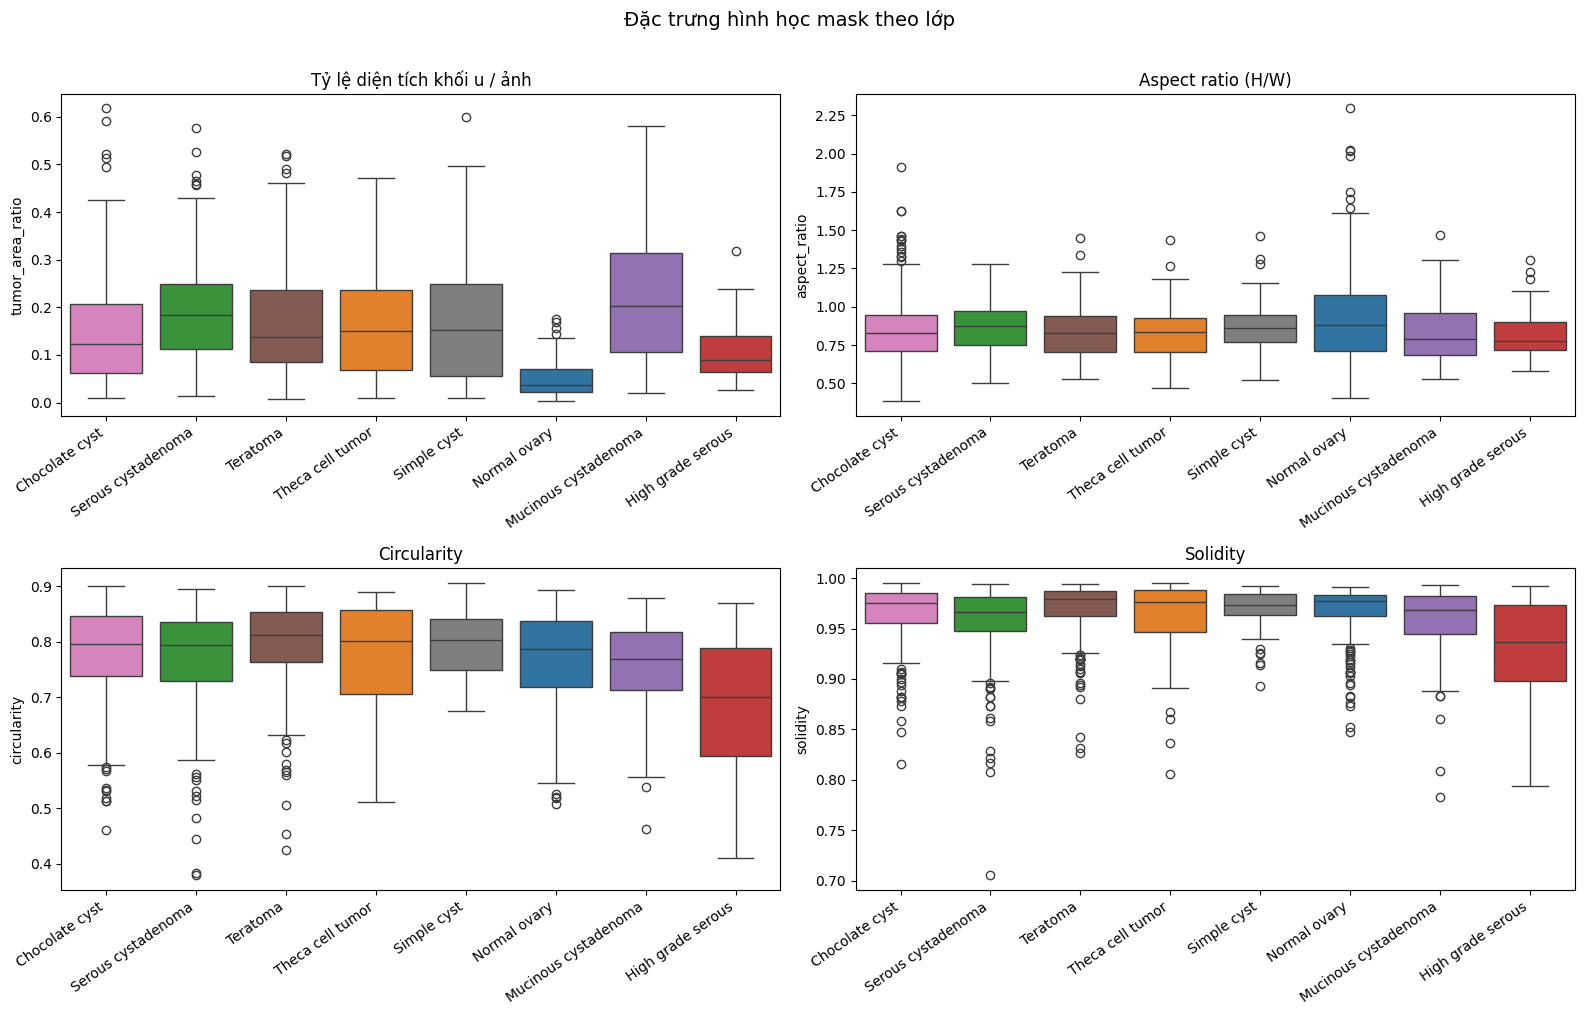

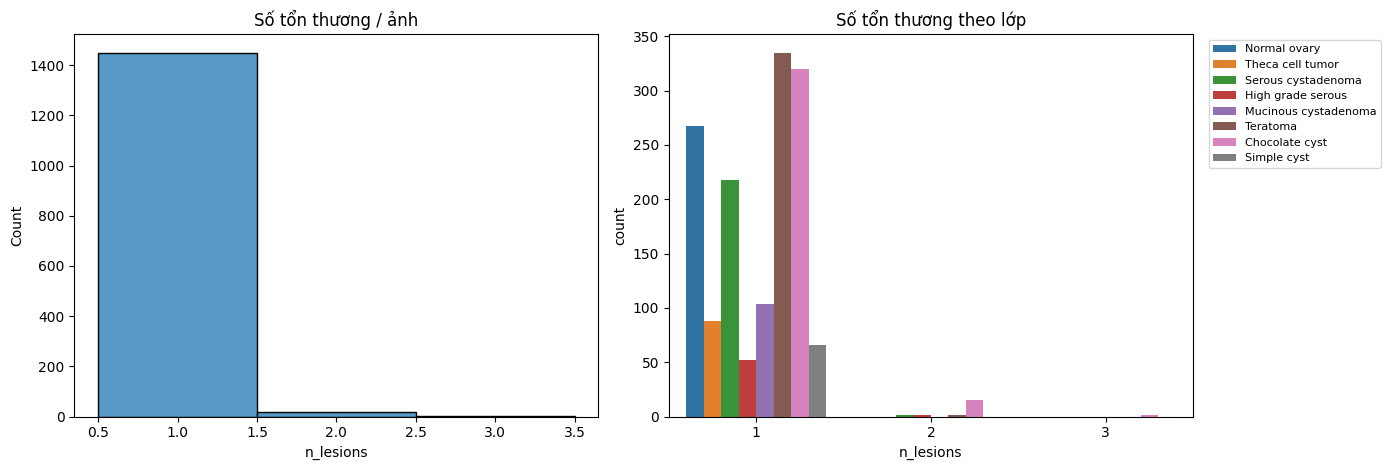


Tỷ lệ diện tích khối u trung bình theo lớp:
                      count   mean    std  median
class_name                                       
Chocolate cyst          336  0.150  0.114   0.124
High grade serous        53  0.107  0.061   0.090
Mucinous cystadenoma    104  0.219  0.131   0.203
Normal ovary            267  0.049  0.035   0.037
Serous cystadenoma      219  0.193  0.106   0.184
Simple cyst              66  0.165  0.135   0.152
Teratoma                336  0.164  0.104   0.137
Theca cell tumor         88  0.162  0.112   0.151

Số ảnh có >1 tổn thương: 19
     image_name      class_name  n_lesions  subset
66     1213.JPG  Chocolate cyst          2  OTU_2d
208    1265.JPG  Chocolate cyst          2  OTU_2d
213      28.JPG  Chocolate cyst          2  OTU_2d
226    1310.JPG  Chocolate cyst          2  OTU_2d
334    1266.JPG  Chocolate cyst          2  OTU_2d
452      30.JPG  Chocolate cyst          2  OTU_2d
478    1284.JPG  Chocolate cyst          2  OTU_2d
671    1209.JPG  C

In [18]:
ann_df = feat_df[feat_df["has_mask"]].copy()
print("Số ảnh dùng cho phân tích annotation:", len(ann_df))
print(ann_df[["tumor_area_px", "tumor_area_ratio", "aspect_ratio", "circularity", "solidity", "n_lesions"]].describe().round(3))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ann_plots = [
    ("tumor_area_ratio", "Tỷ lệ diện tích khối u / ảnh"),
    ("aspect_ratio", "Aspect ratio (H/W)"),
    ("circularity", "Circularity"),
    ("solidity", "Solidity"),
]
for ax, (col, title) in zip(axes.ravel(), ann_plots):
    sns.boxplot(data=ann_df, x="class_name", y=col, hue="class_name", order=order, ax=ax, legend=False)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
    for label in ax.get_xticklabels():
        label.set_ha("right")
plt.suptitle("Đặc trưng hình học mask theo lớp", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.histplot(ann_df, x="n_lesions", discrete=True, ax=axes[0])
axes[0].set_title("Số tổn thương / ảnh")
sns.countplot(data=ann_df, x="n_lesions", hue="class_name", ax=axes[1])
axes[1].set_title("Số tổn thương theo lớp")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

print("\nTỷ lệ diện tích khối u trung bình theo lớp:")
print(ann_df.groupby("class_name")["tumor_area_ratio"].agg(["count", "mean", "std", "median"]).round(3))
print("\nSố ảnh có >1 tổn thương:", int((ann_df["n_lesions"] > 1).sum()))
print(ann_df.loc[ann_df["n_lesions"] > 1, ["image_name", "class_name", "n_lesions", "subset"]].head(15))


### Nhận xét chi tiết đặc trưng hình học

- **Kích thước và tỷ lệ diện tích (Tumor size distribution):**
  - **Mô tả:** Trung bình, vùng tổn thương chiếm 14.6% diện tích ảnh (độ lệch chuẩn 11.3%). Lớp *Mucinous cystadenoma* có tỷ lệ cao nhất (trung bình 21.9%), trong khi *Normal ovary* thấp nhất (4.9%).
  
  --> Sự chênh lệch này là một đặc trưng phân loại rất mạnh. *Normal ovary* thực chất chỉ là vùng ROI nhỏ được đánh dấu, trong khi *Mucinous cystadenoma* là khối u thực sự có kích thước lớn, chiếm hơn 1/5 khung hình. Như vậy mô hình sẽ dễ dàng phân biết được *Normal ovary* và *Mucinous cystadenoma*

- **Hình dạng và ranh giới (Circularity & Solidity):**
  - **Mô tả:** Độ đặc (Solidity) trung bình khá cao (0.96), nhưng độ tròn (Circularity) trung bình chỉ ở mức 0.77. Đặc biệt, lớp *High grade serous* có median của cả hai chỉ số này thấp nhất, độ phân tán (std) lớn nhất và xuất hiện nhiều outlier.
  
  --> Điều này phản ánh đặc điểm lâm sàng: khối u lành tính thường có biên giới trơn tru, đầy đặn. Ngược lại, khối u ác tính (*High grade serous*) có xu hướng phát triển xâm lấn, biên giới răng cưa, hình dạng méo mó và phức tạp hơn do đó các outlier có circularity rất thấp.

- **Tỷ lệ khung hình (Aspect ratio):**
  - **Mô tả:** Median của toàn bộ tập dữ liệu nằm quanh mức 0.84, với 50% dữ liệu (từ Q1 đến Q3) tập trung chặt chẽ trong khoảng 0.72 - 0.97.
  
  --> Các tổn thương có xu hướng hơi dẹt ngang hoặc gần tròn. Sự khác biệt về aspect ratio giữa các lớp bệnh không quá lớn, do đó chỉ số này có thể ít mang tính phân loại hơn so với circularity hay solidity.

- **Số lượng tổn thương (Number of lesions):**
  - **Mô tả:**  Đa số ảnh (1450/1469 mẫu OTU_2d, chiếm xấp xỉ 99%) chỉ chứa đúng 1 tổn thương (`n_lesions = 1`). Chỉ có 19 ảnh có $\ge$ 2 tổn thương, và chúng tập trung chủ yếu ở lớp *Chocolate cyst* và *Teratoma*.
  
  --> Phù hợp với đặc điểm bệnh lý thực tế: đa số là u đơn ổ. Việc xuất hiện nhiều vùng tổn thương tách biệt (đa ổ) là một dấu hiệu đặc trưng (signature) giúp gợi ý chẩn đoán phân biệt cho *Chocolate cyst* và *Teratoma*.

> **Kết luận cho mô hình:** Các đặc trưng hình học (đặc biệt là `tumor_area_ratio`, `circularity` và `solidity`) mang tính phân loại cao. Việc kết hợp các chỉ số này làm đầu vào (hoặc để mô hình CNN tự học các đặc trưng tương đương) sẽ giúp phân biệt rõ ràng giữa khối u lành tính (tròn, viền trơn) và ác tính (viền phức tạp, méo mó).


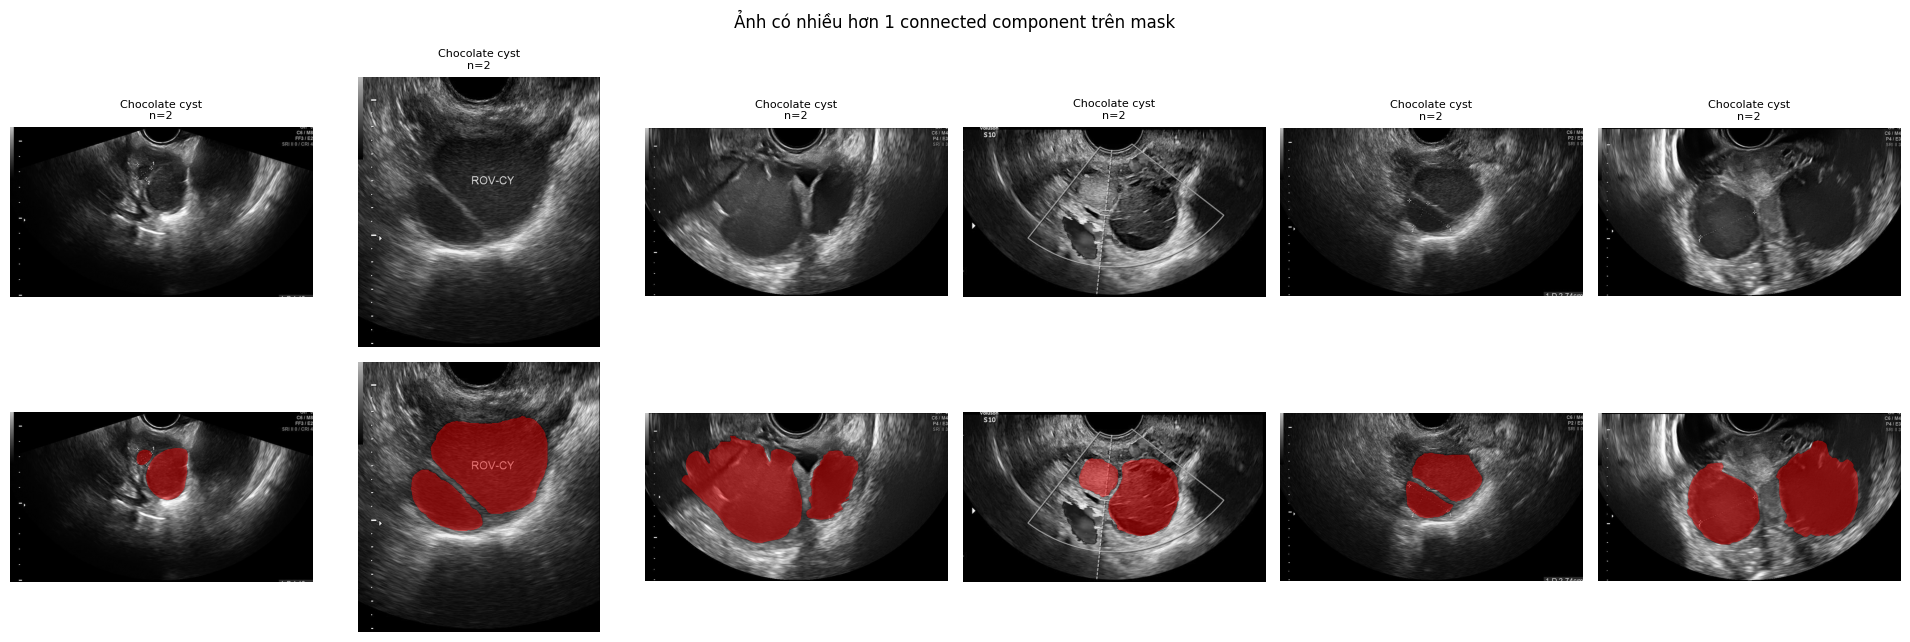

In [19]:
multi = ann_df[ann_df["n_lesions"] >= 2].head(6)
if len(multi) == 0:
    print("Không có ảnh >1 tổn thương để minh họa.")
else:
    fig, axes = plt.subplots(2, len(multi), figsize=(3.2 * len(multi), 6.5))
    if len(multi) == 1:
        axes = np.array(axes).reshape(2, 1)
    for i, (_, row) in enumerate(multi.iterrows()):
        img = load_gray(row["image_path"])
        mask = load_mask(row["mask_path"], shape=img.shape)
        axes[0, i].imshow(img, cmap="gray")
        axes[0, i].set_title(f"{row['class_name']}\nn={row['n_lesions']}", fontsize=8)
        axes[0, i].axis("off")
        axes[1, i].imshow(img, cmap="gray")
        if mask is not None and mask.shape == img.shape:
            axes[1, i].imshow(np.ma.masked_where(mask == 0, mask), cmap="autumn", alpha=0.45)
        axes[1, i].axis("off")
    plt.suptitle("Ảnh có nhiều hơn 1 connected component trên mask")
    plt.tight_layout()
    plt.show()


## 2.7 Phân tích Intensity Distribution

- **Histogram per class:** Biểu đồ tần suất mức xám của các pixel trong vùng mask (hoặc toàn ảnh) được nhóm theo từng lớp bệnh. Dùng để nhận diện **đặc trưng phân bố mức xám** riêng biệt của từng loại u (ví dụ: u nang chứa dịch thường tối hơn u đặc), từ đó đánh giá xem các lớp bệnh có thể phân tách được bằng ngưỡng cường độ hay không.

- **Pixel value statistics (mean, std, skewness, kurtosis):** Mô tả hình dạng phân bố điểm ảnh. `Mean` và `std` đo độ sáng trung bình và độ trải rộng (tương phản); `skewness` (độ lệch) và `kurtosis` (độ nhọn) đo sự bất đối xứng và mức độ tập trung của các điểm ảnh. Dùng để định lượng đặc tính kết cấu (texture) và phát hiện các bất thường trong phân bố tín hiệu của mô bệnh.

- **Dynamic range (`max - min`):** Khoảng chênh lệch giữa mức xám cao nhất và thấp nhất trong ảnh. Dùng để đánh giá mức độ tương phản của ảnh: nếu dải động quá hẹp, ảnh sẽ thiếu tương phản và khó phân biệt chi tiết; ngược lại, dải động rộng giúp tận dụng tốt toàn bộ thang đo 0-255, từ đó quyết định có cần kéo giãn histogram trước khi đưa vào mô hình.


Thống kê intensity trên ROI (mask nếu có):
                      roi_mean  roi_std  roi_skewness  roi_kurtosis  \
class_name                                                            
Chocolate cyst          55.095   26.827         2.036        10.813   
High grade serous       75.703   35.939         0.790         2.080   
Mucinous cystadenoma    44.453   33.678         2.222         9.193   
Normal ovary            71.474   35.007         1.464         5.439   
Serous cystadenoma      34.334   34.397         2.568        10.468   
Simple cyst             46.113   33.806         2.546        10.942   
Teratoma                90.850   40.455         0.706         1.780   
Theca cell tumor        57.000   34.239         1.712         5.480   

                      roi_dynamic_range  
class_name                               
Chocolate cyst                  239.899  
High grade serous               245.226  
Mucinous cystadenoma            245.788  
Normal ovary                    245.

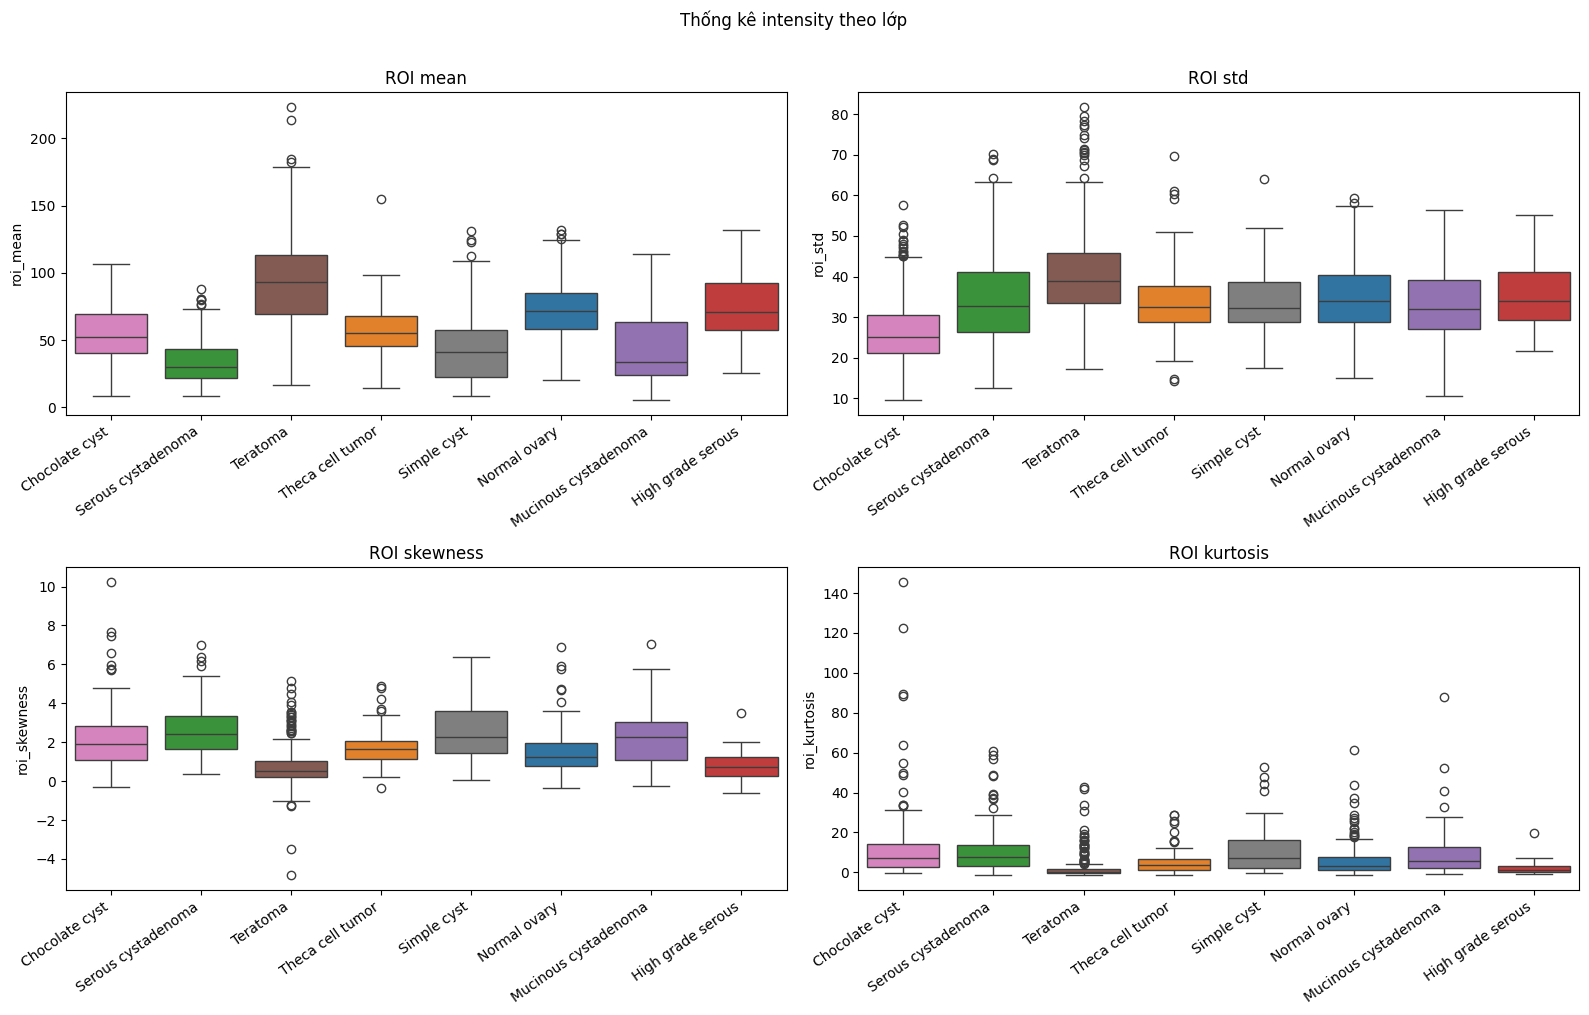

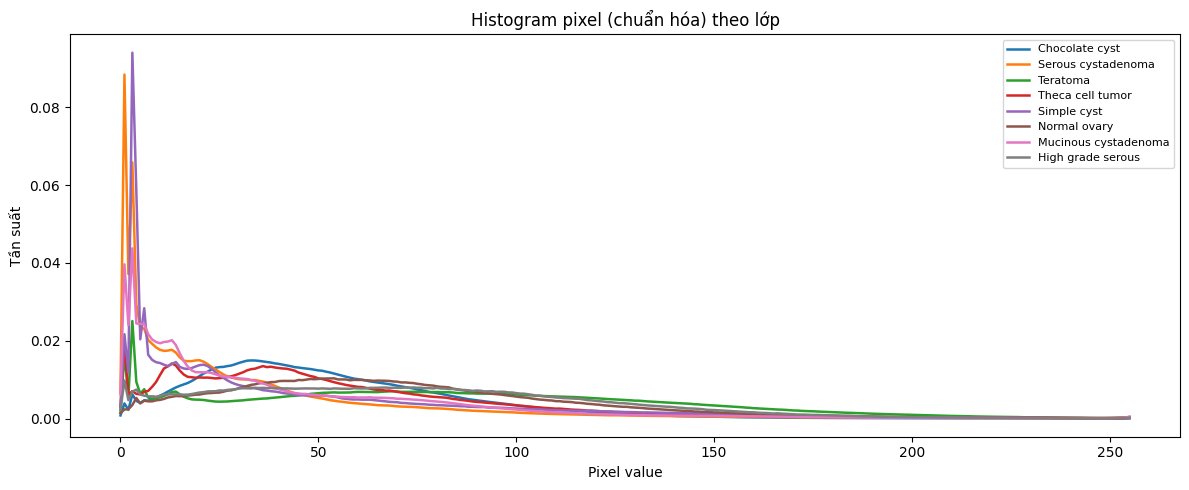

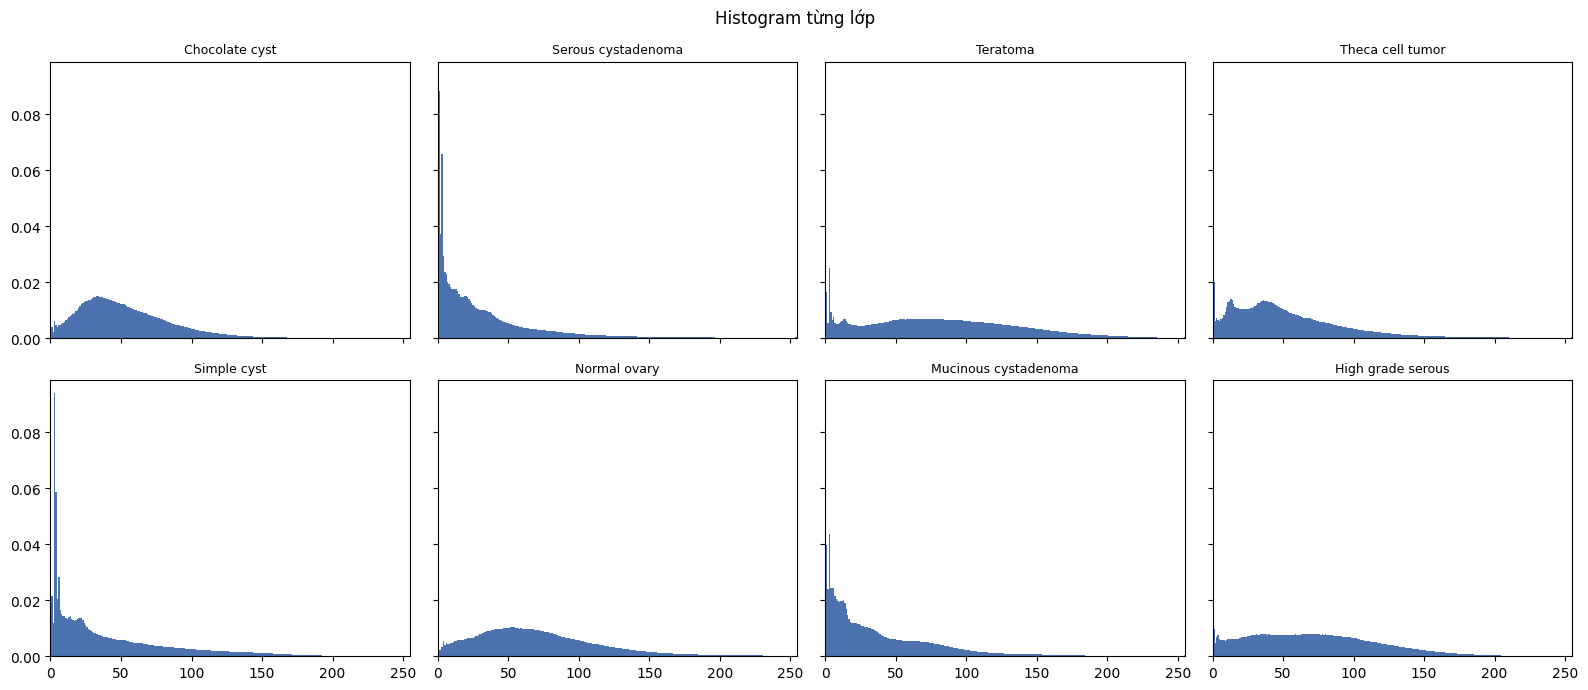

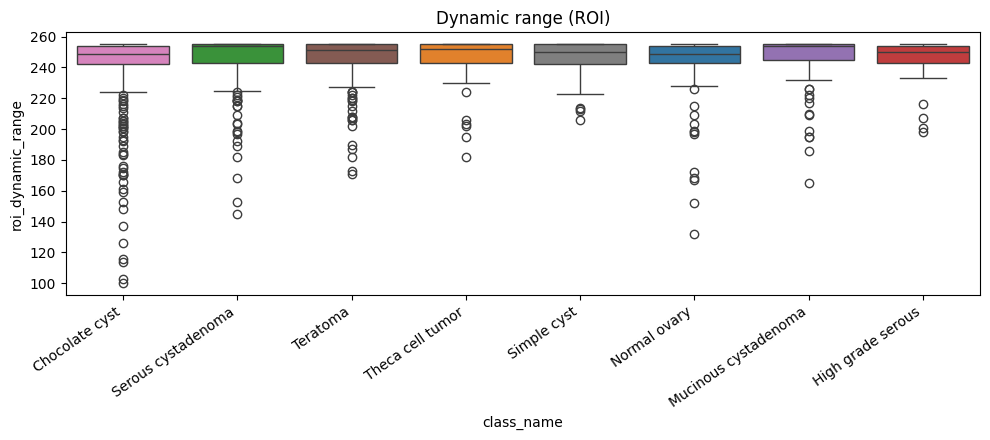

In [20]:
print("Thống kê intensity trên ROI (mask nếu có):")
print(feat_df.groupby("class_name")[["roi_mean", "roi_std", "roi_skewness", "roi_kurtosis", "roi_dynamic_range"]].mean().round(3))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col, title in zip(
    axes.ravel(),
    ["roi_mean", "roi_std", "roi_skewness", "roi_kurtosis"],
    ["ROI mean", "ROI std", "ROI skewness", "ROI kurtosis"],
):
    sns.boxplot(data=feat_df, x="class_name", y=col, hue="class_name", order=order, ax=ax, legend=False)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
    for label in ax.get_xticklabels():
        label.set_ha("right")
plt.suptitle("Thống kê intensity theo lớp", y=1.01)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(256)
for lab in sorted(class_hists):
    hist = class_hists[lab]
    total = hist.sum()
    if total <= 0:
        continue
    ax.plot(x, hist / total, label=CLASS_NAMES.get(lab, str(lab)), linewidth=1.8)
ax.set_title("Histogram pixel (chuẩn hóa) theo lớp")
ax.set_xlabel("Pixel value")
ax.set_ylabel("Tần suất")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)
for ax, lab in zip(axes.ravel(), range(8)):
    hist = class_hists.get(lab, np.zeros(256))
    total = hist.sum()
    ax.bar(np.arange(256), hist / total if total else hist, width=1.0, color="#4C72B0")
    ax.set_title(CLASS_NAMES.get(lab, str(lab)), fontsize=9)
    ax.set_xlim(0, 255)
plt.suptitle("Histogram từng lớp")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=feat_df, x="class_name", y="roi_dynamic_range", hue="class_name", order=order, ax=ax, legend=False)
ax.set_title("Dynamic range (ROI)")
ax.tick_params(axis="x", rotation=35)
for label in ax.get_xticklabels():
    label.set_ha("right")
plt.tight_layout()
plt.show()


### Nhận xét phân bố cường độ điểm ảnh (Intensity Distribution)

**1. ROI Mean (Độ sáng trung bình):**
- **Teratoma** có độ sáng trung bình cao nhất (median ~90), trong khi **Serous cystadenoma** tối nhất (median ~30-40).
- Sự khác biệt rõ rệt về độ sáng giữa các lớp cho thấy đây có thể là đặc trưng phân loại quan trọng.

**2. ROI Std (Độ lệch chuẩn - tương phản cục bộ):**
- **Teratoma** có std cao nhất (~40), phản ánh cấu trúc phức tạp, đa dạng về mô.
- **Chocolate cyst** có std thấp nhất (~27), cho thấy cấu trúc đồng nhất hơn.
- Nhiều outliers cho thấy sự biến thiên lớn trong cùng một lớp bệnh.

**3. ROI Skewness (Độ lệch phân bố):**
- Hầu hết các lớp có skewness dương (phân bố lệch phải) → đa số pixel tập trung ở vùng tối, đuôi dài về vùng sáng.
- **Teratoma** có skewness gần 0 nhất → phân bố đối xứng hơn, phù hợp với cấu trúc hỗn hợp.

**4. ROI Kurtosis (Độ nhọn):**
- Nhiều outliers với kurtosis rất cao (>100) → phân bố có đuôi rất nặng, xuất hiện các giá trị cực trị.
- **Teratoma** và **High grade serous** có kurtosis thấp nhất (~1.8–2.1) → phân bố "phẳng" hơn, ít tập trung cực trị.

**5. Histogram theo lớp:**
- Tất cả các lớp đều có phân bố lệch phải mạnh, đỉnh tập trung ở pixel value < 50.
- **Normal ovary** có phân bố trải rộng hơn, trong khi các lớp khác tập trung nhiều ở vùng tối.
- Các đường histogram chồng lấn nhiều → khó phân loại chỉ dựa vào cường độ điểm ảnh đơn thuần.

**6. Dynamic Range (Dải động):**
- Median của tất cả các lớp đều cao (~240-250/255) → hầu hết ảnh sử dụng tốt toàn bộ dải cường độ.
- Nhiều outliers có dynamic range thấp (100-200) → một số ảnh bị thiếu tương phản, có thể cần xử lý trước.

## 2.8 Phân tích Texture Features

- **GLCM (Gray-Level Co-occurrence Matrix):** Đo thống kê bậc 2 (quan hệ giữa các pixel). Các chỉ số `contrast` (độ tương phản), `correlation` (tương quan), `energy` (năng lượng), `homogeneity` (độ đồng nhất) dùng để **định lượng độ thô/mịn và tính đều đặn của kết cấu mô** (ví dụ: mô ác tính thường thô và không đều hơn mô lành).

- **LBP (Local Binary Pattern):** Đo mẫu cục bộ. Entropy và Energy của histogram LBP dùng để **phát hiện các mẫu vi cấu trúc lặp lại** như vân, hạt, hoặc cấu trúc tổ ong đặc trưng của từng loại bệnh lý.

- **Gabor Filters:** Đo đáp ứng theo hướng/tần số. Năng lượng đáp ứng ở 4 hướng × 2 tần số dùng để **trích xuất đặc trưng kết cấu đa hướng và đa tỷ lệ**, giúp nhận diện các cấu trúc định hướng như sợi, vách ngăn, hoặc ranh giới phân cách giữa các mô.

Texture được tính trên ROI khối u (bbox mask), resize 128×128. Nếu không có mask thì dùng toàn ảnh.


                      glcm_contrast  glcm_correlation  glcm_energy  \
class_name                                                           
Chocolate cyst               3.4866            0.9228       0.1700   
High grade serous            4.8180            0.9021       0.1255   
Mucinous cystadenoma         4.3361            0.9426       0.2434   
Normal ovary                 4.3730            0.9033       0.1443   
Serous cystadenoma           3.9014            0.9520       0.2941   
Simple cyst                  3.9957            0.9464       0.2599   
Teratoma                     4.5085            0.9154       0.1488   
Theca cell tumor             4.1275            0.9263       0.1751   

                      glcm_homogeneity  lbp_entropy  gabor_energy_mean  
class_name                                                              
Chocolate cyst                  0.6163       3.1877             4.4539  
High grade serous               0.5403       3.1895             7.0859  
Mucinou

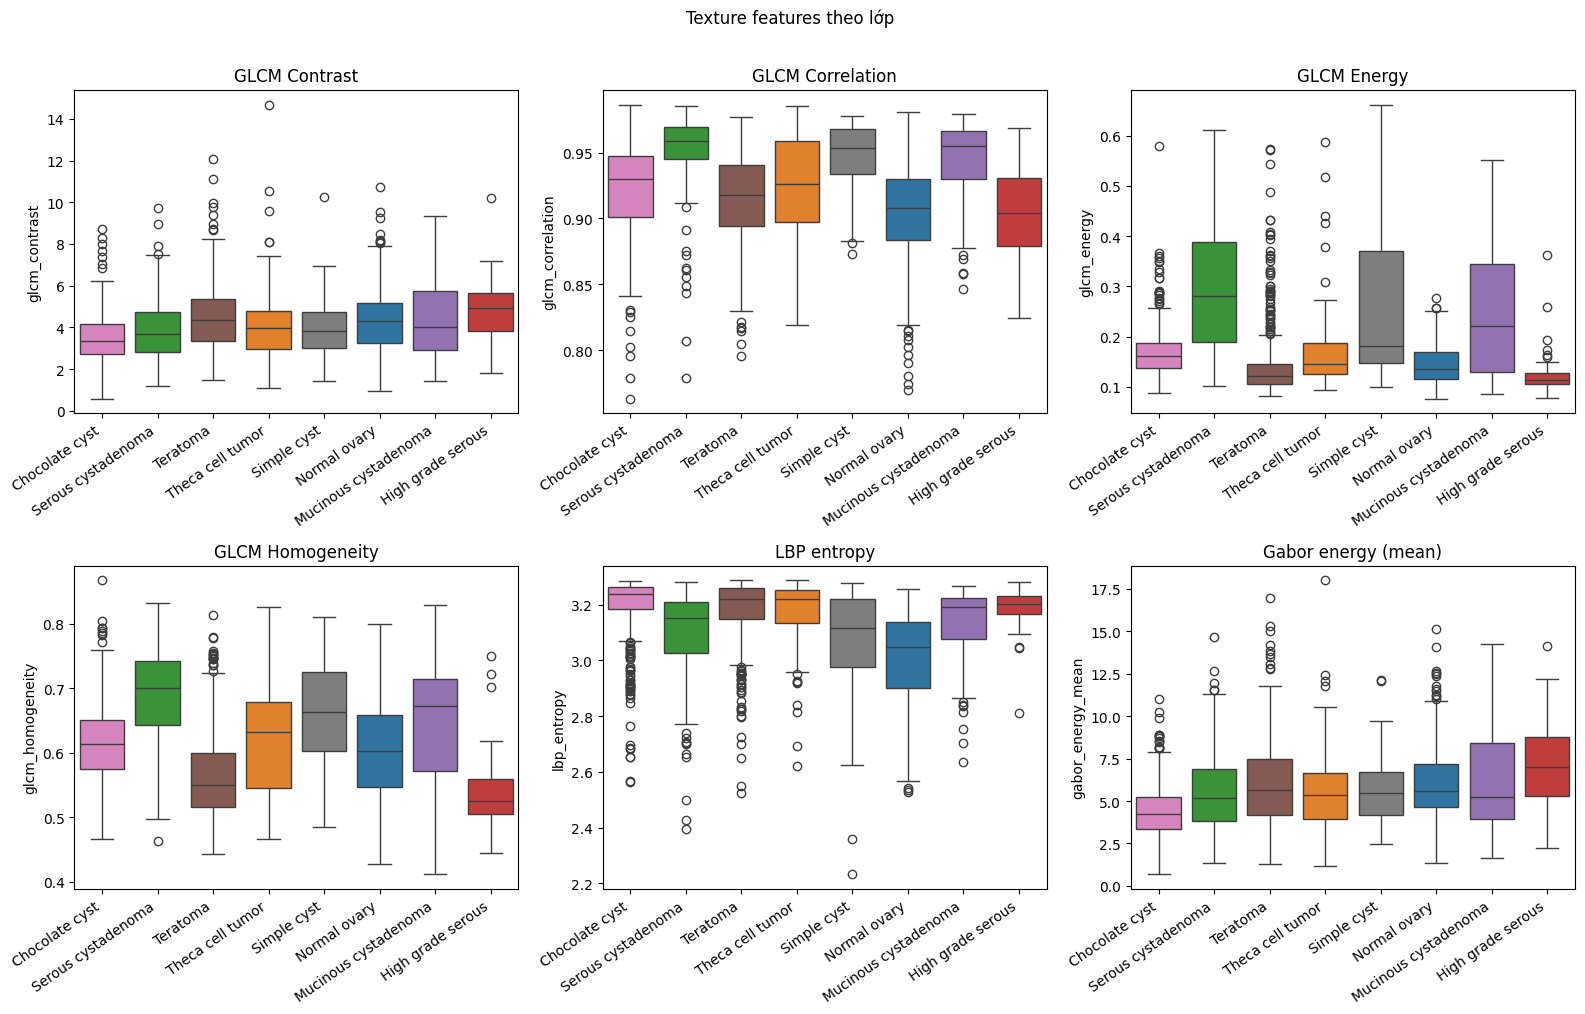

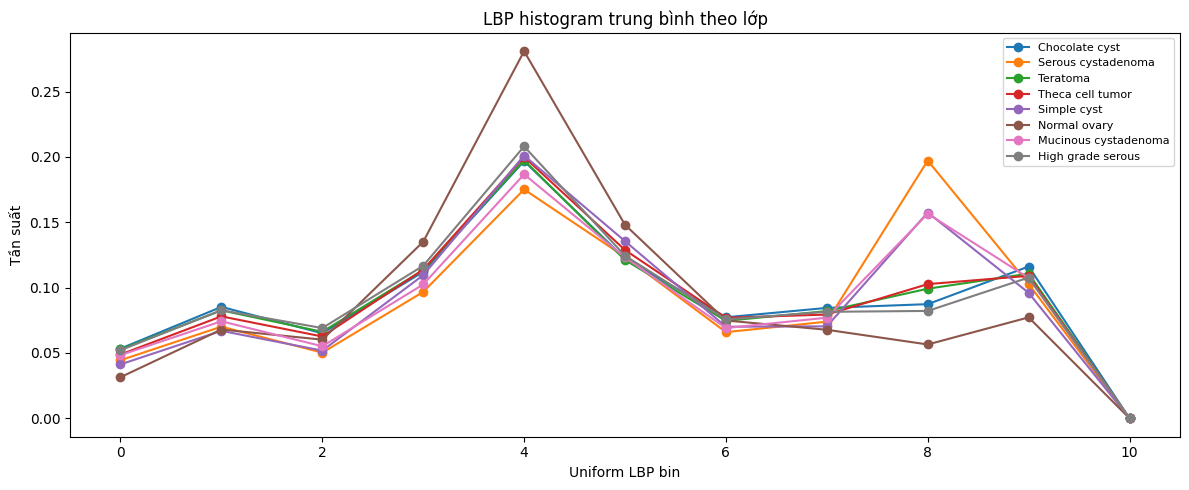

In [21]:
tex_cols = ["glcm_contrast", "glcm_correlation", "glcm_energy", "glcm_homogeneity", "lbp_entropy", "gabor_energy_mean"]
print(feat_df.groupby("class_name")[tex_cols].mean().round(4))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
titles = [
    "GLCM Contrast", "GLCM Correlation", "GLCM Energy",
    "GLCM Homogeneity", "LBP entropy", "Gabor energy (mean)",
]
for ax, col, title in zip(axes.ravel(), tex_cols, titles):
    sns.boxplot(data=feat_df, x="class_name", y=col, hue="class_name", order=order, ax=ax, legend=False)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
    for label in ax.get_xticklabels():
        label.set_ha("right")
plt.suptitle("Texture features theo lớp", y=1.01)
plt.tight_layout()
plt.show()

lbp_bins = [c for c in feat_df.columns if c.startswith("lbp_bin_")]
lbp_mean = feat_df.groupby("label")[lbp_bins].mean()
fig, ax = plt.subplots(figsize=(12, 5))
for lab in lbp_mean.index:
    ax.plot(range(len(lbp_bins)), lbp_mean.loc[lab].values, marker="o", label=CLASS_NAMES.get(lab, str(lab)))
ax.set_title("LBP histogram trung bình theo lớp")
ax.set_xlabel("Uniform LBP bin")
ax.set_ylabel("Tần suất")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Nhận xét đặc trưng kết cấu (Texture Features)

**1. GLCM Features:**
- **Contrast & Homogeneity:** *High grade serous* có contrast cao nhất (4.82) và homogeneity thấp nhất (0.54) → kết cấu thô, không đồng nhất, phù hợp với đặc điểm mô ác tính xâm lấn. Ngược lại, *Serous cystadenoma* có homogeneity cao nhất (0.69) → mô đồng đều hơn.
- **Correlation:** *Mucinous cystadenoma* và *Serous cystadenoma* có correlation cao nhất (0.94–0.95) → pixel lân cận có quan hệ tuyến tính chặt chẽ, phản ánh cấu trúc mô có trật tự.
- **Energy:** *Serous cystadenoma* có energy cao nhất (0.29), *High grade serous* thấp nhất (0.13) → mô lành có phân bố mức xám tập trung hơn, trong khi mô ác tính phân tán và hỗn loạn.

**2. LBP Entropy:**
- Các lớp có entropy khá đồng đều (3.01–3.19), cho thấy độ phức tạp của vi cấu trúc tương tự nhau.
- *High grade serous* và *Chocolate cyst* có entropy cao nhất (~3.19) → cấu trúc vi mô đa dạng, ít mẫu lặp lại.

**3. Gabor Energy (mean):**
- *High grade serous* có năng lượng Gabor cao nhất (7.09), gấp ~1.6 lần *Chocolate cyst* (4.45) → mô ác tính chứa nhiều cấu trúc định hướng mạnh (sợi, vách ngăn, ranh giới phức tạp) ở nhiều hướng và tần số.

**4. LBP Histogram trung bình theo lớp:**
- Hầu hết các lớp có 2 đỉnh chính tại **bin 4** (mẫu phẳng/đều) và **bin 8** (mẫu cạnh/viền).
- *Normal ovary* có peak bin 4 cao nhất (~0.27) → cấu trúc mô đồng nhất, ít biến thiên cục bộ.
- *Serous cystadenoma* nổi bật với peak bin 8 cao nhất (~0.20) → chứa nhiều mẫu dạng cạnh, phù hợp với cấu trúc nang có vách.

> **Kết luận:** Bộ đặc trưng kết cấu (đặc biệt là GLCM Contrast/Homogeneity và Gabor Energy) phân biệt rõ ràng giữa mô lành và mô ác tính (*High grade serous*). Mô ác tính có kết cấu thô, không đồng nhất, nhiều cấu trúc định hướng — phản ánh đúng đặc điểm mô học của ung thư buồng trứng giai đoạn cao.

In [22]:
# Minh họa texture trên 1 mẫu / lớp
sample_per_class = (
    feat_df.sort_values("tumor_area_ratio", ascending=False)
    .groupby("label", as_index=False)
    .first()
)

n = len(sample_per_class)
fig, axes = plt.subplots(n, 5, figsize=(16, 2.6 * n))
if n == 1:
    axes = np.array(axes).reshape(1, -1)

for i, (_, row) in enumerate(sample_per_class.iterrows()):
    img = load_gray(row["image_path"])
    mask = load_mask(row["mask_path"], shape=img.shape) if row["has_mask"] else None
    roi = roi_from_mask(img, mask if (mask is not None and mask.shape == img.shape) else None)
    roi_r = resize(roi, (TEXTURE_SIZE, TEXTURE_SIZE), anti_aliasing=True, preserve_range=True)
    roi_u8 = np.clip(roi_r, 0, 255).astype(np.uint8)
    lbp = local_binary_pattern(roi_u8, P=8, R=1, method="uniform")
    g0, _ = gabor(roi_u8, frequency=0.10, theta=0)
    g1, _ = gabor(roi_u8, frequency=0.25, theta=np.pi / 4)
    quantized = (roi_u8.astype(np.float32) * (GLCM_LEVELS - 1) / 255.0).astype(np.uint8)
    glcm = graycomatrix(quantized, [1], [0], levels=GLCM_LEVELS, symmetric=True, normed=True)

    axes[i, 0].imshow(roi_u8, cmap="gray")
    axes[i, 0].set_ylabel(row["class_name"], fontsize=8)
    axes[i, 0].set_title("ROI" if i == 0 else "", fontsize=9)
    axes[i, 1].imshow(lbp, cmap="magma")
    axes[i, 1].set_title("LBP" if i == 0 else "", fontsize=9)
    axes[i, 2].imshow(g0, cmap="gray")
    axes[i, 2].set_title("Gabor f=0.10" if i == 0 else "", fontsize=9)
    axes[i, 3].imshow(g1, cmap="gray")
    axes[i, 3].set_title("Gabor f=0.25" if i == 0 else "", fontsize=9)
    axes[i, 4].imshow(glcm[:, :, 0, 0], cmap="viridis")
    axes[i, 4].set_title("GLCM (d=1, 0°)" if i == 0 else "", fontsize=9)
    for ax in axes[i]:
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("Visualize texture features (1 mẫu / lớp)", y=1.01)
plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

## 2.9 Phân tích tương quan giữa các lớp

Gom đặc trưng EDA (quality + shape + intensity + texture) để xem lớp nào chồng lấn trên không gian đặc trưng thủ công.

- PCA 2D: mức chồng lấn tổng thể
- Cosine similarity giữa centroid lớp: cặp nào gần nhau về đặc trưng


PCA explained variance: [0.261 0.123]


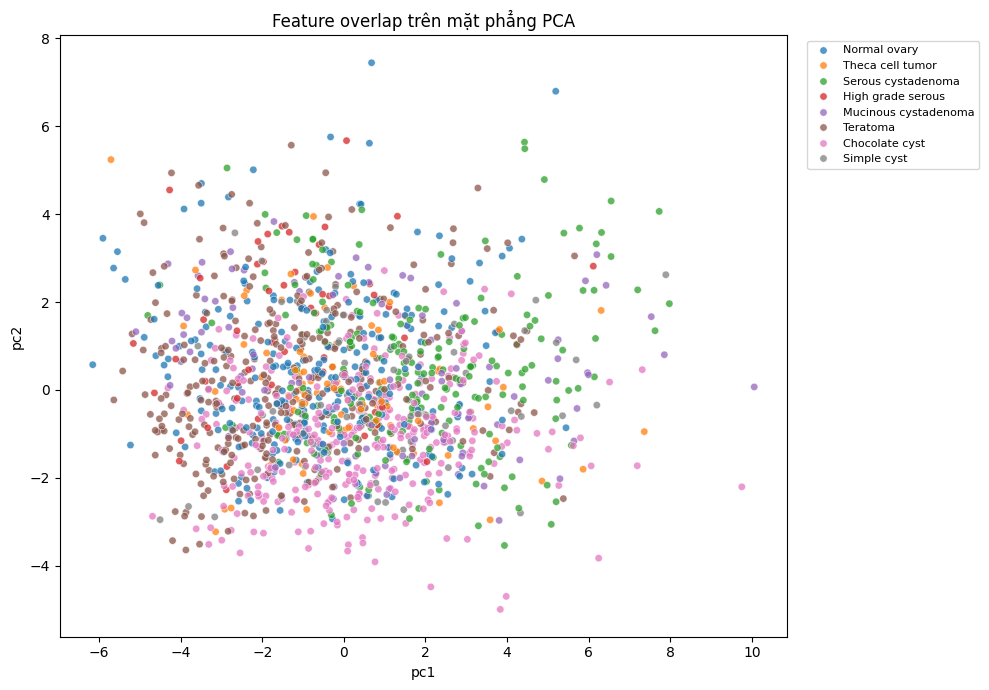

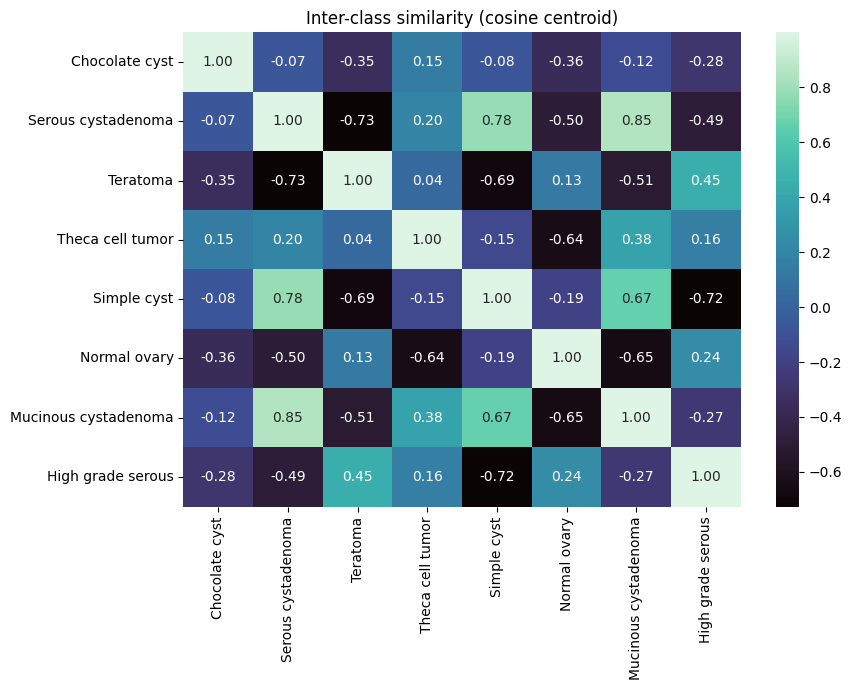

Cosine similarity Chocolate cyst vs Mucinous cystadenoma: -0.121


In [23]:
feature_cols = [
    "brightness_mean", "brightness_std", "rms_contrast", "michelson_contrast",
    "snr_db", "sharpness", "hist_entropy", "dynamic_range",
    "tumor_area_ratio", "aspect_ratio", "circularity", "solidity", "n_lesions",
    "roi_mean", "roi_std", "roi_skewness", "roi_kurtosis", "roi_dynamic_range",
    "glcm_contrast", "glcm_correlation", "glcm_energy", "glcm_homogeneity",
    "lbp_entropy", "lbp_energy", "gabor_energy_mean", "gabor_energy_std",
]
feature_cols = [c for c in feature_cols if c in feat_df.columns]
X = feat_df[feature_cols]
y = feat_df["label"].astype(int)

pipe_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=42)),
])
xy = pipe_pca.fit_transform(X)
pca_df = feat_df[["class_name", "label", "subset"]].copy()
pca_df["pc1"] = xy[:, 0]
pca_df["pc2"] = xy[:, 1]
print("PCA explained variance:", pipe_pca.named_steps["pca"].explained_variance_ratio_.round(3))

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="pc1", y="pc2", hue="class_name", s=28, alpha=0.75, ax=ax)
ax.set_title("Feature overlap trên mặt phẳng PCA")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# centroid cosine similarity
imp = SimpleImputer(strategy="median")
scaler = StandardScaler()
Xz = scaler.fit_transform(imp.fit_transform(X))
centroids = {}
for lab in sorted(y.unique()):
    centroids[lab] = Xz[y.values == lab].mean(axis=0)
labs = list(centroids)
sim = np.zeros((len(labs), len(labs)))
for i, a in enumerate(labs):
    for j, b in enumerate(labs):
        na = np.linalg.norm(centroids[a]) + EPS
        nb = np.linalg.norm(centroids[b]) + EPS
        sim[i, j] = float(np.dot(centroids[a], centroids[b]) / (na * nb))
sim_df = pd.DataFrame(
    sim,
    index=[CLASS_NAMES.get(i, str(i)) for i in labs],
    columns=[CLASS_NAMES.get(i, str(i)) for i in labs],
)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(sim_df, annot=True, fmt=".2f", cmap="mako", ax=ax)
ax.set_title("Inter-class similarity (cosine centroid)")
plt.tight_layout()
plt.show()

if 0 in centroids and 6 in centroids:
    choc = np.array(centroids[0])
    muci = np.array(centroids[6])
    cos = float(np.dot(choc, muci) / ((np.linalg.norm(choc) + EPS) * (np.linalg.norm(muci) + EPS)))
    print(f"Cosine similarity Chocolate cyst vs Mucinous cystadenoma: {cos:.3f}")


### Nhận xét

- PCA 2 chiều giữ ~38.4% phương sai (`0.261 + 0.123`) → các lớp vẫn chồng nhiều.
- Centroid *Chocolate cyst* vs *Mucinous cystadenoma* có cosine ≈ **-0.121** → xét trên cả vector đặc trưng thì hai lớp không gần nhau, nhưng nhìn từng chỉ số riêng lẻ (mục 2.5–2.8) thì vùng giá trị của chúng vẫn chồng lấn nhiều.

→ Đặc trưng thủ công chỉ mô tả được xu hướng chung, chưa tách tốt các lớp minority và các lớp có hình thái gần nhau; nên cần mô hình CNN + transfer learning và đánh giá bằng F1 / confusion matrix chứ không chỉ accuracy.


## 2.10 Phân tích outlier

Ngưỡng dùng IQR (kích thước ảnh) và percentile (chất lượng / annotation):

- Ảnh quá nhỏ / quá lớn (diện tích pixel)
- Ảnh quá tối / quá sáng (mean intensity)
- Contrast cực thấp, sharpness cực thấp
- Annotation: mask rỗng, mask chiếm gần hết ảnh, size mismatch, circularity bất thường


In [24]:
def iqr_flags(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return (series < lo) | (series > hi), lo, hi

feat_df["img_area"] = feat_df["img_h"] * feat_df["img_w"]
size_flag, size_lo, size_hi = iqr_flags(feat_df["img_area"])
feat_df["outlier_size"] = size_flag

p1, p99 = feat_df["brightness_mean"].quantile([0.01, 0.99])
feat_df["outlier_dark"] = feat_df["brightness_mean"] <= p1
feat_df["outlier_bright"] = feat_df["brightness_mean"] >= p99
feat_df["outlier_low_contrast"] = feat_df["rms_contrast"] <= feat_df["rms_contrast"].quantile(0.02)
feat_df["outlier_blur"] = feat_df["sharpness"] <= feat_df["sharpness"].quantile(0.02)

feat_df["ann_empty"] = feat_df["has_mask"] & (feat_df["empty_mask"] | (feat_df["tumor_area_px"] <= 0))
feat_df["ann_too_large"] = feat_df["has_mask"] & (feat_df["tumor_area_ratio"] >= 0.90)
feat_df["ann_too_small"] = feat_df["has_mask"] & (feat_df["tumor_area_ratio"] <= 0.005) & (~feat_df["empty_mask"].fillna(False))
feat_df["ann_size_mismatch"] = feat_df["size_mismatch"].fillna(False).astype(bool)
feat_df["ann_low_circularity"] = feat_df["has_mask"] & (feat_df["circularity"] <= 0.15)

feat_df["outlier_any"] = (
    feat_df["outlier_size"] | feat_df["outlier_dark"] | feat_df["outlier_bright"]
    | feat_df["outlier_low_contrast"] | feat_df["outlier_blur"]
    | feat_df["ann_empty"] | feat_df["ann_too_large"] | feat_df["ann_too_small"]
    | feat_df["ann_size_mismatch"]
)

summary_out = {
    "kích thước bất thường": int(feat_df["outlier_size"].sum()),
    "quá tối": int(feat_df["outlier_dark"].sum()),
    "quá sáng": int(feat_df["outlier_bright"].sum()),
    "contrast thấp": int(feat_df["outlier_low_contrast"].sum()),
    "nét kém (blur)": int(feat_df["outlier_blur"].sum()),
    "mask rỗng": int(feat_df["ann_empty"].sum()),
    "mask quá lớn (>=90%)": int(feat_df["ann_too_large"].sum()),
    "mask quá nhỏ (<=0.5%)": int(feat_df["ann_too_small"].sum()),
    "mask khác size ảnh": int(feat_df["ann_size_mismatch"].sum()),
    "circularity rất thấp": int(feat_df["ann_low_circularity"].sum()),
}
print("Số outlier theo nhóm:")
for k, v in summary_out.items():
    print(f"  {k:28s}: {v}")
print("Tổng ảnh dính ít nhất 1 cờ:", int(feat_df["outlier_any"].sum()), "/", len(feat_df))
print(f"Ngưỡng diện tích IQR: [{size_lo:.0f}, {size_hi:.0f}] px")
print(f"Ngưỡng sáng 1st/99th percentile: [{p1:.1f}, {p99:.1f}]")


Số outlier theo nhóm:
  kích thước bất thường       : 0
  quá tối                     : 15
  quá sáng                    : 15
  contrast thấp               : 30
  nét kém (blur)              : 30
  mask rỗng                   : 0
  mask quá lớn (>=90%)        : 0
  mask quá nhỏ (<=0.5%)       : 1
  mask khác size ảnh          : 0
  circularity rất thấp        : 0
Tổng ảnh dính ít nhất 1 cờ: 71 / 1469
Ngưỡng diện tích IQR: [-114648, 892336] px
Ngưỡng sáng 1st/99th percentile: [22.4, 103.4]


### Nhận xét:
- Tỷ lệ outlier khá thấp -> chấp nhận được trong tập dữ liệu ảnh y tế

**Kết luận:** không cần thiết phải xử lý loại bỏ outlier

Ảnh kích thước bất thường (nhỏ nhất trước): không có mẫu.


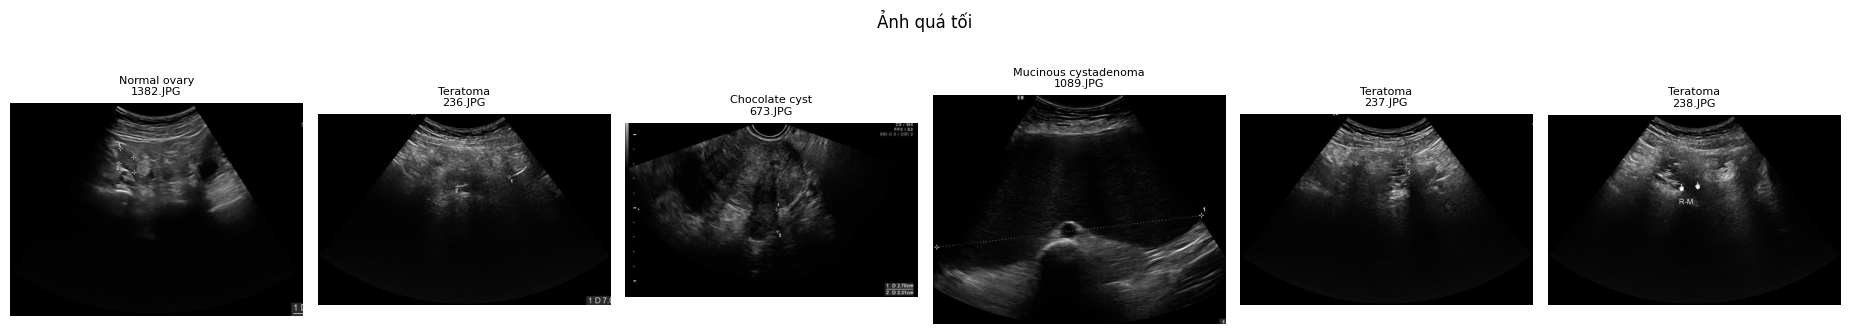

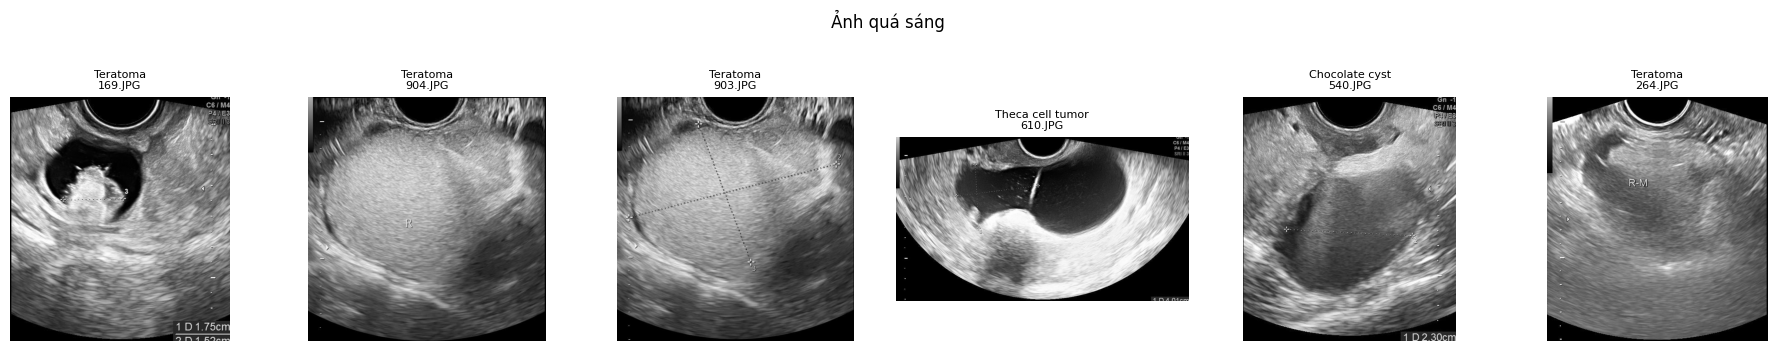

In [25]:
def show_outlier_grid(sub_df, title, overlay_mask=False, n=6):
    sub_df = sub_df.head(n)
    if len(sub_df) == 0:
        print(f"{title}: không có mẫu.")
        return
    fig, axes = plt.subplots(1, len(sub_df), figsize=(3.1 * len(sub_df), 3.3))
    if len(sub_df) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, sub_df.iterrows()):
        img = load_gray(row["image_path"])
        ax.imshow(img, cmap="gray")
        if overlay_mask and row["has_mask"]:
            mask = load_mask(row["mask_path"], shape=img.shape)
            if mask is not None and mask.shape == img.shape:
                ax.imshow(np.ma.masked_where(mask == 0, mask), cmap="autumn", alpha=0.4)
        ax.set_title(f"{row['class_name']}\n{row['image_name']}", fontsize=8)
        ax.axis("off")
    plt.suptitle(title, y=1.05)
    plt.tight_layout()
    plt.show()

show_outlier_grid(feat_df[feat_df["outlier_size"]].sort_values("img_area"), "Ảnh kích thước bất thường (nhỏ nhất trước)")
show_outlier_grid(feat_df[feat_df["outlier_dark"]].sort_values("brightness_mean"), "Ảnh quá tối")
show_outlier_grid(feat_df[feat_df["outlier_bright"]].sort_values("brightness_mean", ascending=False), "Ảnh quá sáng")


## 2.11 Phân tích missing data

Đối chiếu file ảnh với file mask (`{stem}.PNG` hoặc `{stem}_binary.PNG`) trên tập **OTU_2d**.


In [26]:
missing_rows = []
subset_dir = DATA_ROOT / SUBSET_NAME
img_dir = subset_dir / "images"
ann_dir = subset_dir / "annotations"
images = {p.stem: p.name for p in img_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}}
masks = {p.stem.replace("_binary_binary", "").replace("_binary", ""): p.name for p in ann_dir.glob("*.PNG") if "_binary" not in p.stem}
binary_masks = {p.stem.replace("_binary", ""): p.name for p in ann_dir.glob("*_binary.PNG") if "_binary_binary" not in p.stem}

img_stems = set(images)
mask_stems = set(masks) | set(binary_masks)
only_img = sorted(img_stems - mask_stems)
only_mask = sorted(mask_stems - img_stems)
print(f"=== {subset_dir.name} ===")
print(f"  Ảnh: {len(img_stems)} | mask màu: {len(masks)} | mask binary: {len(binary_masks)}")
print(f"  Ảnh không có mask: {len(only_img)}")
print(f"  Mask không có ảnh: {len(only_mask)}")
if only_img[:10]:
    print("  Ví dụ ảnh thiếu mask:", only_img[:10])
if only_mask[:10]:
    print("  Ví dụ mask thiếu ảnh:", only_mask[:10])
for stem in only_img:
    missing_rows.append({"subset": subset_dir.name, "stem": stem, "issue": "missing_mask", "file": images[stem]})
for stem in only_mask:
    missing_rows.append({"subset": subset_dir.name, "stem": stem, "issue": "missing_image", "file": masks.get(stem) or binary_masks.get(stem)})

missing_df = pd.DataFrame(missing_rows)
print("\nTổng issue:", len(missing_df))
if len(missing_df):
    print(missing_df.groupby(["subset", "issue"]).size())
else:
    print("Không phát hiện ảnh thiếu mask hoặc mask mồ côi.")

print("\nTrong dataframe nhãn:")
print("  has_mask = False:", int((~df["has_mask"]).sum()))
print("  empty_mask:", int(feat_df["ann_empty"].sum()) if "ann_empty" in feat_df.columns else "n/a")
print("  size_mismatch:", int(feat_df["ann_size_mismatch"].sum()) if "ann_size_mismatch" in feat_df.columns else "n/a")


=== OTU_2d ===
  Ảnh: 1469 | mask màu: 1469 | mask binary: 1469
  Ảnh không có mask: 0
  Mask không có ảnh: 0

Tổng issue: 0
Không phát hiện ảnh thiếu mask hoặc mask mồ côi.

Trong dataframe nhãn:
  has_mask = False: 0
  empty_mask: 0
  size_mismatch: 0


### Nhận xét:
- Không có dữ liệu bị thiếu

## Tóm tắt đặc trưng đã trích xuất

Từ mỗi ảnh (và mask nếu có), notebook ghi vào `feat_df` các nhóm dưới đây; **2.12** lưu ra `mmotu_feature_summary.csv`.

**1. Định danh mẫu**
- Tên ảnh, nhãn lớp (`label` / `class_name`), subset (`OTU_2d`), split (train/val), đường dẫn ảnh–mask, `has_mask`

**2. Kích thước**
- `img_h`, `img_w`, `n_pixels`
- `mask_resized`: mask có bị lệch kích thước so với ảnh không

**3. Chất lượng ảnh (2.5)** — toàn ảnh xám
- Độ sáng: `brightness_mean`, `brightness_std`
- Tương phản: `rms_contrast`, `michelson_contrast`, `dynamic_range`, `intensity_min` / `intensity_max`
- `hist_entropy`, SNR (`snr`, `snr_db`), độ nét `sharpness`, `skewness`, `kurtosis`
- Sau histogram equalization: `he_rms_contrast`, `he_michelson_contrast`, `he_hist_entropy`, `contrast_gain`

**4. Hình thái annotation (2.6)** — mask nhị phân
- Diện tích tổn thương: `tumor_area_px`, `tumor_area_ratio`
- Hộp bao: `bbox_h`, `bbox_w`, `aspect_ratio`
- Hình dạng: `circularity`, `solidity`, `eccentricity`
- `n_lesions`, `empty_mask`, `size_mismatch`

**5. Cường độ trên ROI (2.7)** — pixel trong mask (toàn ảnh nếu không có mask)
- `roi_mean`, `roi_std`, `roi_skewness`, `roi_kurtosis`, `roi_min`, `roi_max`, `roi_dynamic_range`

**6. Texture (2.8)** — ROI resize 128×128
- **GLCM:** `glcm_contrast`, `glcm_correlation`, `glcm_energy`, `glcm_homogeneity`
- **LBP:** `lbp_entropy`, `lbp_energy` và histogram 11 bin (`lbp_bin_0` … `lbp_bin_10`)
- **Gabor:** `gabor_energy_mean`, `gabor_energy_std` và 8 bộ lọc hướng–tần số (`gabor_e_0` … `gabor_e_7`)


## 2.12 Lưu lại file thành CSV


In [27]:
out_cols = [c for c in [
    "image_name", "label", "class_name", "subset", "split",
    "image_path", "mask_path", "has_mask", "label_name",
] if c in df.columns]
df[out_cols].to_csv(OUTPUT_DIR / "mmotu_dataset_summary.csv", index=False)

drop_eda = [c for c in feat_df.columns if c.startswith("outlier_") or c.startswith("ann_")]
if "img_area" in feat_df.columns:
    drop_eda.append("img_area")
feat_export = feat_df.drop(columns=drop_eda, errors="ignore")
feat_export.to_csv(OUTPUT_DIR / "mmotu_feature_summary.csv", index=False)

if len(missing_df):
    missing_df.to_csv(OUTPUT_DIR / "mmotu_missing_data.csv", index=False)
print("Đã lưu: mmotu_dataset_summary.csv")
print("Đã lưu: mmotu_feature_summary.csv")
print("Số cột đặc trưng:", feat_export.shape[1])
print(df[out_cols].head())


Đã lưu: mmotu_dataset_summary.csv
Đã lưu: mmotu_feature_summary.csv
Số cột đặc trưng: 76
  image_name  label          class_name  subset  split  \
0    658.JPG      5        Normal ovary  OTU_2d  train   
1    384.JPG      3    Theca cell tumor  OTU_2d  train   
2    367.JPG      3    Theca cell tumor  OTU_2d  train   
3    730.JPG      1  Serous cystadenoma  OTU_2d  train   
4   1426.JPG      7   High grade serous  OTU_2d  train   

                                          image_path  \
0  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...   
1  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...   
2  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...   
3  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...   
4  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...   

                                           mask_path  has_mask  \
0  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...      True   
1  /content/drive/MyDrive/TL_OvarianTumor_Ultraso...      True   
2  /content/drive/MyDrive/T

# 3. Tiền xử lý dữ liệu

Chuẩn bị dữ liệu cho mô hình.

- 3.1 Tách tập
- 3.2 Làm sạch
- 3.3 Chuẩn hóa ảnh 384×384
- 3.4 Cân bằng lớp và augment (minh họa skimage)
- 3.5 Cache `.npy` để mục 5 train trên Colab không gọi lại CLAHE


## 3.1 Tách tập dataset

- Split gốc `train` / `val` theo `*_cls.txt` được **giữ** ở cột `split_official` để so sánh.
- Chia lại **toàn bộ** mẫu thành train / validation / test bằng `sklearn.model_selection.train_test_split` (hai bước: tách test trước, rồi tách val từ phần còn lại).
- Ba tỷ lệ: **8:1:1**, **7:1.5:1.5**, **6:2:2**.
- Stratified theo `label` (giữ tỷ lệ lớp khi dữ liệu lệch); nếu một lớp có ít hơn 2 mẫu thì cảnh báo và chia ngẫu nhiên.
- Chỉ tách trên **OTU_2d** (tập dùng để huấn luyện).
- `random_state=42` để tái lập. Ba cột gán tập: `split_8_1_1`, `split_7_1.5_1.5`, `split_6_2_2`.
- Lưu dataset đã tách vào file mmotu_splits.csv


OK 8:1:1: không trùng mẫu, tổng = 1469
OK 7:1.5:1.5: không trùng mẫu, tổng = 1469
OK 6:2:2: không trùng mẫu, tổng = 1469

===== 8:1:1 =====
Số mẫu:
split_8_1_1  train  val  test
subset                       
OTU_2d        1175  147   147
Tỷ lệ:
split_8_1_1  train  val  test
subset                       
OTU_2d         0.8  0.1   0.1
Theo lớp:
label                 0    1    2   3   4    5   6   7
subset split_8_1_1                                    
OTU_2d test          34   22   34   9   6   27  10   5
       train        268  175  269  70  53  213  84  43
       val           34   22   33   9   7   27  10   5

===== 7:1.5:1.5 =====
Số mẫu:
split_7_1.5_1.5  train  val  test
subset                           
OTU_2d            1027  221   221
Tỷ lệ:
split_7_1.5_1.5  train   val  test
subset                            
OTU_2d           0.699  0.15  0.15
Theo lớp:
label                     0    1    2   3   4    5   6   7
subset split_7_1.5_1.5                                    
OTU_2d 

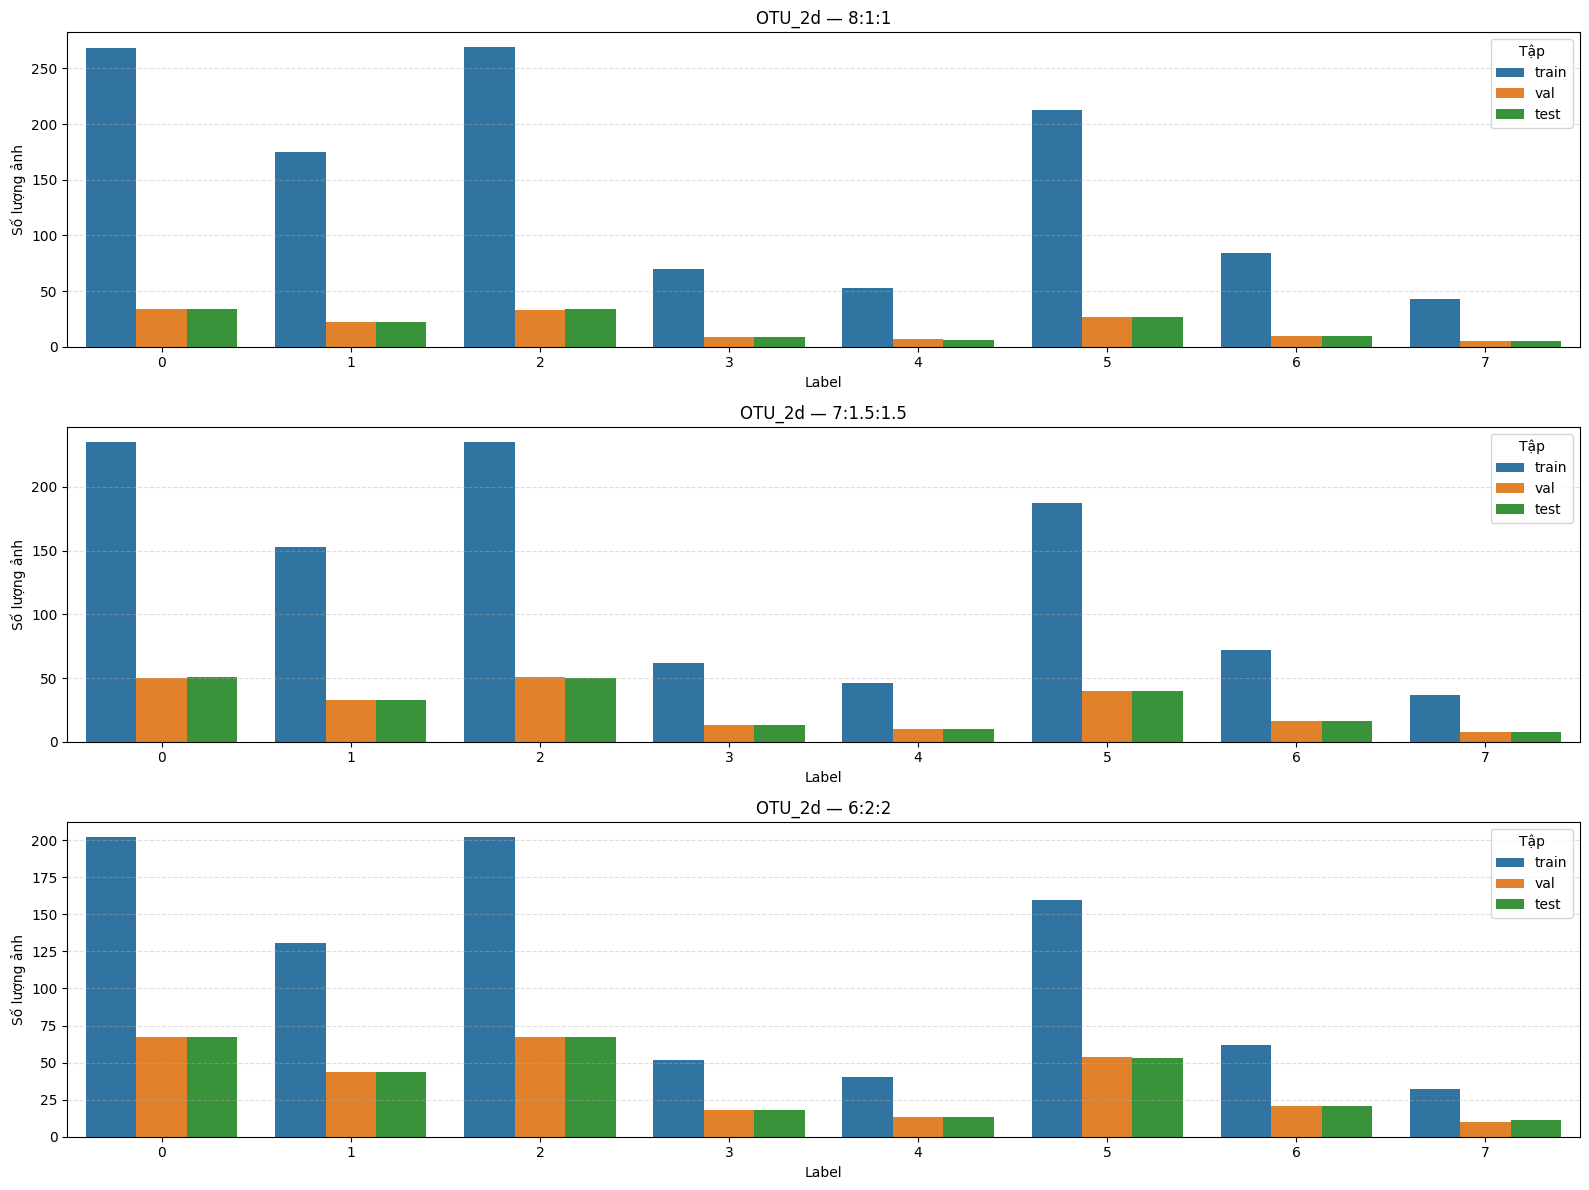

Đã lưu: /content/drive/MyDrive/TL_OvarianTumor_Ultrasound/outputs/mmotu_splits.csv
  image_name  label  subset split_official split_8_1_1 split_7_1.5_1.5  \
0    658.JPG      5  OTU_2d          train       train           train   
1    384.JPG      3  OTU_2d          train       train           train   
2    367.JPG      3  OTU_2d          train       train           train   
3    730.JPG      1  OTU_2d          train       train           train   
4   1426.JPG      7  OTU_2d          train       train           train   

  split_6_2_2  
0       train  
1       train  
2       train  
3       train  
4       train  


In [28]:
from sklearn.model_selection import train_test_split

SPLIT_SCHEMES = {
    "8:1:1": (0.8, 0.1, 0.1),
    "7:1.5:1.5": (0.7, 0.15, 0.15),
    "6:2:2": (0.6, 0.2, 0.2),
}
SCHEME_COLS = {
    "8:1:1": "split_8_1_1",
    "7:1.5:1.5": "split_7_1.5_1.5",
    "6:2:2": "split_6_2_2",
}
RANDOM_STATE = 42


def _stratify_or_none(labels, context):
    counts = labels.value_counts()
    if counts.min() >= 2:
        return labels
    print(
        f"Cảnh báo: {context} — lớp ít nhất chỉ có {int(counts.min())} mẫu. "
        "Không stratify, chia ngẫu nhiên."
    )
    return None


def assign_three_way_split(df_part, train_r, val_r, test_r, random_state=RANDOM_STATE):
    idx = df_part.index.to_numpy()
    y = df_part["label"]
    subset_name = df_part["subset"].iloc[0] if "subset" in df_part.columns else ""

    idx_tv, idx_test = train_test_split(
        idx,
        test_size=test_r,
        stratify=_stratify_or_none(y, f"{subset_name} bước tách test"),
        random_state=random_state,
    )
    y_tv = y.loc[idx_tv]
    idx_train, idx_val = train_test_split(
        idx_tv,
        test_size=val_r / (train_r + val_r),
        stratify=_stratify_or_none(y_tv, f"{subset_name} bước tách val"),
        random_state=random_state,
    )

    out = pd.Series("train", index=df_part.index, dtype="object")
    out.loc[idx_val] = "val"
    out.loc[idx_test] = "test"
    return out


def load_mmotu_dataframe():
    summary_path = OUTPUT_DIR / "mmotu_dataset_summary.csv"
    if summary_path.exists():
        loaded = pd.read_csv(summary_path)
        loaded = loaded[loaded["subset"] == "OTU_2d"].reset_index(drop=True)
        print(f"Đã đọc {len(loaded)} mẫu OTU_2d từ {summary_path}")
        return loaded

    data_root = DATA_ROOT
    subset = data_root / "OTU_2d"
    img_dir = subset / "images"
    rows = []
    for split_name in ["train", "val"]:
        label_file = subset / f"{split_name}_cls.txt"
        if not label_file.exists():
            continue
        with open(label_file, "r", encoding="utf-8") as fh:
            for line in fh:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                if len(parts) < 2:
                    continue
                rows.append({
                    "image_name": parts[0],
                    "label": int(parts[1]),
                    "subset": "OTU_2d",
                    "split": split_name,
                    "image_path": str(img_dir / parts[0]),
                })
    loaded = pd.DataFrame(rows)
    print(f"Đã dựng {len(loaded)} mẫu OTU_2d từ {data_root}")
    return loaded


if "df" not in globals() or not isinstance(df, pd.DataFrame):
    df = load_mmotu_dataframe()

if "subset" in df.columns:
    df = df[df["subset"] == "OTU_2d"].reset_index(drop=True)

if "split" in df.columns and "split_official" not in df.columns:
    df = df.rename(columns={"split": "split_official"})

for scheme_name, (train_r, val_r, test_r) in SPLIT_SCHEMES.items():
    col = SCHEME_COLS[scheme_name]
    assigned = []
    for subset_name, group in df.groupby("subset", sort=True):
        assigned.append(assign_three_way_split(group, train_r, val_r, test_r))
    df[col] = pd.concat(assigned).reindex(df.index)

    for subset_name, group in df.groupby("subset"):
        sets = {s: set(group.index[group[col] == s]) for s in ["train", "val", "test"]}
        assert sets["train"].isdisjoint(sets["val"]), f"trùng train/val: {subset_name} {col}"
        assert sets["train"].isdisjoint(sets["test"]), f"trùng train/test: {subset_name} {col}"
        assert sets["val"].isdisjoint(sets["test"]), f"trùng val/test: {subset_name} {col}"
        assert sum(len(v) for v in sets.values()) == len(group), f"thiếu mẫu: {subset_name} {col}"
    print(f"OK {scheme_name}: không trùng mẫu, tổng = {len(df)}")

for scheme_name, col in SCHEME_COLS.items():
    print(f"\n===== {scheme_name} =====")
    counts = df.groupby(["subset", col]).size().unstack(fill_value=0)
    counts = counts.reindex(columns=["train", "val", "test"])
    print("Số mẫu:")
    print(counts)
    print("Tỷ lệ:")
    print((counts.T / counts.sum(axis=1)).T.round(3))
    print("Theo lớp:")
    print(df.groupby(["subset", col, "label"]).size().unstack(fill_value=0))

subsets = sorted(df["subset"].unique())
n_rows, n_cols = len(SCHEME_COLS), len(subsets)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12), sharey=False)
if n_rows == 1:
    axes = [axes]
if n_cols == 1:
    axes = [[ax] for ax in axes]

for i, (scheme_name, col) in enumerate(SCHEME_COLS.items()):
    for j, subset_name in enumerate(subsets):
        ax = axes[i][j]
        sub = df[df["subset"] == subset_name]
        sns.countplot(
            data=sub,
            x="label",
            hue=col,
            hue_order=["train", "val", "test"],
            ax=ax,
        )
        ax.set_title(f"{subset_name} — {scheme_name}")
        ax.set_xlabel("Label")
        ax.set_ylabel("Số lượng ảnh")
        ax.legend(title="Tập")
        ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

split_cols = [
    "image_name",
    "label",
    "subset",
    "split_official",
    "split_8_1_1",
    "split_7_1.5_1.5",
    "split_6_2_2",
]
split_path = OUTPUT_DIR / "mmotu_splits.csv"
df[split_cols].to_csv(split_path, index=False, encoding="utf-8-sig")
print("Đã lưu:", split_path)
print(df[split_cols].head())


## 3.2 Làm sạch

Đối chiếu file ảnh với mask và nhãn. Chỉ loại mẫu **lỗi cứng**. Outlier độ sáng/tương phản được báo cáo nhưng **không drop** (Mục 2.10).


In [29]:
def _resolve_mask(image_path: str):
    img_path = Path(image_path)
    ann_dir = img_path.parent.parent / "annotations"
    stem = img_path.stem
    binary_mask = ann_dir / f"{stem}_binary.PNG"
    color_mask = ann_dir / f"{stem}.PNG"
    if binary_mask.exists():
        return str(binary_mask)
    if color_mask.exists():
        return str(color_mask)
    return None


def ensure_image_mask_paths(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    if "image_path" not in out.columns:
        out["image_path"] = out.apply(
            lambda r: str(DATA_ROOT / r["subset"] / "images" / r["image_name"]),
            axis=1,
        )
    if "mask_path" not in out.columns:
        out["mask_path"] = out["image_path"].map(_resolve_mask)
    else:
        missing = out["mask_path"].isna() | (out["mask_path"].astype(str) == "None")
        if missing.any():
            out.loc[missing, "mask_path"] = out.loc[missing, "image_path"].map(_resolve_mask)
    return out


def inspect_sample(row) -> list[str]:
    reasons = []
    img_path = Path(str(row["image_path"]))
    if not img_path.exists():
        return ["missing_image"]
    try:
        with Image.open(img_path) as im:
            img_hw = (im.height, im.width)
    except Exception:
        return ["unreadable_image"]

    mask_path = row.get("mask_path")
    if mask_path is None or (isinstance(mask_path, float) and np.isnan(mask_path)) or str(mask_path) in ("", "None"):
        return ["missing_mask"]
    mask_path = Path(str(mask_path))
    if not mask_path.exists():
        return ["missing_mask"]
    try:
        with Image.open(mask_path) as im:
            mask = np.array(im)
    except Exception:
        return ["unreadable_mask"]

    if mask.ndim == 3:
        mask_bin = mask.max(axis=2) > 0
    else:
        mask_bin = mask > 0
    if int(mask_bin.sum()) == 0:
        reasons.append("empty_mask")
    mh, mw = mask_bin.shape[:2]
    if (mh, mw) != img_hw:
        reasons.append("size_mismatch")
    return reasons


df = ensure_image_mask_paths(df)
df = df.drop(columns=[c for c in ["keep", "drop_reason"] if c in df.columns], errors="ignore")
inspect_rows = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Đối chiếu ảnh-mask"):
    reasons = inspect_sample(row)
    inspect_rows.append({
        "image_name": row["image_name"],
        "subset": row["subset"],
        "keep": len(reasons) == 0,
        "drop_reason": ";".join(reasons) if reasons else "",
    })

inspect_df = pd.DataFrame(inspect_rows)
df = df.merge(inspect_df[["image_name", "subset", "keep", "drop_reason"]], on=["image_name", "subset"], how="left")
n_drop = int((~df["keep"]).sum())
print(f"Tổng mẫu: {len(df)}")
print(f"Giữ: {int(df['keep'].sum())}")
print(f"Loại (lỗi cứng): {n_drop}")
if n_drop:
    print(df.loc[~df["keep"], ["image_name", "subset", "drop_reason"]].value_counts("drop_reason"))
else:
    print("Không có mẫu lỗi cứng (ảnh hỏng / mask rỗng / lệch size / thiếu file).")

df_clean = df[df["keep"]].copy()
print("df_clean:", len(df_clean), "mẫu")

# Báo cáo outlier chất lượng — KHÔNG drop
feat_src = None
if "feat_df" in globals() and isinstance(feat_df, pd.DataFrame):
    feat_src = feat_df
elif OUTPUT_DIR / "mmotu_feature_summary.csv".exists():
    feat_src = pd.read_csv("mmotu_feature_summary.csv")
    print("Đã đọc mmotu_feature_summary.csv để thống kê outlier chất lượng.")

if feat_src is not None and {"brightness_mean", "rms_contrast"}.issubset(feat_src.columns):
    q = feat_src.copy()
    if "outlier_dark" not in q.columns:
        q["outlier_dark"] = q["brightness_mean"] <= q["brightness_mean"].quantile(0.01)
        q["outlier_bright"] = q["brightness_mean"] >= q["brightness_mean"].quantile(0.99)
        q["outlier_low_contrast"] = q["rms_contrast"] <= q["rms_contrast"].quantile(0.02)
    flags = {
        "quá tối": int(q["outlier_dark"].sum()),
        "quá sáng": int(q["outlier_bright"].sum()),
        "contrast thấp": int(q["outlier_low_contrast"].sum()),
    }
    print("\nOutlier chất lượng (GIỮ, không loại):")
    for k, v in flags.items():
        print(f"  {k}: {v}")
else:
    print("Không có feat_df / CSV chất lượng — bỏ qua thống kê outlier sáng/tối.")


Đối chiếu ảnh-mask:   0%|          | 0/1469 [00:00<?, ?it/s]

Tổng mẫu: 1469
Giữ: 1469
Loại (lỗi cứng): 0
Không có mẫu lỗi cứng (ảnh hỏng / mask rỗng / lệch size / thiếu file).
df_clean: 1469 mẫu

Outlier chất lượng (GIỮ, không loại):
  quá tối: 15
  quá sáng: 15
  contrast thấp: 30


### Nhận xét:
- Như nhận xét mục 2.10 Outlier quá thấp nên không cần loại
- Không có ảnh lỗi

## 3.3 Chuẩn hóa ảnh

Pad vuông rồi resize 384×384, CLAHE, min-max `[0, 1]`. Mask đi qua cùng phép biến đổi (nội suy nearest, giữ nhị phân) nhưng chỉ để minh họa và đối chiếu EDA, không dùng làm đầu vào hay nhãn khi huấn luyện. Mục 3.5 cache toàn bộ ảnh đã xử lý ra `cache/` để mục 5 không gọi lại CLAHE mỗi epoch.


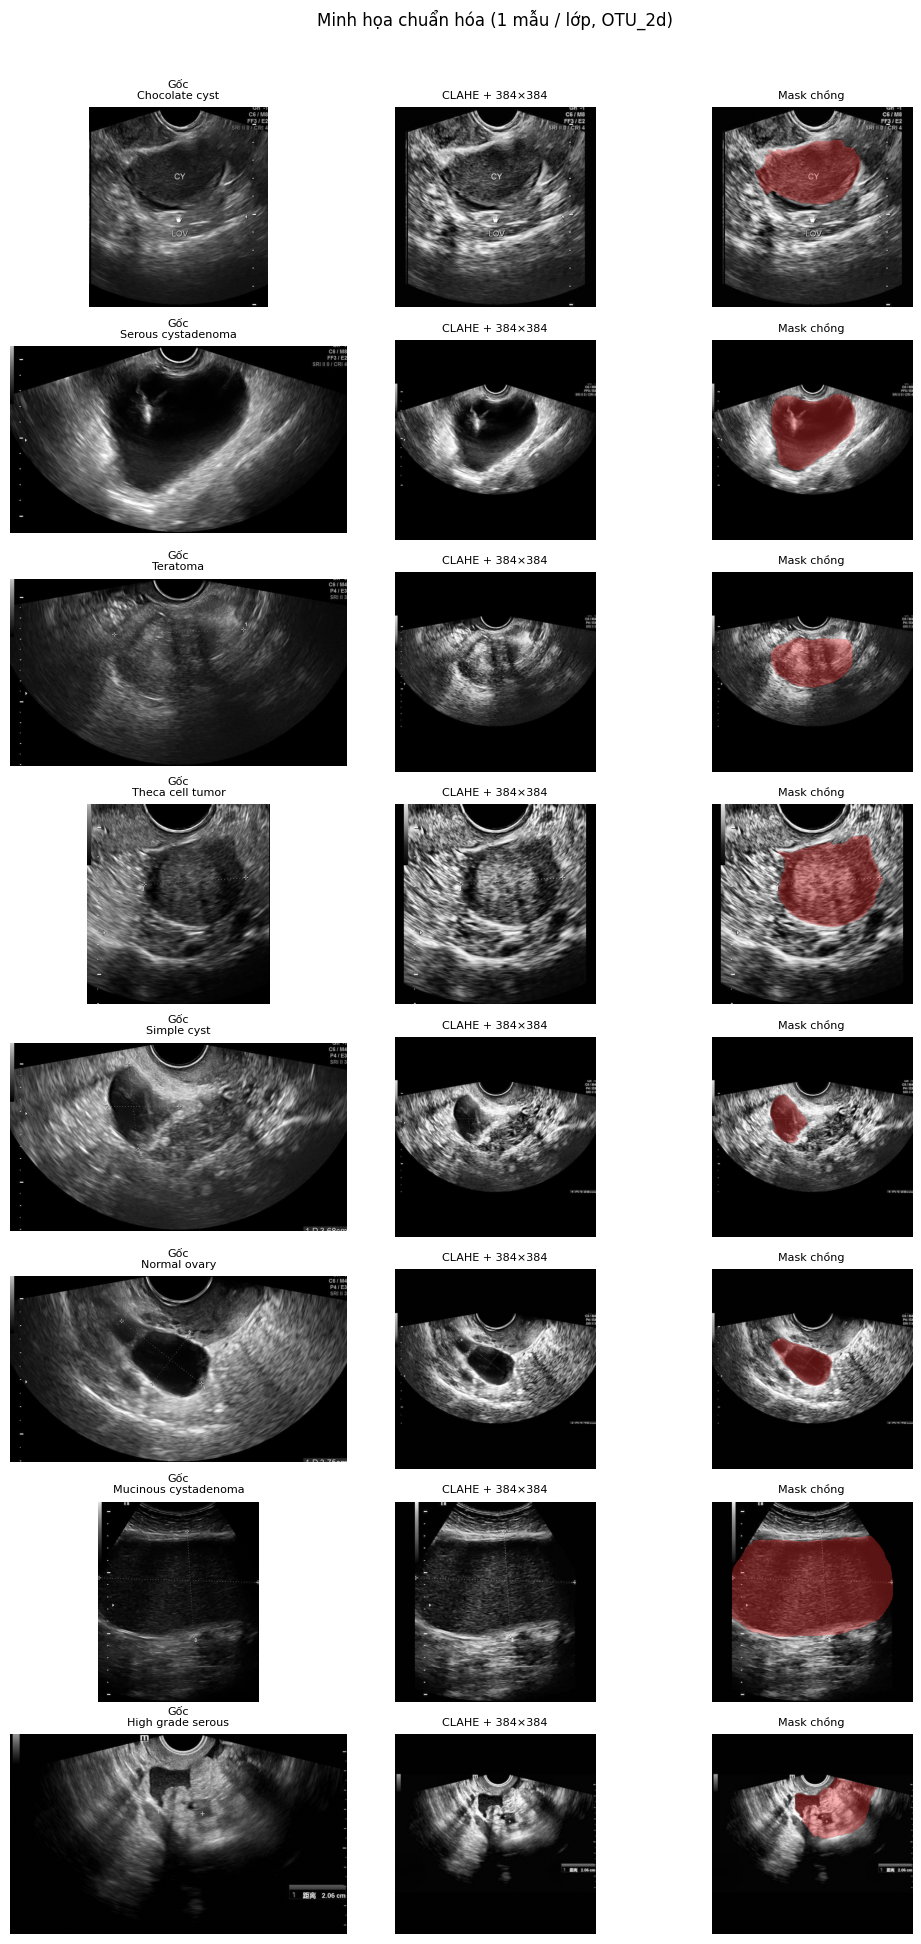

Hàm sẵn sàng: pad_to_square, preprocess_image, preprocess_mask, preprocess_image_roi (IMG_SIZE = 384 , ROI_MARGIN = 2.0 )


In [30]:
from skimage.exposure import equalize_adapthist
from skimage.transform import resize as sk_resize
from skimage.measure import label as sk_label, regionprops

IMG_SIZE = 384
ROI_MARGIN = 2.0        # cạnh cửa sổ crop = ROI_MARGIN × cạnh lền nhất của bbox tổn thương
ROI_MIN_AREA_RATIO = 0.005   # ngưỡng ann_too_small ở mục 2.10
ROI_MAX_AREA_RATIO = 0.90    # ngưỡng ann_too_large ở mục 2.10
ROI_MIN_LESION_PX = 30       # cùng ngưỡng n_lesions ở mục 2.6


def pad_to_square(arr: np.ndarray, fill=0) -> np.ndarray:
    h, w = arr.shape[:2]
    side = max(h, w)
    pad_y, pad_x = side - h, side - w
    top, left = pad_y // 2, pad_x // 2
    bottom, right = pad_y - top, pad_x - left
    if arr.ndim == 2:
        pad_width = ((top, bottom), (left, right))
    else:
        pad_width = ((top, bottom), (left, right)) + tuple((0, 0) for _ in range(arr.ndim - 2))
    return np.pad(arr, pad_width, mode="constant", constant_values=fill)


def _finalize_gray(arr: np.ndarray, size=IMG_SIZE) -> np.ndarray:
    """resize → [0,1] → CLAHE → min-max. Dùng chung cho ảnh nguyên và crop ROI."""
    out = sk_resize(arr, (size, size), order=1, anti_aliasing=True, preserve_range=True).astype(np.float32)
    out = np.clip(out / 255.0, 0.0, 1.0)
    out = equalize_adapthist(out, clip_limit=0.01)
    mn, mx = float(out.min()), float(out.max())
    if mx > mn:
        out = (out - mn) / (mx - mn)
    return out.astype(np.float32)


def preprocess_image(path, size=IMG_SIZE):
    with Image.open(path) as im:
        img = np.array(im.convert("L"), dtype=np.float32)
    orig_hw = img.shape[:2]
    return _finalize_gray(pad_to_square(img, fill=0), size), orig_hw


def preprocess_mask(path, orig_hw=None, size=IMG_SIZE):
    with Image.open(path) as im:
        mask = np.array(im)
    if mask.ndim == 3:
        mask = mask.max(axis=2)
    mask = mask.astype(np.float32)
    if orig_hw is not None and tuple(mask.shape[:2]) != tuple(orig_hw):
        mask = sk_resize(mask, orig_hw, order=0, anti_aliasing=False, preserve_range=True)
    mask = pad_to_square(mask, fill=0)
    mask = sk_resize(mask, (size, size), order=0, anti_aliasing=False, preserve_range=True)
    return (mask > 0).astype(np.uint8)


def load_mask_binary(mask_path, target_hw):
    """Mask nhị phân ở độ phân giải ảnh gốc (chưa pad/resize). None nếu không đọc được."""
    if mask_path is None or str(mask_path) in ("", "None", "nan"):
        return None
    mp = Path(str(mask_path))
    if not mp.exists():
        return None
    with Image.open(mp) as im:
        m = np.array(im)
    if m.ndim == 3:
        m = m.max(axis=2)
    if tuple(m.shape[:2]) != tuple(target_hw):
        m = sk_resize(m, target_hw, order=0, anti_aliasing=False, preserve_range=True)
    return (m > 0).astype(np.uint8)


def roi_bbox_from_mask(mask_bin: np.ndarray):
    """Bbox hợp của mọi tổn thương >= ROI_MIN_LESION_PX.

    Trả về ((minr, minc, maxr, maxc), area_ratio); box=None nếu mask không dùng được
    (rỗng, quá nhỏ, hoặc phủ gần hết ảnh — các cờ ann_* ở mục 2.10).
    """
    area_ratio = float(mask_bin.sum()) / float(mask_bin.size)
    if not (ROI_MIN_AREA_RATIO < area_ratio < ROI_MAX_AREA_RATIO):
        return None, area_ratio
    boxes = [r.bbox for r in regionprops(sk_label(mask_bin > 0)) if r.area >= ROI_MIN_LESION_PX]
    if not boxes:
        return None, area_ratio
    box = (
        min(b[0] for b in boxes),
        min(b[1] for b in boxes),
        max(b[2] for b in boxes),
        max(b[3] for b in boxes),
    )
    return box, area_ratio


def preprocess_image_roi(image_path, mask_path, size=IMG_SIZE, margin=ROI_MARGIN):
    """Crop vuông quanh bbox tổn thương (lề `margin`×) rồi qua đúng chuỗi của preprocess_image.

    Cửa sổ luôn vuông và lấy trên ảnh đã zero-pad, nên không bóp méo tỷ lệ và không
    cắt mất tổn thương khi nó sát biên. Mask lỗi → fallback ảnh nguyên.

    Trả về (img, roi_used, area_ratio).
    """
    with Image.open(image_path) as im:
        img = np.array(im.convert("L"), dtype=np.float32)
    mask_bin = load_mask_binary(mask_path, img.shape[:2])

    box, area_ratio = (None, float("nan"))
    if mask_bin is not None:
        box, area_ratio = roi_bbox_from_mask(mask_bin)
    if box is None:
        return _finalize_gray(pad_to_square(img, fill=0), size), False, area_ratio

    minr, minc, maxr, maxc = box
    side = int(round(margin * max(maxr - minr, maxc - minc)))
    side = max(side, 8)
    half = side // 2
    cy, cx = (minr + maxr) // 2, (minc + maxc) // 2
    padded = np.pad(img, side, mode="constant", constant_values=0)
    r0, c0 = cy + side - half, cx + side - half
    crop = padded[r0:r0 + side, c0:c0 + side]
    return _finalize_gray(crop, size), True, area_ratio


names = CLASS_NAMES if "CLASS_NAMES" in globals() else {i: f"Class {i}" for i in range(8)}
samples = (
    df_clean[df_clean["subset"] == "OTU_2d"]
    .sort_values(["label", "image_name"])
    .groupby("label", group_keys=False)
    .head(1)
)
n = len(samples)
fig, axes = plt.subplots(n, 3, figsize=(10, 2.4 * n))
if n == 1:
    axes = np.array([axes])

for ax_row, (_, row) in zip(axes, samples.iterrows()):
    with Image.open(row["image_path"]) as im:
        orig = np.array(im.convert("L"))
    proc, orig_hw = preprocess_image(row["image_path"])
    mask = None
    if pd.notna(row.get("mask_path")) and Path(str(row["mask_path"])).exists():
        mask = preprocess_mask(row["mask_path"], orig_hw=orig_hw)

    ax_row[0].imshow(orig, cmap="gray")
    ax_row[0].set_title(f"Gốc\n{names.get(int(row['label']), row['label'])}", fontsize=8)
    ax_row[1].imshow(proc, cmap="gray")
    ax_row[1].set_title("CLAHE + 384×384", fontsize=8)
    ax_row[2].imshow(proc, cmap="gray")
    if mask is not None:
        overlay = np.zeros((*mask.shape, 4), dtype=np.float32)
        overlay[mask > 0] = (1.0, 0.2, 0.2, 0.35)
        ax_row[2].imshow(overlay)
    ax_row[2].set_title("Mask chồng", fontsize=8)
    for ax in ax_row:
        ax.axis("off")

plt.suptitle("Minh họa chuẩn hóa (1 mẫu / lớp, OTU_2d)", y=1.01)
plt.tight_layout()
plt.show()
print("Hàm sẵn sàng: pad_to_square, preprocess_image, preprocess_mask, preprocess_image_roi (IMG_SIZE =", IMG_SIZE, ", ROI_MARGIN =", ROI_MARGIN, ")")


## 3.4 Cân bằng lớp và augment

- Class weight trên tập **train** `split_8_1_1` của OTU_2d. Augment nhẹ chỉ áp cho train; val/test dùng `preprocess_image` không augment.
- Augment siêu âm: flip, crop nhẹ, chỉnh sáng/tương phản; tránh biến dạng mạnh làm méo khối u.


Train OTU_2d (split_8_1_1): 1175 mẫu
label
0    268
1    175
2    269
3     70
4     53
5    213
6     84
7     43
Name: count, dtype: int64

class_weight (balanced):
  0 Chocolate cyst: 0.548
  1 Serous cystadenoma: 0.839
  2 Teratoma: 0.546
  3 Theca cell tumor: 2.098
  4 Simple cyst: 2.771
  5 Normal ovary: 0.690
  6 Mucinous cystadenoma: 1.749
  7 High grade serous: 3.416


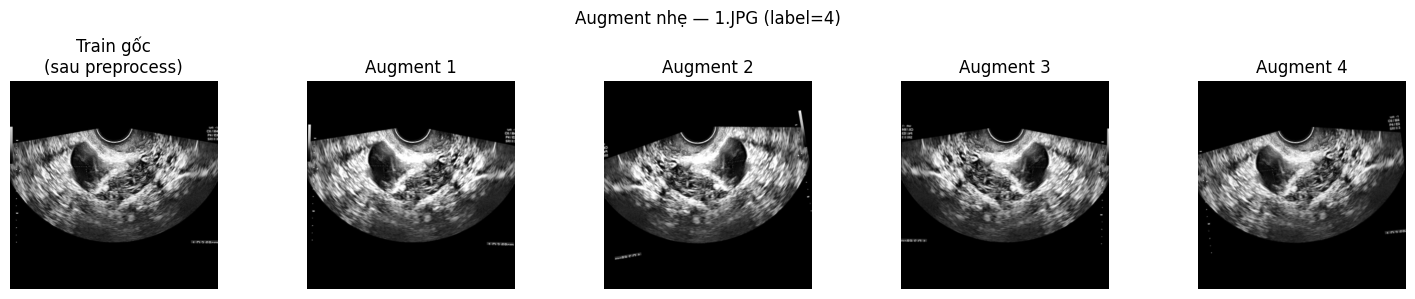

Val/test: gọi preprocess_image, không gọi augment_train.
Sẵn sàng cho mục 4: df_clean, class_weight, preprocess_image, preprocess_mask, augment_train.


In [31]:
from sklearn.utils.class_weight import compute_class_weight
from skimage.transform import rotate as sk_rotate

SPLIT_COL = "split_8_1_1"
train_2d = df_clean[(df_clean["subset"] == "OTU_2d") & (df_clean[SPLIT_COL] == "train")].copy()
print(f"Train OTU_2d ({SPLIT_COL}): {len(train_2d)} mẫu")
print(train_2d["label"].value_counts().sort_index())

classes = np.sort(train_2d["label"].unique())
class_weight_arr = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_2d["label"].to_numpy(),
)
class_weight = {int(c): float(w) for c, w in zip(classes, class_weight_arr)}
print("\nclass_weight (balanced):")
for c, w in class_weight.items():
    name = names.get(c, str(c)) if "names" in globals() else str(c)
    print(f"  {c} {name}: {w:.3f}")


def augment_train(img: np.ndarray, rng=None) -> np.ndarray:
    rng = np.random.default_rng() if rng is None else rng
    out = img.astype(np.float32).copy()
    if rng.random() < 0.5:
        out = np.ascontiguousarray(np.fliplr(out))
    angle = float(rng.uniform(-10.0, 10.0))
    out = sk_rotate(out, angle, resize=False, preserve_range=True, mode="constant", cval=0.0)
    out = np.clip(out * float(rng.uniform(0.9, 1.1)), 0.0, 1.0)
    contrast = float(rng.uniform(0.9, 1.1))
    mean = float(out.mean())
    out = np.clip((out - mean) * contrast + mean, 0.0, 1.0)
    return out.astype(np.float32)


demo_row = train_2d.sort_values("image_name").iloc[0]
demo_img, _ = preprocess_image(demo_row["image_path"])
rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(demo_img, cmap="gray")
axes[0].set_title("Train gốc\n(sau preprocess)")
for i, ax in enumerate(axes[1:], start=1):
    ax.imshow(augment_train(demo_img, rng=rng), cmap="gray")
    ax.set_title(f"Augment {i}")
for ax in axes:
    ax.axis("off")
plt.suptitle(f"Augment nhẹ — {demo_row['image_name']} (label={int(demo_row['label'])})")
plt.tight_layout()
plt.show()

print("Val/test: gọi preprocess_image, không gọi augment_train.")
print("Sẵn sàng cho mục 4: df_clean, class_weight, preprocess_image, preprocess_mask, augment_train.")


### Nhận xét:
- OTU\_2d lệch lớp (3, 4, 6, 7 ít hơn 0, 1, 2, 5): class weight, sampler.
- **Không** flip dọc, elastic, affine mạnh hay crop cắt u → hình dạng khối u không bị biến dạng. Augment 4 cho thấy khối u vẫn cùng 1 dạng, chỉ đổi hướng/sáng tối.
- Chỉ thực hiện cân bằng lớp và agument lên tập train.

**Kết luận:** đã cân bằng bằng class weight và augment siêu âm nhẹ; đã hạn chế biến dạng mạnh làm méo khối u. `class_weight` và `augment_train` sẽ gắn vào Dataset / loss ở mục 4.



## 3.5 Cache ảnh 384×384

CLAHE trong `preprocess_image` chậm nếu gọi lại mỗi epoch. Cell này chạy **một lần** (local hoặc Colab), ghi:

- `cache/otu2d_384_u8.npy` — `uint8`, shape `(N, 384, 384)` (~216 MB)
- `cache/otu2d_index.csv` — nhãn + 3 cột split, **cùng thứ tự** với trục 0 của `.npy`

Mục 3.5b sinh thêm một cache crop ROI theo mask. Mục 5 chọn dùng cache nào qua cờ `USE_ROI_CACHE`.


In [32]:
from tqdm.auto import tqdm

if "CACHE_DIR" not in globals():
    raise RuntimeError("Chạy mục 0 trước (CACHE_DIR / OUTPUT_DIR).")
if "df_clean" not in globals() or "preprocess_image" not in globals():
    raise RuntimeError("Chạy mục 3.1–3.3 trước để có df_clean và preprocess_image.")

CACHE_NPY = CACHE_DIR / "otu2d_384_u8.npy"
CACHE_CSV = CACHE_DIR / "otu2d_index.csv"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

index_df = (
    df_clean[df_clean["subset"] == "OTU_2d"]
    .sort_values("image_name")
    .reset_index(drop=True)
    .copy()
)
need_cols = ["image_name", "label", "class_name", "split_8_1_1", "split_7_1.5_1.5", "split_6_2_2", "image_path"]
missing = [c for c in need_cols if c not in index_df.columns]
if missing:
    raise KeyError(f"df_clean thiếu cột: {missing}")

reuse = False
if CACHE_NPY.exists() and CACHE_CSV.exists():
    cached_index = pd.read_csv(CACHE_CSV)
    if (
        len(cached_index) == len(index_df)
        and list(cached_index["image_name"]) == list(index_df["image_name"])
    ):
        images_u8 = np.load(CACHE_NPY, mmap_mode="r")
        print(f"Đã có cache khớp {CACHE_NPY}  shape={tuple(images_u8.shape)}  dtype={images_u8.dtype}")
        reuse = True

if not reuse:
    print(f"Tạo cache cho {len(index_df)} ảnh → {CACHE_NPY}")
    buf = np.empty((len(index_df), IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    for i, row in tqdm(index_df.iterrows(), total=len(index_df), desc="preprocess"):
        img, _ = preprocess_image(row["image_path"], size=IMG_SIZE)
        buf[i] = np.clip(np.rint(img * 255.0), 0, 255).astype(np.uint8)
    np.save(CACHE_NPY, buf)
    images_u8 = buf

save_cols = ["image_name", "label", "class_name", "split_8_1_1", "split_7_1.5_1.5", "split_6_2_2"]
index_df[save_cols].to_csv(CACHE_CSV, index=False)

images_u8 = np.load(CACHE_NPY)
index_check = pd.read_csv(CACHE_CSV)
assert len(index_check) == images_u8.shape[0] == len(index_df)
assert images_u8.dtype == np.uint8
assert tuple(images_u8.shape[1:]) == (IMG_SIZE, IMG_SIZE)

rng = np.random.default_rng(42)
ri = int(rng.integers(len(index_df)))
direct, _ = preprocess_image(index_df.loc[ri, "image_path"], size=IMG_SIZE)
cached = images_u8[ri].astype(np.float32) / 255.0
max_diff = float(np.max(np.abs(direct - cached)))
print(f"shape={images_u8.shape}  dtype={images_u8.dtype}  size={CACHE_NPY.stat().st_size / 1e6:.1f} MB")
print(f"Đối chiếu mẫu {index_df.loc[ri, 'image_name']}: max |preprocess - cache/255| = {max_diff:.6f} (kỳ vọng < 0.003)")
if max_diff >= 0.003:
    raise AssertionError("Cache lệch preprocess_image — kiểm tra thứ tự image_name.")
print("Cache sẵn sàng cho mục 5.")


Đã có cache khớp /content/drive/MyDrive/TL_OvarianTumor_Ultrasound/cache/otu2d_384_u8.npy  shape=(1469, 384, 384)  dtype=uint8
shape=(1469, 384, 384)  dtype=uint8  size=216.6 MB
Đối chiếu mẫu 1116.JPG: max |preprocess - cache/255| = 0.001961 (kỳ vọng < 0.003)
Cache sẵn sàng cho mục 5.


## 3.5b Cache crop ROI theo mask

Crop một cửa sổ **vuông** quanh bbox tổn thương với lề `ROI_MARGIN` lần cạnh bbox, rồi đi qua đúng chuỗi CLAHE + min-max của mục 3.3. Ghi ra `cache/otu2d_384_roi_u8.npy` và `cache/otu2d_index_roi.csv` — **không ghi đè** cache ảnh nguyên, để còn đối chiếu hai thiết lập.

Lý do dùng lề rộng thay vì crop sát bbox: giữ lại mô xung quanh và một phần thông tin tỷ lệ kích thước. Cửa sổ lấy trên ảnh đã zero-pad nên không bóp méo tỷ lệ và không cắt tổn thương sát biên.

Fallback về ảnh nguyên khi mask không dùng được: diện tích ≤ 0.5% hoặc ≥ 90% (các cờ `ann_too_small` / `ann_too_large` ở mục 2.10), hoặc không còn thành phần liên thông nào ≥ 30 px. Ảnh có nhiều tổn thương (19/1469 theo mục 2.6) dùng **bbox hợp** nên không bỏ sót ổ nào.

**Đánh đổi phải ghi trong báo cáo:** crop dùng mask chuyên gia ở cả test, tức bài toán đổi thành *"cho trước ROI, phân loại 8 lớp"*, không so trực tiếp được với kết quả ảnh nguyên hay baseline MMOTU. Crop cũng làm `tumor_area_ratio` gần như hằng số — đặc trưng mà mục 2.6 cho là phân loại tốt (Mucinous 21.9% vs Normal ovary 4.9%). Cột `tumor_area_ratio` vẫn được lưu trong index để bàn luận.

Tạo cache ROI cho 1469 ảnh (ROI_MARGIN=2.0) → /content/drive/MyDrive/TL_OvarianTumor_Ultrasound/cache/otu2d_384_roi_u8.npy


roi crop:   0%|          | 0/1469 [00:00<?, ?it/s]


shape=(1469, 384, 384)  dtype=uint8  size=216.6 MB
Đối chiếu mẫu 1116.JPG: max |roi - cache/255| = 0.001961 (kỳ vọng < 0.003)

Dùng crop ROI: 1468/1469  |  fallback ảnh nguyên: 1
  mask không đọc được : 0
  diện tích <= 0.005: 1
  diện tích >= 0.90 : 0

tumor_area_ratio theo lớp (đặc trưng bị crop làm phẳng — lưu lại để bàn luận):
                      count   mean  median
class_name                                
Chocolate cyst          336  0.150   0.124
High grade serous        53  0.107   0.090
Mucinous cystadenoma    104  0.219   0.203
Normal ovary            267  0.049   0.037
Serous cystadenoma      219  0.193   0.184
Simple cyst              66  0.165   0.152
Teratoma                336  0.164   0.137
Theca cell tumor         88  0.162   0.151


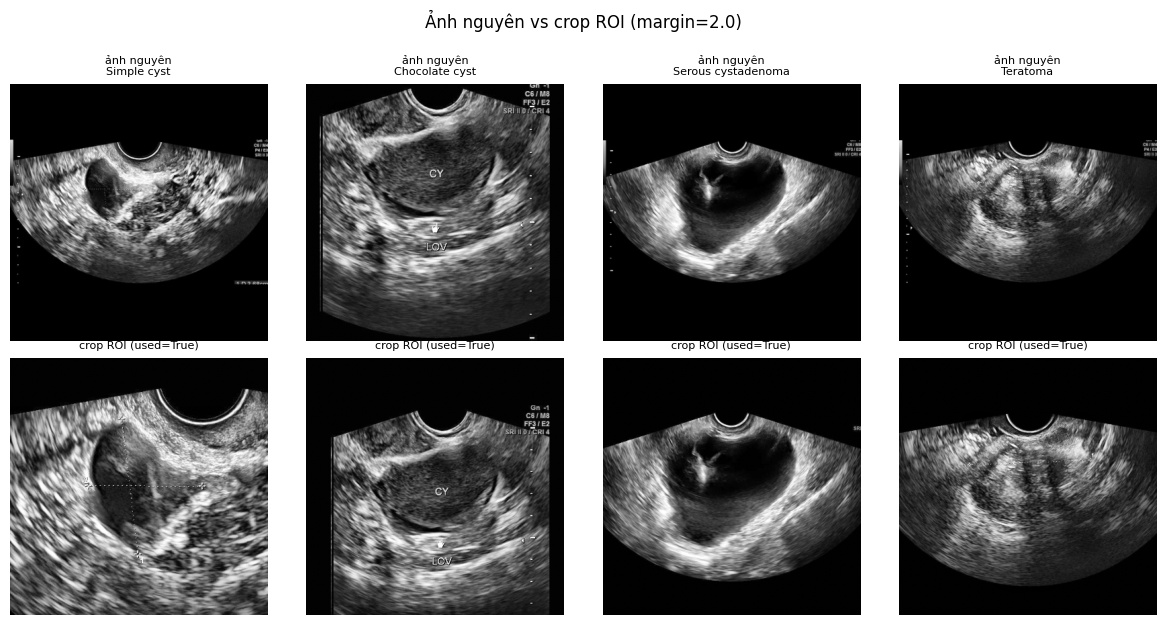

Cache ROI sẵn sàng. Ở mục 5.1 đặt USE_ROI_CACHE = True để dùng.


In [33]:
from tqdm.auto import tqdm

if "preprocess_image_roi" not in globals():
    raise RuntimeError("Chạy mục 3.3 trước để có preprocess_image_roi.")
if "index_df" not in globals():
    raise RuntimeError("Chạy mục 3.5 trước để có index_df.")
if "mask_path" not in index_df.columns:
    raise KeyError("index_df thiếu cột mask_path — chạy lại mục 3.2 và 3.5.")

ROI_CACHE_NPY = CACHE_DIR / "otu2d_384_roi_u8.npy"
ROI_CACHE_CSV = CACHE_DIR / "otu2d_index_roi.csv"

roi_index = index_df.reset_index(drop=True).copy()
print(f"Tạo cache ROI cho {len(roi_index)} ảnh (ROI_MARGIN={ROI_MARGIN}) → {ROI_CACHE_NPY}")

roi_buf = np.empty((len(roi_index), IMG_SIZE, IMG_SIZE), dtype=np.uint8)
roi_used_flags, roi_area_ratios = [], []
for i, row in tqdm(roi_index.iterrows(), total=len(roi_index), desc="roi crop"):
    img, used, ratio = preprocess_image_roi(row["image_path"], row.get("mask_path"), size=IMG_SIZE)
    roi_buf[i] = np.clip(np.rint(img * 255.0), 0, 255).astype(np.uint8)
    roi_used_flags.append(bool(used))
    roi_area_ratios.append(float(ratio))
np.save(ROI_CACHE_NPY, roi_buf)

roi_index["roi_used"] = roi_used_flags
roi_index["tumor_area_ratio"] = roi_area_ratios
roi_save_cols = [
    "image_name", "label", "class_name",
    "split_8_1_1", "split_7_1.5_1.5", "split_6_2_2",
    "roi_used", "tumor_area_ratio",
]
roi_index[roi_save_cols].to_csv(ROI_CACHE_CSV, index=False)

# --- kiểm tra lại cache ---
roi_cached = np.load(ROI_CACHE_NPY)
roi_check = pd.read_csv(ROI_CACHE_CSV)
assert len(roi_check) == roi_cached.shape[0] == len(roi_index)
assert roi_cached.dtype == np.uint8
assert tuple(roi_cached.shape[1:]) == (IMG_SIZE, IMG_SIZE)
assert list(roi_check["image_name"]) == list(roi_index["image_name"])

_rng = np.random.default_rng(42)
_ri = int(_rng.integers(len(roi_index)))
_direct, _, _ = preprocess_image_roi(
    roi_index.loc[_ri, "image_path"], roi_index.loc[_ri, "mask_path"], size=IMG_SIZE
)
_max_diff = float(np.max(np.abs(_direct - roi_cached[_ri].astype(np.float32) / 255.0)))
print(f"\nshape={roi_cached.shape}  dtype={roi_cached.dtype}  size={ROI_CACHE_NPY.stat().st_size / 1e6:.1f} MB")
print(f"Đối chiếu mẫu {roi_index.loc[_ri, 'image_name']}: max |roi - cache/255| = {_max_diff:.6f} (kỳ vọng < 0.003)")
if _max_diff >= 0.003:
    raise AssertionError("Cache ROI lệch preprocess_image_roi — kiểm tra thứ tự image_name.")

# --- thống kê fallback ---
_n_used = int(roi_index["roi_used"].sum())
_ratio = roi_index["tumor_area_ratio"]
print(f"\nDùng crop ROI: {_n_used}/{len(roi_index)}  |  fallback ảnh nguyên: {len(roi_index) - _n_used}")
print(f"  mask không đọc được : {int(_ratio.isna().sum())}")
print(f"  diện tích <= {ROI_MIN_AREA_RATIO:.3f}: {int((_ratio <= ROI_MIN_AREA_RATIO).sum())}")
print(f"  diện tích >= {ROI_MAX_AREA_RATIO:.2f} : {int((_ratio >= ROI_MAX_AREA_RATIO).sum())}")
print("\ntumor_area_ratio theo lớp (đặc trưng bị crop làm phẳng — lưu lại để bàn luận):")
print(roi_index.groupby("class_name")["tumor_area_ratio"].agg(["count", "mean", "median"]).round(3))

# --- đối chiếu trực quan: ảnh nguyên vs crop ROI ---
_show = roi_index.groupby("label", group_keys=False).head(1).head(4)
_fig, _axes = plt.subplots(2, len(_show), figsize=(3 * len(_show), 6.2))
for _col, (_pos, _row) in enumerate(_show.iterrows()):
    _full, _ = preprocess_image(_row["image_path"], size=IMG_SIZE)
    _axes[0, _col].imshow(_full, cmap="gray")
    _axes[0, _col].set_title(f"ảnh nguyên\n{_row['class_name']}", fontsize=8)
    _axes[1, _col].imshow(roi_cached[_pos], cmap="gray")
    _axes[1, _col].set_title(f"crop ROI (used={_row['roi_used']})", fontsize=8)
    for _r in (0, 1):
        _axes[_r, _col].axis("off")
plt.suptitle(f"Ảnh nguyên vs crop ROI (margin={ROI_MARGIN})", y=1.0)
plt.tight_layout()
plt.show()

print("Cache ROI sẵn sàng. Ở mục 5.1 đặt USE_ROI_CACHE = True để dùng.")

# 4. Xây dựng mô hình

## 4.1 Bài toán mô hình

Bài toán là **phân loại đơn nhãn, đa lớp** (single-label multi-class). Mô hình là một hàm tham số hóa:

$$
f_\theta: \mathbb{R}^{384 \times 384} \rightarrow \mathbb{R}^{8}
$$

nhận một ảnh siêu âm xám đã chuẩn hóa ở mục 3.3 và trả về vector logit 8 chiều $\mathbf{z} = (z_0, z_1, \ldots, z_7)$. Xác suất lớp thu được qua softmax:

$$
p_k = \frac{\exp(z_k)}{\sum_{j=0}^{7} \exp(z_j)}
$$

$$
\hat{y} = \arg\max_k p_k
$$

trong đó $\theta$ là toàn bộ tham số mạng, $z_k$ là logit lớp $k$, $p_k$ là xác suất lớp $k$ và $\hat{y}$ là nhãn dự đoán.

Đầu vào: ảnh xám một kênh, kích thước 384×384, giá trị trong $[0,1]$ sau pad vuông, resize, CLAHE và min-max.

Đầu ra: một trong 8 lớp bệnh lý đã liệt kê ở mục 1.

## 4.2 Cơ sở lý thuyết transfer learning

**Định nghĩa.** Một *domain* gồm không gian đặc trưng và phân phối biên $\mathcal{D} = \{\mathcal{X}, P(X)\}$; một *task* gồm không gian nhãn và hàm dự đoán $\mathcal{T} = \{\mathcal{Y}, f(\cdot)\}$. Transfer learning dùng kiến thức từ domain nguồn $\mathcal{D}_s$, task nguồn $\mathcal{T}_s$ để cải thiện học trên domain đích $\mathcal{D}_t$, task đích $\mathcal{T}_t$ khi $\mathcal{D}_s \neq \mathcal{D}_t$ hoặc $\mathcal{T}_s \neq \mathcal{T}_t$ (Pan & Yang, 2010).

| | Nguồn | Đích |
| --- | --- | --- |
| Dữ liệu | ImageNet (~1.28M ảnh RGB) | OTU_2d (1469 ảnh siêu âm xám) |
| Số lớp | 1000 | 8 |
| Đặc điểm | Ảnh màu, tương phản cao | Xám, speckle, biên mờ |

**Vì sao hiệu quả.** CNN học đặc trưng theo tầng: tầng đầu (cạnh, texture) ít phụ thuộc loại ảnh; tầng sâu mang ngữ nghĩa task nguồn. Yosinski et al. (2014): tính chuyển giao giảm theo độ sâu; domain xa ImageNet thì fine-tune tầng sâu thường lợi hơn chỉ thay classifier. Với train ~1175 ảnh (8:1:1), train from scratch trên ResNet50 (~23.5M tham số) dễ overfit; khởi tạo ImageNet giảm epoch và phương sai.

**Ba chiến lược**

| Chiến lược | Cách làm | Phù hợp khi |
| --- | --- | --- |
| Feature extraction | Đóng băng backbone, chỉ train head | Dữ liệu đích rất ít, gần ImageNet |
| Fine-tune một phần | Đóng băng tầng đầu, train tầng sâu + head | Ít–vừa mẫu, domain khác |
| Fine-tune toàn bộ | Cập nhật mọi tham số, lr nhỏ | Rất nhiều ảnh đích |

Nếu $\theta = \theta_{\text{freeze}} \cup \theta_{\text{train}}$:

$$
\theta_{\text{train}} \leftarrow \theta_{\text{train}} - \eta \nabla_{\theta_{\text{train}}} \mathcal{L}, \qquad \theta_{\text{freeze}} = \text{const}
$$

**Chiến lược chọn:** fine-tune một phần + fine-tune toàn bộ trên tập nhỏ

## 4.3 Kiến trúc mô hình

Nhóm dùng **ResNet50** (pretrained ImageNet V2) làm backbone, thay lớp phân loại cuối thành 8 lớp OTU_2d.

**Luồng tổng quát (đầu vào ảnh 384×384, 3 kênh sau nhân bản xám):**

```text
Input (3×384×384)
  → conv1 + bn + relu + maxpool
  → layer1 (256 ch, 96×96)
  → layer2 (512 ch, 48×48)
  → layer3 (1024 ch, 24×24)
  → layer4 (2048 ch, 12×12)
  → global average pool → vector 2048
  → Dropout(0.4) → Linear(2048 → 8) → logit 8 lớp
```

### 4.3.1 Cấu hình ResNet50 (ảnh 384×384)

| Tầng | Cấu hình | Kích thước đầu ra | Số tham số |
| --- | --- | --- | --- |
| Đầu vào | 3 kênh | 3 × 384 × 384 | 0 |
| `conv1` | 7×7, 64, stride 2 | 64 × 192 × 192 | 9,408 |
| `bn1` + ReLU | | 64 × 192 × 192 | 128 |
| `maxpool` | 3×3, stride 2 | 64 × 96 × 96 | 0 |
| `layer1` | 3 bottleneck, 256 ch | 256 × 96 × 96 | 215,808 |
| `layer2` | 4 bottleneck, 512 ch | 512 × 48 × 48 | 1,219,584 |
| `layer3` | 6 bottleneck, 1024 ch | 1024 × 24 × 24 | 7,098,368 |
| `layer4` | 3 bottleneck, 2048 ch | 2048 × 12 × 12 | 14,964,736 |
| `avgpool` | global average pooling | 2048 | 0 |
| `fc` (thay thế lớp này cho phù hợp bài toán) | Dropout 0.4 + Linear(2048→8) | 8 | 16,392 |
| **Tổng** | | | **23,524,424** |

Feature map 12×12 (thay vì 7×7 ở 224×224) giữ chi tiết mịn hơn trên siêu âm. `layer3` + `layer4` chiếm ~93.8% tham số.

### 4.3.2 Điều chỉnh cho OTU_2d

- **Ảnh xám → 3 kênh** giống nhau (giữ weight ImageNet).
- **Chuẩn hóa** mean `[0.485, 0.456, 0.406]`, std `[0.229, 0.224, 0.225]` sau bước `[0,1]` ở mục 3.3.
- **Head:** `Dropout(0.4)` + `Linear(2048, 8)` thay `fc` gốc 1000 lớp.
- **Weight:** `ResNet50_Weights.IMAGENET1K_V2`.

- Cell **sơ đồ khối** (matplotlib): luồng backbone + head — hình vẽ cho báo cáo.
- Cell **`torchsummary`**: bảng text từng lớp (shape, tham số)
- Hai cell sau: thống kê tham số theo stage và kích thước tensor.


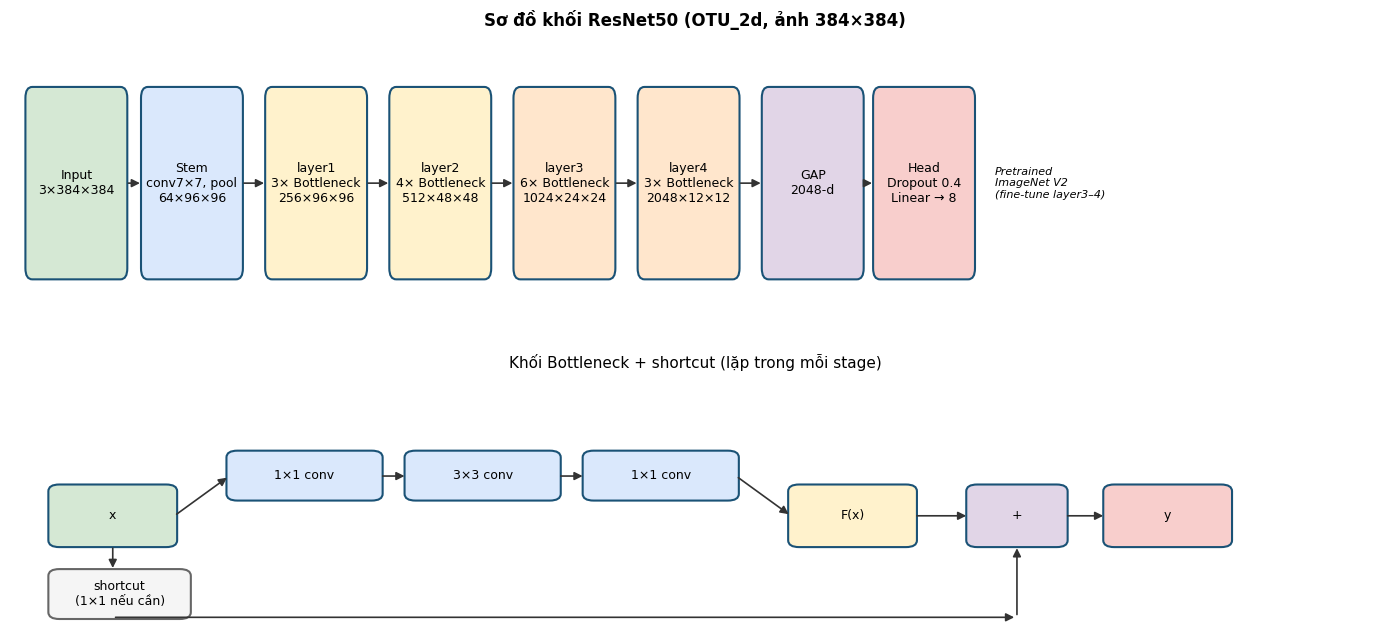

In [34]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch


def _box(ax, xy, w, h, text, fc="#E8F4FD", ec="#1a5276"):
    x, y = xy
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.08",
        linewidth=1.5, edgecolor=ec, facecolor=fc,
    )
    ax.add_patch(patch)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=9)


def _arrow(ax, x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle="-|>", mutation_scale=12, linewidth=1.2, color="#333",
        )
    )


fig, axes = plt.subplots(2, 1, figsize=(14, 6.5), gridspec_kw={"height_ratios": [1.2, 1]})

ax = axes[0]
ax.set_xlim(0, 16)
ax.set_ylim(0, 2.2)
ax.axis("off")
ax.set_title("Sơ đồ khối ResNet50 (OTU_2d, ảnh 384×384)", fontsize=12, fontweight="bold")

blocks = [
    (0.2, "Input\n3×384×384", "#D5E8D4"),
    (1.55, "Stem\nconv7×7, pool\n64×96×96", "#DAE8FC"),
    (3.0, "layer1\n3× Bottleneck\n256×96×96", "#FFF2CC"),
    (4.45, "layer2\n4× Bottleneck\n512×48×48", "#FFF2CC"),
    (5.9, "layer3\n6× Bottleneck\n1024×24×24", "#FFE6CC"),
    (7.35, "layer4\n3× Bottleneck\n2048×12×12", "#FFE6CC"),
    (8.8, "GAP\n2048-d", "#E1D5E7"),
    (10.1, "Head\nDropout 0.4\nLinear → 8", "#F8CECC"),
]
w, h = 1.15, 1.35
y0 = 0.45
for x, label, color in blocks:
    _box(ax, (x, y0), w, h, label, fc=color)
for i in range(len(blocks) - 1):
    _arrow(ax, blocks[i][0] + w, y0 + h / 2, blocks[i + 1][0], y0 + h / 2)
ax.text(11.5, y0 + h / 2, "Pretrained\nImageNet V2\n(fine-tune layer3–4)", fontsize=8, va="center", style="italic")

ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 3)
ax2.axis("off")
ax2.set_title("Khối Bottleneck + shortcut (lặp trong mỗi stage)", fontsize=11)
_box(ax2, (0.3, 1.0), 0.9, 0.7, "x", fc="#D5E8D4")
_box(ax2, (1.6, 1.55), 1.1, 0.55, "1×1 conv", fc="#DAE8FC")
_box(ax2, (2.9, 1.55), 1.1, 0.55, "3×3 conv", fc="#DAE8FC")
_box(ax2, (4.2, 1.55), 1.1, 0.55, "1×1 conv", fc="#DAE8FC")
_box(ax2, (5.7, 1.0), 0.9, 0.7, "F(x)", fc="#FFF2CC")
_box(ax2, (7.0, 1.0), 0.7, 0.7, "+", fc="#E1D5E7")
_box(ax2, (8.0, 1.0), 0.9, 0.7, "y", fc="#F8CECC")
_arrow(ax2, 1.2, 1.35, 1.6, 1.82)
_arrow(ax2, 2.7, 1.82, 2.9, 1.82)
_arrow(ax2, 4.0, 1.82, 4.2, 1.82)
_arrow(ax2, 5.3, 1.82, 5.7, 1.35)
_arrow(ax2, 6.6, 1.35, 7.0, 1.35)
_arrow(ax2, 7.7, 1.35, 8.0, 1.35)
_box(ax2, (0.3, 0.15), 1.0, 0.55, "shortcut\n(1×1 nếu cần)", fc="#F5F5F5", ec="#666")
_arrow(ax2, 0.75, 1.0, 0.75, 0.7)
_arrow(ax2, 0.75, 0.15, 7.35, 0.15)
_arrow(ax2, 7.35, 0.15, 7.35, 1.0)

plt.tight_layout()
plt.show()


In [35]:
# Bảng chi tiết từng lớp (torchsummary) — không phải sơ đồ khối hình vẽ
import torch
import torch.nn as nn
from torchsummary import summary
from torchvision.models import resnet50, ResNet50_Weights

NUM_CLASSES = 8
IMG_SIZE = 384
DROPOUT_P = 0.4


def build_resnet50(num_classes=NUM_CLASSES, dropout_p=None):
    """ResNet50 ImageNet V2, head 8 lớp."""
    if dropout_p is None:
        dropout_p = DROPOUT_P
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout_p),
        nn.Linear(in_features, num_classes),
    )
    return model


device = "cuda" if torch.cuda.is_available() else "cpu"
model = build_resnet50().to(device)

print("Thiết bị:", device)
summary(model, input_size=(3, IMG_SIZE, IMG_SIZE), batch_size=-1, device=device)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


Thiết bị: cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 192, 192]           9,408
       BatchNorm2d-2         [-1, 64, 192, 192]             128
              ReLU-3         [-1, 64, 192, 192]               0
         MaxPool2d-4           [-1, 64, 96, 96]               0
            Conv2d-5           [-1, 64, 96, 96]           4,096
       BatchNorm2d-6           [-1, 64, 96, 96]             128
              ReLU-7           [-1, 64, 96, 96]               0
            Conv2d-8           [-1, 64, 96, 96]          36,864
       BatchNorm2d-9           [-1, 64, 96, 96]             128
             ReLU-10           [-1, 64, 96, 96]               0
           Conv2d-11          [-1, 256, 96, 96]          16,384
      BatchNorm2d-12          [-1, 256, 96, 96]             512
           Conv2d-13          [-1, 256, 96, 96]          16,384
      BatchNorm2d-14    

In [36]:
import pandas as pd

STAGES = ["conv1", "bn1", "layer1", "layer2", "layer3", "layer4", "fc"]
rows = []
for stage in STAGES:
    module = getattr(model, stage)
    rows.append({"Thành phần": stage, "Số tham số": sum(p.numel() for p in module.parameters())})

param_df = pd.DataFrame(rows)
param_df["Tỷ lệ (%)"] = (100 * param_df["Số tham số"] / param_df["Số tham số"].sum()).round(2)
print(param_df.to_string(index=False))
print(f"\nTổng tham số: {int(param_df['Số tham số'].sum()):,}")
deep = param_df["Thành phần"].isin(["layer3", "layer4"])
print(f"layer3 + layer4 (fine-tune giai đoạn 2): {int(param_df.loc[deep, 'Số tham số'].sum()):,}")

Thành phần  Số tham số  Tỷ lệ (%)
     conv1        9408       0.04
       bn1         128       0.00
    layer1      215808       0.92
    layer2     1219584       5.18
    layer3     7098368      30.17
    layer4    14964736      63.61
        fc       16392       0.07

Tổng tham số: 23,524,424
layer3 + layer4 (fine-tune giai đoạn 2): 22,063,104


In [37]:
model.eval()
x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)

with torch.no_grad():
    print(f"{'input':10s} {tuple(x.shape)}")
    x = model.maxpool(model.relu(model.bn1(model.conv1(x))))
    print(f"{'stem':10s} {tuple(x.shape)}")
    for stage in ["layer1", "layer2", "layer3", "layer4"]:
        x = getattr(model, stage)(x)
        print(f"{stage:10s} {tuple(x.shape)}")
    x = torch.flatten(model.avgpool(x), 1)
    print(f"{'avgpool':10s} {tuple(x.shape)}")
    print(f"{'fc':10s} {tuple(model.fc(x).shape)}")

input      (1, 3, 384, 384)
stem       (1, 64, 96, 96)
layer1     (1, 256, 96, 96)
layer2     (1, 512, 48, 48)
layer3     (1, 1024, 24, 24)
layer4     (1, 2048, 12, 12)
avgpool    (1, 2048)
fc         (1, 8)


## 4.4 Fine-tune hai giai đoạn và BatchNorm

**Giai đoạn 1 — warm-up head.** Đóng băng backbone, chỉ train `fc`, 5 epoch, lr $10^{-3}$. Head khởi tạo ngẫu nhiên; train chung ngay sẽ làm nhiễu weight ImageNet.

**Giai đoạn 2.** Mở `layer3`, `layer4` và `fc`; đóng băng `conv1`, `bn1`, `layer1`, `layer2`. 40 epoch, lr phân tầng: `layer3` $10^{-5}$, `layer4` $3\times10^{-5}$, head $10^{-4}$, cosine decay. Early stopping theo macro-F1 trên val (patience 7). Lần chỉ-`layer4` bị underfit nên mở lại `layer3` nhưng lr nhỏ hơn `layer4` để hạn chế overfit.

| Thành phần | Giai đoạn 1 | Giai đoạn 2 |
| --- | --- | --- |
| `conv1`, `bn1`, `layer1`, `layer2` | đóng băng | đóng băng |
| `layer3` | đóng băng | **train** (lr $10^{-5}$) |
| `layer4` | đóng băng | **train** (lr $3\times10^{-5}$) |
| `fc` | **train** | **train** (lr $10^{-4}$) |

Chỉ `requires_grad=False` **không đủ**: BatchNorm vẫn cập nhật `running_mean` / `running_var` khi module ở mode `train`. Sau mỗi `model.train()`, các khối đóng băng phải `.eval()`.


In [38]:
import torch.nn as nn

def apply_trainable(model, phase: str) -> None:
    """phase='head' | 'partial'."""
    for p in model.parameters():
        p.requires_grad = False
    if phase == "head":
        for p in model.fc.parameters():
            p.requires_grad = True
    elif phase == "partial":
        for name in ("layer3", "layer4", "fc"):
            for p in getattr(model, name).parameters():
                p.requires_grad = True
    else:
        raise ValueError(phase)


def sync_frozen_bn(model) -> int:
    """BN đóng băng → eval; BN đang học → train. Trả về số BN đang train."""
    n_bn_train = 0
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            trainable = any(p.requires_grad for p in m.parameters())
            if trainable:
                m.train()
                n_bn_train += 1
            else:
                m.eval()
    return n_bn_train


def n_trainable(model) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def n_bn(module) -> int:
    return sum(1 for m in module.modules() if isinstance(m, nn.BatchNorm2d))


demo = build_resnet50()
demo.train()
apply_trainable(demo, "head")
n1 = sync_frozen_bn(demo)
assert n1 == 0, n1
print(f"Giai đoạn 1 (head): trainable={n_trainable(demo):,}  BN-train={n1}")

apply_trainable(demo, "partial")
demo.train()
n2 = sync_frozen_bn(demo)
expected = n_bn(demo.layer3) + n_bn(demo.layer4)
assert n2 == expected, (n2, expected)
print(f"Giai đoạn 2 (partial): trainable={n_trainable(demo):,}  BN-train={n2} (layer3+layer4)")
del demo


Giai đoạn 1 (head): trainable=16,392  BN-train=0
Giai đoạn 2 (partial): trainable=22,079,496  BN-train=29 (layer3+layer4)


# 5. Huấn luyện và Đánh giá

Transfer learning ResNet50 ImageNet V2, **hai giai đoạn**, trên 3 tỷ lệ split đã tạo ở mục 3.1. Tập test chỉ đánh giá một lần trên checkpoint tốt nhất theo **macro-F1 val**.

Mục 5 tự nạp cache mục 3.5 (không phụ thuộc biến `df_clean` còn sống). Nên chạy 4.4 trước để có `apply_trainable` / `sync_frozen_bn`; nếu chưa, cell 5.2 định nghĩa lại.


## 5.1 Dataset / DataLoader

Ảnh cache `uint8` → `[0,1]` → augment (chỉ train) → nhân 3 kênh → chuẩn hóa ImageNet. Val/test không augment. Train dùng `WeightedRandomSampler` (rút lớp hiếm thường hơn); val/test tuần tự. Không nhân `class_weight` vào CE — sampler đã cân batch, cộng weight sẽ over-correct.


In [39]:
import os
import random
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms.functional as TF
from sklearn.utils.class_weight import compute_class_weight

if "CACHE_DIR" not in globals():
    DRIVE_PROJECT = Path("/content/drive/MyDrive/TL_OvarianTumor_Ultrasound")
    if not DRIVE_PROJECT.exists():
        DRIVE_PROJECT = Path(".").resolve()
    CACHE_DIR = DRIVE_PROJECT / "cache"
    RUNS_DIR = DRIVE_PROJECT / "runs"
    OUTPUT_DIR = DRIVE_PROJECT / "outputs"
for _d in (CACHE_DIR, RUNS_DIR, OUTPUT_DIR):
    _d.mkdir(parents=True, exist_ok=True)

USE_ROI_CACHE = True  # True: cache crop ROI theo mask (mục 3.5b); False: cache ảnh nguyên (mục 3.5)
CACHE_NPY = CACHE_DIR / ("otu2d_384_roi_u8.npy" if USE_ROI_CACHE else "otu2d_384_u8.npy")
CACHE_CSV = CACHE_DIR / ("otu2d_index_roi.csv" if USE_ROI_CACHE else "otu2d_index.csv")
if not CACHE_NPY.exists() or not CACHE_CSV.exists():
    raise FileNotFoundError(
        f"Thiếu cache.\n  {CACHE_NPY}\n  {CACHE_CSV}\nHãy chạy mục {'3.5b' if USE_ROI_CACHE else '3.5'} trước."
    )

CLASS_NAMES = {
    0: "Chocolate cyst",
    1: "Serous cystadenoma",
    2: "Teratoma",
    3: "Theca cell tumor",
    4: "Simple cyst",
    5: "Normal ovary",
    6: "Mucinous cystadenoma",
    7: "High grade serous",
}
NUM_CLASSES = 8
IMG_SIZE = 384
SEED = 42
BATCH_SIZE = 32
EPOCHS_HEAD = 5
EPOCHS_PARTIAL = 40
LR_HEAD = 1e-3
LR_PARTIAL = 1e-4
LR_LAYER3 = 1e-5
LR_LAYER4 = 3e-5
WEIGHT_DECAY = 1e-4
PATIENCE = 7
DROPOUT_P = 0.4
LABEL_SMOOTHING = 0.05
SPLIT_COLS = ["split_8_1_1", "split_7_1.5_1.5", "split_6_2_2"]
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
NUM_WORKERS = 0 if os.name == "nt" else 2

images_u8 = np.load(CACHE_NPY)
index_df = pd.read_csv(CACHE_CSV)
assert len(index_df) == images_u8.shape[0]
labels_all = index_df["label"].to_numpy(dtype=np.int64)
print("Cache:", CACHE_NPY.name, images_u8.shape, images_u8.dtype, "N=", len(index_df), "| ROI" if USE_ROI_CACHE else "| ảnh nguyên")
if USE_ROI_CACHE and "roi_used" in index_df.columns:
    print("  ảnh dùng crop ROI:", int(index_df["roi_used"].sum()), "/", len(index_df))
print(index_df[SPLIT_COLS].apply(lambda s: s.value_counts()).fillna(0).astype(int))


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def augment_train_tensor(img: torch.Tensor) -> torch.Tensor:
    """img (H, W) trong [0, 1] — cùng họ phép mục 3.4, biên độ hơi rộng hơn."""
    if torch.rand(1).item() < 0.5:
        img = img.flip(-1)
    angle = float(torch.empty(1).uniform_(-15.0, 15.0))
    try:
        interp = TF.InterpolationMode.BILINEAR
    except AttributeError:
        interp = Image.BILINEAR
    img = TF.rotate(img.unsqueeze(0), angle, interpolation=interp, fill=0).squeeze(0).clamp(0, 1)
    img = (img * float(torch.empty(1).uniform_(0.8, 1.2))).clamp(0, 1)
    contrast = float(torch.empty(1).uniform_(0.8, 1.2))
    mean = img.mean()
    return ((img - mean) * contrast + mean).clamp(0, 1)


class OTU2dCacheDataset(Dataset):
    def __init__(self, images, labels, indices, augment=False):
        self.images = images
        self.labels = labels
        self.indices = np.asarray(indices, dtype=np.int64)
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = int(self.indices[i])
        img = torch.from_numpy(self.images[idx]).float().div_(255.0)
        if self.augment:
            img = augment_train_tensor(img)
        x = img.unsqueeze(0).repeat(3, 1, 1)
        x = TF.normalize(x, IMAGENET_MEAN, IMAGENET_STD)
        y = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return x, y


def make_weighted_sampler(y: np.ndarray, seed: int = SEED) -> WeightedRandomSampler:
    """P(rút mẫu) ∝ 1/n_class — mỗi epoch vẫn len(train) bước, lớp hiếm lặp nhiều hơn."""
    counts = np.bincount(y, minlength=NUM_CLASSES).astype(np.float64)
    counts = np.clip(counts, 1.0, None)
    class_w = 1.0 / counts
    sample_w = class_w[y]
    g = torch.Generator()
    g.manual_seed(seed)
    print("  sampler 1/n_class:", {i: round(float(class_w[i]), 4) for i in range(NUM_CLASSES)})
    return WeightedRandomSampler(
        weights=torch.as_tensor(sample_w, dtype=torch.double),
        num_samples=len(sample_w),
        replacement=True,
        generator=g,
    )


def make_loaders(split_col: str):
    parts = {}
    for split in ("train", "val", "test"):
        idx = index_df.index[index_df[split_col] == split].to_numpy()
        parts[split] = idx
        print(f"  {split_col} {split:5s}: {len(idx)}")
    y_train = labels_all[parts["train"]]
    cw = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_train)
    cw_map = {int(c): float(w) for c, w in enumerate(cw)}
    print("  class_weight (tham khảo, không đưa vào CE):", {k: round(v, 3) for k, v in cw_map.items()})
    train_sampler = make_weighted_sampler(y_train)
    loaders = {
        "train": DataLoader(
            OTU2dCacheDataset(images_u8, labels_all, parts["train"], augment=True),
            batch_size=BATCH_SIZE, sampler=train_sampler, shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(), drop_last=False,
        ),
        "val": DataLoader(
            OTU2dCacheDataset(images_u8, labels_all, parts["val"], augment=False),
            batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
        ),
        "test": DataLoader(
            OTU2dCacheDataset(images_u8, labels_all, parts["test"], augment=False),
            batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
        ),
    }
    return loaders, cw, parts


x0, y0 = OTU2dCacheDataset(images_u8, labels_all, [0], augment=False)[0]
print("sample tensor:", tuple(x0.shape), x0.dtype, "label", int(y0))


Cache: otu2d_384_roi_u8.npy (1469, 384, 384) uint8 N= 1469 | ROI
  ảnh dùng crop ROI: 1468 / 1469
       split_8_1_1  split_7_1.5_1.5  split_6_2_2
test           147              221          294
train         1175             1027          881
val            147              221          294
sample tensor: (3, 384, 384) torch.float32 label 4


## 5.2 Vòng lặp huấn luyện

- Loss: `CrossEntropyLoss` **không** class weight (đã cân bằng bằng `WeightedRandomSampler`), `label_smoothing=0.05`.
- Optimizer: `AdamW`, `weight_decay=1e-4`.
- Giai đoạn 1: 5 epoch, lr $10^{-3}$, không early stop.
- Giai đoạn 2: fine-tune `layer3` + `layer4` + `fc`; lr `layer3` $10^{-5}$, `layer4` $3\times10^{-5}$, head $10^{-4}$; 40 epoch, `CosineAnnealingLR`, early stop patience 7 theo **macro-F1 val**.
- Mixed precision trên GPU. Checkpoint: `runs/resnet50_<split>_best.pt`.


In [40]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

def build_resnet50(num_classes=NUM_CLASSES, dropout_p=None):
    if dropout_p is None:
        dropout_p = DROPOUT_P
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(p=dropout_p), nn.Linear(in_features, num_classes))
    return model

def apply_trainable(model, phase: str) -> None:
    for p in model.parameters():
        p.requires_grad = False
    if phase == "head":
        for p in model.fc.parameters():
            p.requires_grad = True
    elif phase == "partial":
        for name in ("layer3", "layer4", "fc"):
            for p in getattr(model, name).parameters():
                p.requires_grad = True
    else:
        raise ValueError(phase)

def sync_frozen_bn(model) -> int:
    n_bn_train = 0
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            trainable = any(p.requires_grad for p in m.parameters())
            if trainable:
                m.train()
                n_bn_train += 1
            else:
                m.eval()
    return n_bn_train

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
print("device:", device, "AMP:", use_amp)
if device.type != "cuda":
    print("Cảnh báo: đang train CPU — trên Colab chọn Runtime → T4 GPU.")


def run_one_epoch(model, loader, criterion, optimizer, scaler, train: bool):
    if train:
        model.train()
        n_bn = sync_frozen_bn(model)
    else:
        model.eval()
        n_bn = -1

    total_loss, n_seen = 0.0, 0
    ys, ps = [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            if train:
                optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(x)
                loss = criterion(logits, y)
            if train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            total_loss += float(loss.item()) * y.size(0)
            n_seen += y.size(0)
            ys.append(y.detach().cpu())
            ps.append(logits.detach().argmax(1).cpu())
    y_true = torch.cat(ys).numpy()
    y_pred = torch.cat(ps).numpy()
    return {
        "loss": total_loss / max(n_seen, 1),
        "acc": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "y_true": y_true,
        "y_pred": y_pred,
        "n_bn_train": n_bn,
    }


def train_one_split(split_col: str):
    set_seed(SEED)
    loaders, _, parts = make_loaders(split_col)
    model = build_resnet50(dropout_p=DROPOUT_P).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    history = []
    best_f1, best_epoch, wait = -1.0, 0, 0
    ckpt_path = RUNS_DIR / f"resnet50_{split_col}_best.pt"
    hist_path = RUNS_DIR / f"train_history_{split_col}.csv"
    global_epoch = 0

    phases = [
        ("head", EPOCHS_HEAD, LR_HEAD, False),
        ("partial", EPOCHS_PARTIAL, LR_PARTIAL, True),
    ]
    for phase, n_epochs, lr, do_early in phases:
        apply_trainable(model, phase)
        if phase == "head":
            param_groups = [{"params": [p for p in model.parameters() if p.requires_grad], "lr": lr}]
        else:
            layer3_params = [p for n, p in model.named_parameters() if p.requires_grad and n.startswith("layer3")]
            layer4_params = [p for n, p in model.named_parameters() if p.requires_grad and n.startswith("layer4")]
            head_params = [p for n, p in model.named_parameters() if p.requires_grad and n.startswith("fc")]
            param_groups = [
                {"params": layer3_params, "lr": LR_LAYER3},
                {"params": layer4_params, "lr": LR_LAYER4},
                {"params": head_params, "lr": lr},
            ]
        optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
        scheduler = (
            torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
            if phase == "partial" else None
        )
        print(f"\n=== {split_col} | {phase} | lr={lr:g} | trainable={sum(p.numel() for p in model.parameters() if p.requires_grad):,} ===")
        if phase == "partial":
            print(f"    lr layer3={LR_LAYER3:g}  layer4={LR_LAYER4:g}  head={lr:g}  label_smoothing={LABEL_SMOOTHING}")
        for _ in range(n_epochs):
            global_epoch += 1
            tr = run_one_epoch(model, loaders["train"], criterion, optimizer, scaler, train=True)
            va = run_one_epoch(model, loaders["val"], criterion, optimizer, scaler, train=False)
            if scheduler is not None:
                scheduler.step()
            lr_now = optimizer.param_groups[0]["lr"]
            row = {
                "epoch": global_epoch,
                "phase": phase,
                "train_loss": tr["loss"],
                "val_loss": va["loss"],
                "val_acc": va["acc"],
                "val_macro_f1": va["macro_f1"],
                "lr": lr_now,
            }
            history.append(row)
            pd.DataFrame(history).to_csv(hist_path, index=False)
            print(
                f"  ep {global_epoch:02d} {phase:7s}  "
                f"tr_loss={tr['loss']:.4f}  val_loss={va['loss']:.4f}  "
                f"val_acc={va['acc']:.3f}  val_F1={va['macro_f1']:.3f}  "
                f"BN-train={tr['n_bn_train']}"
            )
            if va["macro_f1"] > best_f1 + 1e-6:
                best_f1, best_epoch, wait = va["macro_f1"], global_epoch, 0
                torch.save(
                    {
                        "model": model.state_dict(),
                        "epoch": global_epoch,
                        "val_macro_f1": best_f1,
                        "split": split_col,
                    },
                    ckpt_path,
                )
            elif do_early:
                wait += 1
                if wait >= PATIENCE:
                    print(f"  Early stopping ở epoch {global_epoch} (best F1={best_f1:.3f} @ {best_epoch})")
                    return history, ckpt_path, loaders, parts, best_epoch, global_epoch

    return history, ckpt_path, loaders, parts, best_epoch, global_epoch


def load_checkpoint(model, path):
    try:
        obj = torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        obj = torch.load(path, map_location=device)
    state = obj["model"] if isinstance(obj, dict) and "model" in obj else obj
    model.load_state_dict(state)
    return obj


device: cuda AMP: True


## 5.3 Train 3 tỷ lệ split

Mỗi tỷ lệ **khởi tạo lại** ResNet50 từ ImageNet, cùng seed 42. Checkpoint và CSV lịch sử ghi vào `runs/`.


In [41]:
FORCE_RETRAIN = True  # True để train lại từ ImageNet, bỏ checkpoint cũ

split_runs = {}
for split_col in SPLIT_COLS:
    print("\n" + "=" * 72)
    print("BẮT ĐẦU", split_col)
    print("=" * 72)
    ckpt_path = RUNS_DIR / f"resnet50_{split_col}_best.pt"
    hist_path = RUNS_DIR / f"train_history_{split_col}.csv"
    if (not FORCE_RETRAIN) and ckpt_path.exists() and hist_path.exists():
        print("Đã có checkpoint — bỏ qua train. Đặt FORCE_RETRAIN=True để train lại.")
        set_seed(SEED)
        loaders, _, parts = make_loaders(split_col)
        hist = pd.read_csv(hist_path)
        best_epoch = int(hist.loc[hist["val_macro_f1"].idxmax(), "epoch"])
        split_runs[split_col] = {
            "history": hist,
            "ckpt": ckpt_path,
            "loaders": loaders,
            "parts": parts,
            "best_epoch": best_epoch,
            "n_epochs": int(hist["epoch"].max()),
        }
        continue
    history, ckpt_path, loaders, parts, best_epoch, n_epochs = train_one_split(split_col)
    split_runs[split_col] = {
        "history": pd.DataFrame(history),
        "ckpt": ckpt_path,
        "loaders": loaders,
        "parts": parts,
        "best_epoch": best_epoch,
        "n_epochs": n_epochs,
    }
    print(f"Xong {split_col}: best epoch={best_epoch}  file={ckpt_path}")

print("\nĐã sẵn sàng 3 tỷ lệ (train mới hoặc nạp checkpoint).")



BẮT ĐẦU split_8_1_1
  split_8_1_1 train: 1175
  split_8_1_1 val  : 147
  split_8_1_1 test : 147
  class_weight (tham khảo, không đưa vào CE): {0: 0.548, 1: 0.839, 2: 0.546, 3: 2.098, 4: 2.771, 5: 0.69, 6: 1.749, 7: 3.416}
  sampler 1/n_class: {0: 0.0037, 1: 0.0057, 2: 0.0037, 3: 0.0143, 4: 0.0189, 5: 0.0047, 6: 0.0119, 7: 0.0233}

=== split_8_1_1 | head | lr=0.001 | trainable=16,392 ===
  ep 01 head     tr_loss=1.9759  val_loss=1.9513  val_acc=0.286  val_F1=0.178  BN-train=0
  ep 02 head     tr_loss=1.8269  val_loss=1.8826  val_acc=0.272  val_F1=0.215  BN-train=0
  ep 03 head     tr_loss=1.7792  val_loss=1.7564  val_acc=0.395  val_F1=0.292  BN-train=0
  ep 04 head     tr_loss=1.7206  val_loss=1.7821  val_acc=0.340  val_F1=0.291  BN-train=0
  ep 05 head     tr_loss=1.6823  val_loss=1.8313  val_acc=0.333  val_F1=0.293  BN-train=0

=== split_8_1_1 | partial | lr=0.0001 | trainable=22,079,496 ===
    lr layer3=1e-05  layer4=3e-05  head=0.0001  label_smoothing=0.05
  ep 06 partial  tr_loss

## 5.4 Đánh giá trên test

Accuracy, precision/recall/F1 macro và weighted, `classification_report` 8 lớp, confusion matrix, đường cong loss/F1. Bảng tổng hợp `runs/results_splits.csv`.



split_8_1_1 TEST  acc= 0.7347  macro-F1= 0.6837  weighted-F1= 0.7256
best val epoch: 33  checkpoint: /content/drive/MyDrive/TL_OvarianTumor_Ultrasound/runs/resnet50_split_8_1_1_best.pt
                      precision    recall  f1-score   support

      Chocolate cyst      0.818     0.529     0.643        34
  Serous cystadenoma      0.692     0.818     0.750        22
            Teratoma      0.795     0.912     0.849        34
    Theca cell tumor      0.750     0.667     0.706         9
         Simple cyst      0.556     0.833     0.667         6
        Normal ovary      0.697     0.852     0.767        27
Mucinous cystadenoma      0.714     0.500     0.588        10
   High grade serous      0.667     0.400     0.500         5

            accuracy                          0.735       147
           macro avg      0.711     0.689     0.684       147
        weighted avg      0.745     0.735     0.726       147



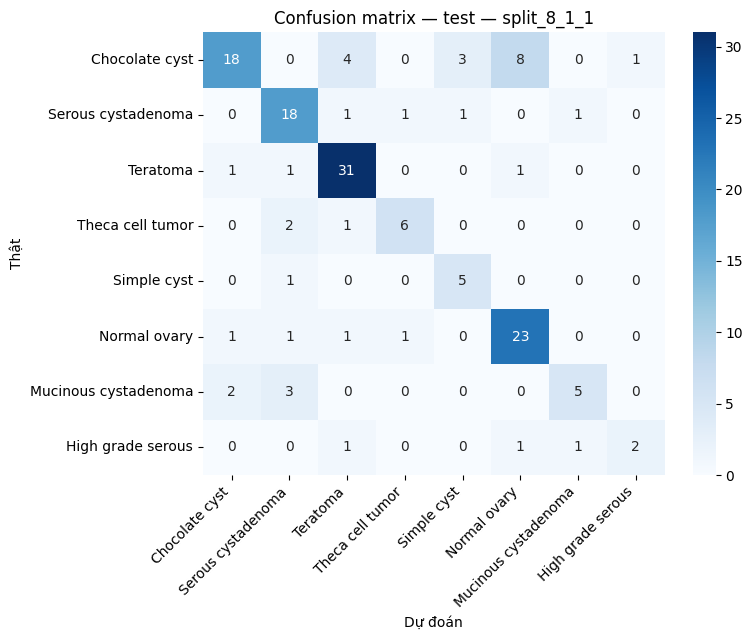

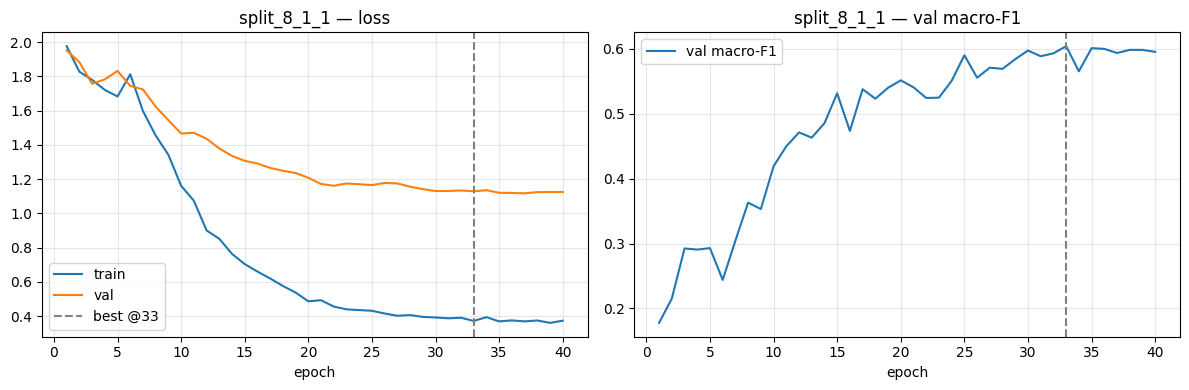


split_7_1.5_1.5 TEST  acc= 0.6878  macro-F1= 0.6234  weighted-F1= 0.6866
best val epoch: 34  checkpoint: /content/drive/MyDrive/TL_OvarianTumor_Ultrasound/runs/resnet50_split_7_1.5_1.5_best.pt
                      precision    recall  f1-score   support

      Chocolate cyst      0.745     0.686     0.714        51
  Serous cystadenoma      0.606     0.606     0.606        33
            Teratoma      0.732     0.820     0.774        50
    Theca cell tumor      0.600     0.462     0.522        13
         Simple cyst      0.417     0.500     0.455        10
        Normal ovary      0.800     0.800     0.800        40
Mucinous cystadenoma      0.529     0.562     0.545        16
   High grade serous      0.667     0.500     0.571         8

            accuracy                          0.688       221
           macro avg      0.637     0.617     0.623       221
        weighted avg      0.689     0.688     0.687       221



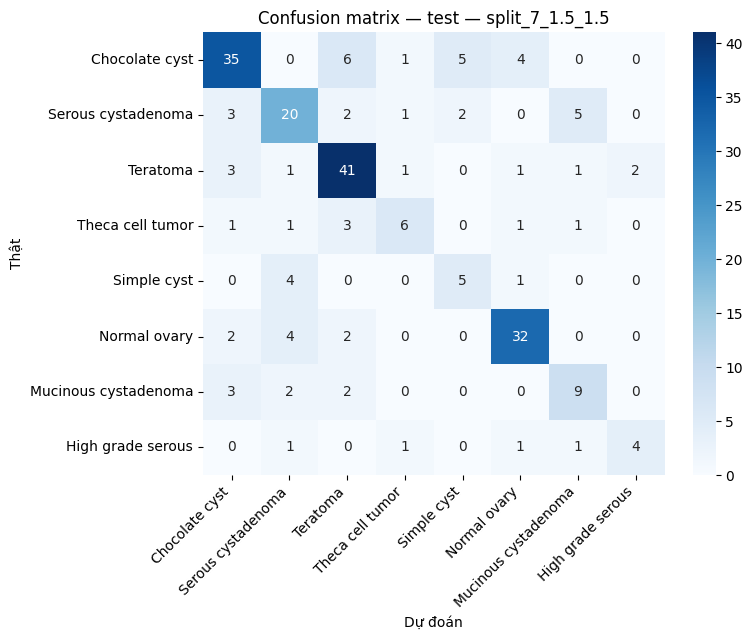

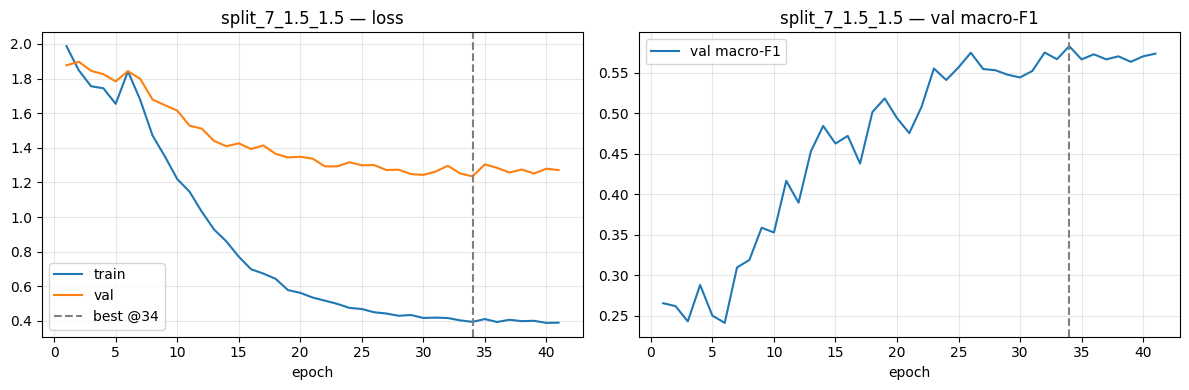


split_6_2_2 TEST  acc= 0.6803  macro-F1= 0.6228  weighted-F1= 0.6815
best val epoch: 29  checkpoint: /content/drive/MyDrive/TL_OvarianTumor_Ultrasound/runs/resnet50_split_6_2_2_best.pt
                      precision    recall  f1-score   support

      Chocolate cyst      0.833     0.672     0.744        67
  Serous cystadenoma      0.632     0.545     0.585        44
            Teratoma      0.797     0.761     0.779        67
    Theca cell tumor      0.381     0.444     0.410        18
         Simple cyst      0.474     0.692     0.562        13
        Normal ovary      0.634     0.849     0.726        53
Mucinous cystadenoma      0.684     0.619     0.650        21
   High grade serous      0.625     0.455     0.526        11

            accuracy                          0.680       294
           macro avg      0.632     0.630     0.623       294
        weighted avg      0.697     0.680     0.682       294



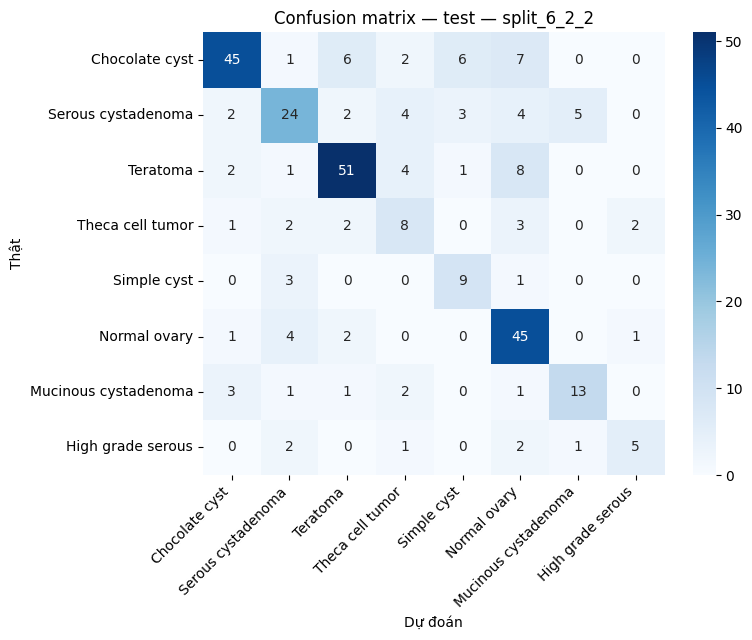

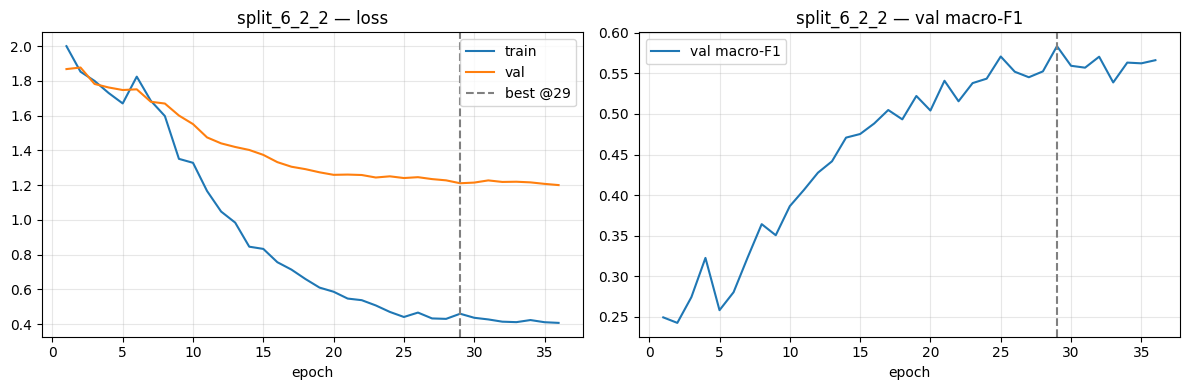


Bảng tổng hợp:
          split  n_train  n_val  n_test  accuracy  precision_macro  recall_macro  macro_f1  weighted_f1  best_epoch  n_epochs_trained
    split_8_1_1     1175    147     147  0.734694         0.711105      0.688901  0.683703     0.725640          33                40
split_7_1.5_1.5     1027    221     221  0.687783         0.636954      0.617047  0.623387     0.686582          34                41
    split_6_2_2      881    294     294  0.680272         0.632430      0.629712  0.622834     0.681507          29                36
Đã lưu /content/drive/MyDrive/TL_OvarianTumor_Ultrasound/runs/results_splits.csv


In [42]:
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

target_names = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]
result_rows = []


def plot_history(hist: pd.DataFrame, split_col: str, best_epoch: int):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist["epoch"], hist["train_loss"], label="train")
    axes[0].plot(hist["epoch"], hist["val_loss"], label="val")
    axes[0].axvline(best_epoch, color="gray", ls="--", label=f"best @{best_epoch}")
    axes[0].set_title(f"{split_col} — loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[1].plot(hist["epoch"], hist["val_macro_f1"], label="val macro-F1")
    axes[1].axvline(best_epoch, color="gray", ls="--")
    axes[1].set_title(f"{split_col} — val macro-F1")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(RUNS_DIR / f"curves_{split_col}.png", dpi=120)
    plt.show()


def plot_cm(y_true, y_pred, split_col: str):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(8, 6.5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=target_names, yticklabels=target_names,
    )
    ax.set_xlabel("Dự đoán")
    ax.set_ylabel("Thật")
    ax.set_title(f"Confusion matrix — test — {split_col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    fig.savefig(RUNS_DIR / f"cm_{split_col}.png", dpi=120)
    plt.show()


for split_col in SPLIT_COLS:
    run = split_runs[split_col]
    model = build_resnet50().to(device)
    meta = load_checkpoint(model, run["ckpt"])
    test_loader = run["loaders"]["test"]
    dummy_crit = nn.CrossEntropyLoss()
    ev = run_one_epoch(model, test_loader, dummy_crit, optimizer=None, scaler=torch.amp.GradScaler("cuda", enabled=False), train=False)
    y_true, y_pred = ev["y_true"], ev["y_pred"]
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)

    print("\n" + "=" * 72)
    print(split_col, "TEST  acc=", f"{acc:.4f}", " macro-F1=", f"{macro_f1:.4f}", " weighted-F1=", f"{weighted_f1:.4f}")
    print("best val epoch:", run["best_epoch"], " checkpoint:", run["ckpt"])
    print(classification_report(y_true, y_pred, target_names=target_names, digits=3, zero_division=0))
    plot_cm(y_true, y_pred, split_col)
    plot_history(run["history"], split_col, run["best_epoch"])

    result_rows.append({
        "split": split_col,
        "n_train": int((index_df[split_col] == "train").sum()),
        "n_val": int((index_df[split_col] == "val").sum()),
        "n_test": int((index_df[split_col] == "test").sum()),
        "accuracy": acc,
        "precision_macro": p,
        "recall_macro": r,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "best_epoch": run["best_epoch"],
        "n_epochs_trained": run["n_epochs"],
        "checkpoint": str(run["ckpt"]),
    })

results_df = pd.DataFrame(result_rows)
results_path = RUNS_DIR / "results_splits.csv"
results_df.to_csv(results_path, index=False)
print("\nBảng tổng hợp:")
print(results_df.drop(columns=["checkpoint"]).to_string(index=False))
print("Đã lưu", results_path)


## 5.5 Nhận xét kết quả


# 6. Kết luận

Điền sau khi đã có `runs/results_splits.csv`.

## Kết quả chính

- Backbone: ResNet50 ImageNet V2, fine-tune hai giai đoạn, ảnh 384×384.
- Tỷ lệ split tốt nhất (macro-F1 test): _điền từ mục 5.5_.
- Lớp còn nhầm nhiều: _điền từ classification_report / confusion matrix_.

## Hạn chế

- Tập nhỏ (~1000 ảnh train), 8 lớp lệch; lớp 7 rất ít mẫu.
- Chỉ siêu âm 2D, không dùng OTU_3d / thông tin lâm sàng.
- Chưa tìm siêu tham số tự động.

## Hướng phát triển

- Đã thử đóng băng `layer3` (underfit); lần này fine-tune `layer3`+`layer4` với lr phân tầng.
- Focal loss hoặc oversample lớp 7.
